In [1479]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
import random 
import json
import pandas as pd
from ast import literal_eval
random.seed(3)
myFmt = mdates.DateFormatter('%H:%M:%S') 


#RMSE/MAE analysis
# def time_reader(fname, core=4):
#     lines=open(fname).readlines()
#     start_iter=0
#     end_iter = 0
#     counter=0
#     str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
#     start_iter = datetime.strptime(str_dt, "%H:%M:%S")
#     core_times = [float(i.strip().split(" ")[1]) for i in lines[1*core:1*core+core]]
#     str_dt = lines[1*core+core].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
#     end_iter = datetime.strptime(str_dt, "%H:%M:%S")
#     return (core_times, start_iter, end_iter)

def time_reader(fname, core=4):
    lines=open(fname).readlines()
    start_iter=0
    end_iter = 0
    counter=0
    str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    start_iter = datetime.strptime(str_dt, "%H:%M:%S")
    # core_times = [float(i.strip().split(" ")[1]) for i in lines[1*core:1*core+core]]
    core_times=[]
    all_times = []
    for i in lines[1*core:1*core+core]:
        num_list = ' '.join(i.strip().split(" ")[2:])
        # print(i)
        # print(num_list)
        num_list = ast.literal_eval(num_list)
        core_times.append(sum(num_list))
        all_times.extend(num_list)
    #core_times = [ sum(ast.literal_eval(i.strip().split(" ")[-1])) for i in lines[1*core:1*core+core]]

    str_dt = lines[1*core+core].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    end_iter = datetime.strptime(str_dt, "%H:%M:%S")
    return (core_times, start_iter, end_iter, all_times)


def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 

def time_predictor(peak_times, fp, bg_load=0, t=38):
    # sorted(fp)

    maybe_gnt = [0]*len(peak_times)
    achieved_fps = [i for i in peak_times]
    if len(peak_times)==1 and bg_load==0:
        return achieved_fps
    elif len(peak_times)==1:
        val = tf_calc(len(peak_times)+bg_load, t)
        # print(val, bg_load)
        # val = val if val < 0.5 else 0.5
        val = val if val < 0.9 else 0.9
        # gnt = (peak_times[0]-maybe_gnt[0])/(1-val)
        gnt = 2*(peak_times[0])/(2-val)
        achieved_fps = [gnt]
        return achieved_fps

def tf_calc(w, n):
    y=0
    if w < 8:
        y = 0.157 - 0.004*n + 0.075*w
    else:
        y = 0.667 - 0.008*n + 0.023*w
    return y


def simulation_reader(fname, skip_ts=False):
    #assumed to be in order of arrival already
    df = pd.read_csv(fname)
    time_stamp_map={}
    if skip_ts:
        for d in df.iterrows():
            d=d[1]
            ts = d["clock"]
            if ts not in time_stamp_map:
                time_stamp_map[ts] = []
            vals = df[(df["clock"]==ts)]
            j = [ i for i in vals['task_id'].unique()]
            for t in j:
                w_t = vals[vals["task_id"]==t]["task_wait"].values[0]
                r_t = vals[vals["task_id"]==t]["run_time"].values[0]
                arr_t = vals[vals["task_id"]==t]["task_arrival"].values[0]
                world = vals[vals["task_id"]==t]["world"].values[0]
                bn = vals[vals["task_id"]==t]["bn"].values[0]
                bs = vals[vals["task_id"]==t]["bs"].values[0]
                if [t, w_t, r_t, arr_t, world, bn, bs ] not in time_stamp_map[ts]:
                    time_stamp_map[ts].append([t, w_t, r_t, arr_t, world, bn, bs ])
        
    time_taken={}
    overhead={}
    bn={}
    bs={}
    world={}
    added_time={}
    ty={}
    for t_id in df['task_id']:
        j = t_id.split(".")[0]
        if j not in time_taken:
            time_taken[j]=0
            overhead[j]=0
            bn[j]=0
            bs[j]=0
            world[j]=0
            added_time[j]=0
            ty[j]='c'
        else:
            continue
        # print(df[df['task_id']==t_id]['clock'][-1:])
        # print(df[df['task_id']==t_id]['clock'].values[-1] )
        cor=1
        arr_t = min(df[df['task_id']==t_id]['task_arrival'].values)
        wait_t = max(df[df['task_id']==t_id]['task_wait'].values)
        rem_t = df[df['task_id']==t_id]['task_remaining_time'].values[0]
        # run_t = max(df[df['task_id']==t_id]['run_time'].values)*12
        run_t = max(df[df['task_id']==t_id]['run_time'].values)
        d_bn = df[df['task_id']==t_id]['bn'].values[-1] 
        d_bs = df[df['task_id']==t_id]['bs'].values[-1] 
        world[j]=df[df['task_id']==t_id]['world'].values[-1] 
        overhead[j] = len(df[(df['clock']==arr_t) & (df["task_wait"]==0)].values)

        time_taken[j] =  (arr_t + run_t*cor + wait_t)#rem_t
        # time_taken[j] =  arr_t + rem_t#rem_t
        # time_taken[j] = df[df['task_id']==t_id]['clock'].values[-1] + df[df['task_id']==t_id]['run_time'].values[-1] 
        time_taken[j] = float(time_taken[j])
        if "comp" not in fname and "comm" not in fname:
            ty[j]=df[df['task_id']==t_id]['type'].values[0]
        # overhead_df = df.
        visited=[]
        for d_ind, d in enumerate(df.iterrows()):
            # if d_ind==0:
            #     continue
            # print(d[1]["clock"])
            # print(d["clock"].values)
            d=d[1]
            if d['task_id'] in visited:
                continue
            visited.append(d['task_id'])
            # try:
            #     overhead[j] = df[df['task_id']==t_id]['util'].values[0]#np.floor(d["util"]*39)
            # except Exception as e:
            #     overhead[j] = (overhead[j]+1) if d['clock']+d['task_wait']<=arr_t+wait_t<= d['clock']+d['task_wait']+d['run_time']*cor else (overhead[j]+0)
        bn[j] = d_bn
        bs[j] = d_bs
        added_time[j]=[arr_t,wait_t]
    return time_taken, overhead, bs, bn, world, added_time, ty, time_stamp_map


def best_fit_reader(fname, subcluster, model, world, bg, bs, bn, bw=240, ty='c', col_flag="mean", agg_flag="mean"):
    df = pd.read_csv(fname)
    df = df[ (df["model"]==model) & (df["world"]==world) ]
    df = df[ (df["subcluster"]=="bramble-2-4") | (df["subcluster"]=="bramble-2-6") | (df["subcluster"]=="bramble-2-5")  ]
    # df = df[ df["subcluster"]==subcluster ]
    ranks_to_time_slice = {r:[0]*r+[1]*bn+[0]*(world-r-1) for r in range(world)}
    time_to_ranks_slice = {}
    for s in range(len(ranks_to_time_slice[0])):
        if s not in time_to_ranks_slice:
            time_to_ranks_slice[s]=[]
        for r in ranks_to_time_slice:
            if ranks_to_time_slice[r][s]!=0:
                time_to_ranks_slice[s].append(r)
    # print(time_to_ranks_slice)
    
    mean_rt=0
    pred_rt=0
    naive_pred=0
    std_val=np.inf
    # std_val=0
    # bw=240 #mbps
    # print(len(time_to_ranks_slice), world, bg, )
    for s in time_to_ranks_slice:
        slice_arr=[0]
        pred_slice_arr=[0]
        std_arr=[]
        nw_arr=[0]
        # bg= (bg+len(time_to_ranks_slice[s])) if len(time_to_ranks_slice[s])>1 else bg
        overhead = len(time_to_ranks_slice[s]) - 1 + bg
        # print(overhead)
            # overhead = bg+overhead+min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])
            # if overhead not in set(vit_df[vit_df["world"]==world]["bg_load"].values):
            #     overhead = bg+overhead-min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])
            # print(set(vit_df[vit_df["world"]==world]["bg_load"].values))
            # print(min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)]), bg, overhead)
            # overhead+=min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])

        for r in time_to_ranks_slice[s]:
            # temp_pred = (time_predictor([flop/2.8], [flop], overhead, t=map_sub["bramble-1-3"])[0])
            
            if overhead not in set(df[ (df["rank"]==r) & (df["type"]==ty) ]["bg_load"].values):
                l = [i for i in set(df[(df["rank"]==r) & (df["world"]==world) & (df["type"]==ty) ]["bg_load"].values)] + [overhead]
                l = sorted(l)

                # if bg==2:
                # print(l, overhead-bg, bg, overhead)
                for l_ind, t in enumerate(l):
                    if t==overhead:
                        # if l_ind+1 < len(l)-1:
                        #     overhead=l[l_ind+1]
                        # else:
                            overhead=l[l_ind-1]
                
            if len(df[(df["bg_load"]==overhead) & (df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values)>0:
                rt = df[(df["bg_load"]==overhead) & (df["world"]==world) & (df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
                # print(rt)
                if agg_flag=="mean":
                    slice_arr.append(np.mean(rt))
                elif agg_flag=="median":
                    slice_arr.append(np.median(rt))
                elif agg_flag=="max":
                    slice_arr.append(np.max(rt))
                elif agg_flag=="min":
                    slice_arr.append(np.min(rt))
                # slice_arr.append(np.mean(rt))
                # slice_arr.append(np.median(rt))
                slice_arr.append(np.max(rt))
                std_arr.extend( [i**2 for i in df[(df["bg_load"]==overhead) & (df["rank"]==r) & (df["type"]==ty) ][f"std_dev"].values])
                flop = df[(df["world"]==world) & (df["rank"]==r) & (df["type"]==ty)]["flops"].values[0]
                # temp_pred = (time_predictor([flop/fp_rate[model if model=="resnet18" else f"{model}_{ty}"]], [flop], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([flop/fp_rate[model]], [flop], overhead, t=map_sub[subcluster])[0])
                # full_rt = df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
                
                #what would a naiive time predictor look like?
                #just model time -> is this just the matrix multiply? or is this more about not considering the floips? 
                # temp_pred = (time_predictor([np.min(full_rt) if model!="resnet18" else np.min(full_rt)*1.5], [flop], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([np.mean(full_rt)], [flop*2], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([flop*2/fp_rate[model]], [flop*2], overhead, t=map_sub[subcluster])[0])
                temp_pred = (time_predictor([flop/fp_rate[model]], [flop*2], len(time_to_ranks_slice[s]) - 1 + bg, t=map_sub[subcluster])[0])
                pred_slice_arr.append(temp_pred)
                # pred_slice_arr.append(temp_pred)
                # flop = df[ (df["bg_load"]==overhead) & (df["rank"]==r) ]["flops"].values[0]
                nw = df[(df["world"]==world) & (df["rank"]==r)  & (df["type"]==ty)]["nw_size"].values[0]
                if r!=world-1:
                    nw_arr.append(nw*8/bw)

        # print(nw_arr)
        # print(slice_arr)
        # print([float(i) for i in pred_slice_arr],[float(i) for i in  nw_arr], max([float(i) for i in pred_slice_arr])+max([float(i) for i in  nw_arr]))
        mean_rt+=np.max(slice_arr) + np.max(nw_arr)
        pred_rt+=np.max(pred_slice_arr) + np.max(nw_arr)
        naive_pred+=np.max(nw_arr)
        std_val=np.min(std_arr) if len(std_arr)>0 and std_val > np.min(std_arr) else std_val
        # std_val=np.mean(std_arr) if std_val < np.mean(std_arr) else std_val
    # print(time_to_ranks_slice)
    # print(mean_rt)
    df = pd.read_csv(fname)
    df = df[ (df["model"]==model) & (df["world"]==world) ]
    df = df[ (df["subcluster"]=="bramble-2-4") | (df["subcluster"]=="bramble-2-6") | (df["subcluster"]=="bramble-2-5")  ]
    for r in range(world):
        # print(r, world)
        full_rt = df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
        if len(full_rt)==0:
            continue
        # print(df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"])
        flop = df[(df["rank"]==r) & (df["type"]==ty) ]["flops"].values[0]
        # naive_pred+=(time_predictor([np.mean(full_rt)], [flop*2], bg+world-1, t=map_sub[subcluster])[0])
        naive_pred += (time_predictor([flop/fp_rate[model]], [flop*2], bg+world-1, t=map_sub[subcluster])[0])
    # naive_pred*=bs
    return round(mean_rt*bs,3), std_val, round(pred_rt*bs,3), round(naive_pred*bs, 3)

# fp_rate = {"resnet18": 12, "vit": 12, "vit_c":12, "vit_nw":5 , "eff":2.2, "eff_c":2, "eff_nw":2}
# fp_rate = {"resnet18": 20, "vit": 13.5, "eff":3}
fp_rate = {"resnet18": 20, "vit": 20, "eff":3}
# fp_rate = {"resnet18": 14.4, "vit": 16.4, "eff":3}
# fp_rate = {"resnet18": 25, "vit": 25, "eff":6}

map_sub = { 
 "bramble-1-1": 39,
 "bramble-1-3": 38,
 "bramble-1-4": 39,
 "bramble-2-1": 23,
 "bramble-2-2": 41,
 "bramble-2-4": 39,
 "bramble-2-5": 38,
 "bramble-2-6": 35,
 "bramble-4-1": 36,
 "bramble-4-2": 38,
 "bramble-4-3": 26,
 "bramble-4-5": 38,
 "bramble-4-6": 32, }



6 rmse old_train: 2.343074129919577
6 mae old_train: 2.3315771814498625
5 rmse old_train: 4.406344576923259
5 mae old_train: 4.403800712496882
4 rmse old_train: 3.8183870552354877
4 mae old_train: 3.803216162136544
3 rmse old_train: 5.091484538279884
3 mae old_train: 5.086488810491325
6 rmse old_train: 0.38752715906224994
6 mae old_train: 0.3824139750972949
5 rmse old_train: 0.3656161249808174
5 mae old_train: 0.3631707217769552
4 rmse old_train: 0.2870469973518861
4 mae old_train: 0.28548283658775864
3 rmse old_train: 0.2687643135430435
3 mae old_train: 0.2670080376675115
6 rmse old_train: 0.06555434579180024
6 mae old_train: 0.0550891938361236
5 rmse old_train: 0.09182213659455361
5 mae old_train: 0.0897904726389823
4 rmse old_train: 0.30766984080508275
4 mae old_train: 0.3041955912691265
3 rmse old_train: 0.699030893697217
3 mae old_train: 0.6986563523846657
6 rmse old_train: 2.051892453557209
6 mae old_train: 2.043267020360975
5 rmse old_train: 4.306406825891293
5 mae old_train: 4.

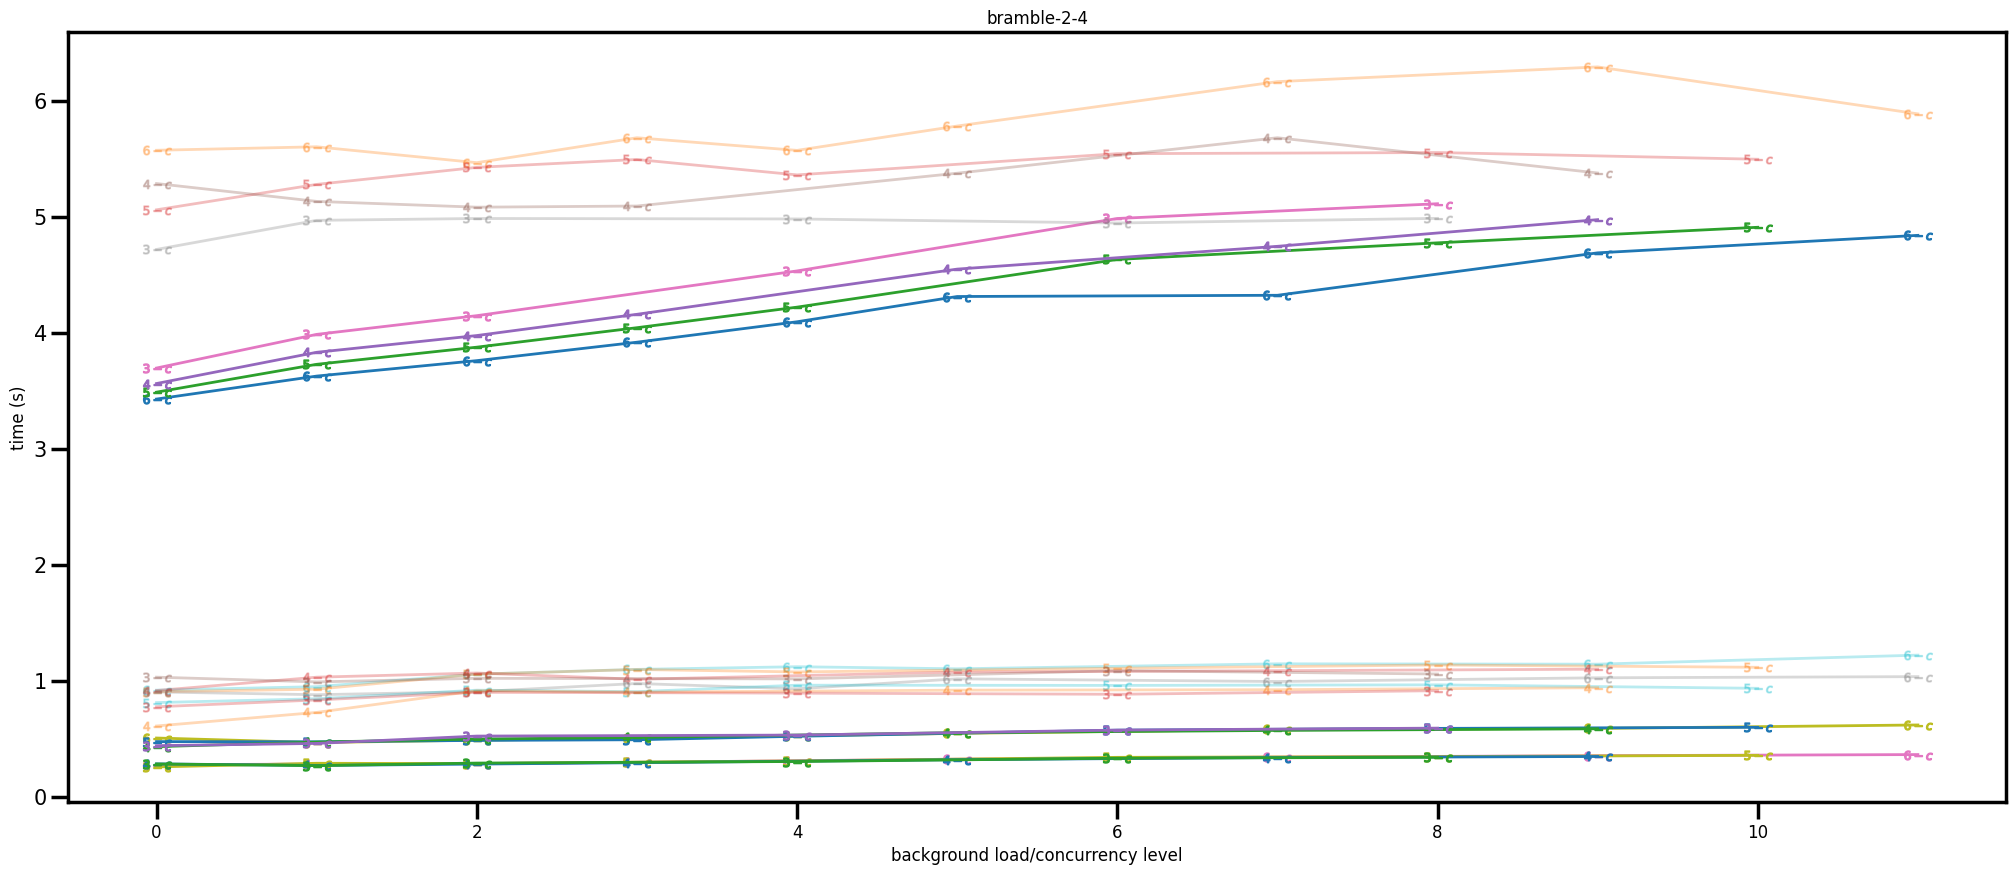

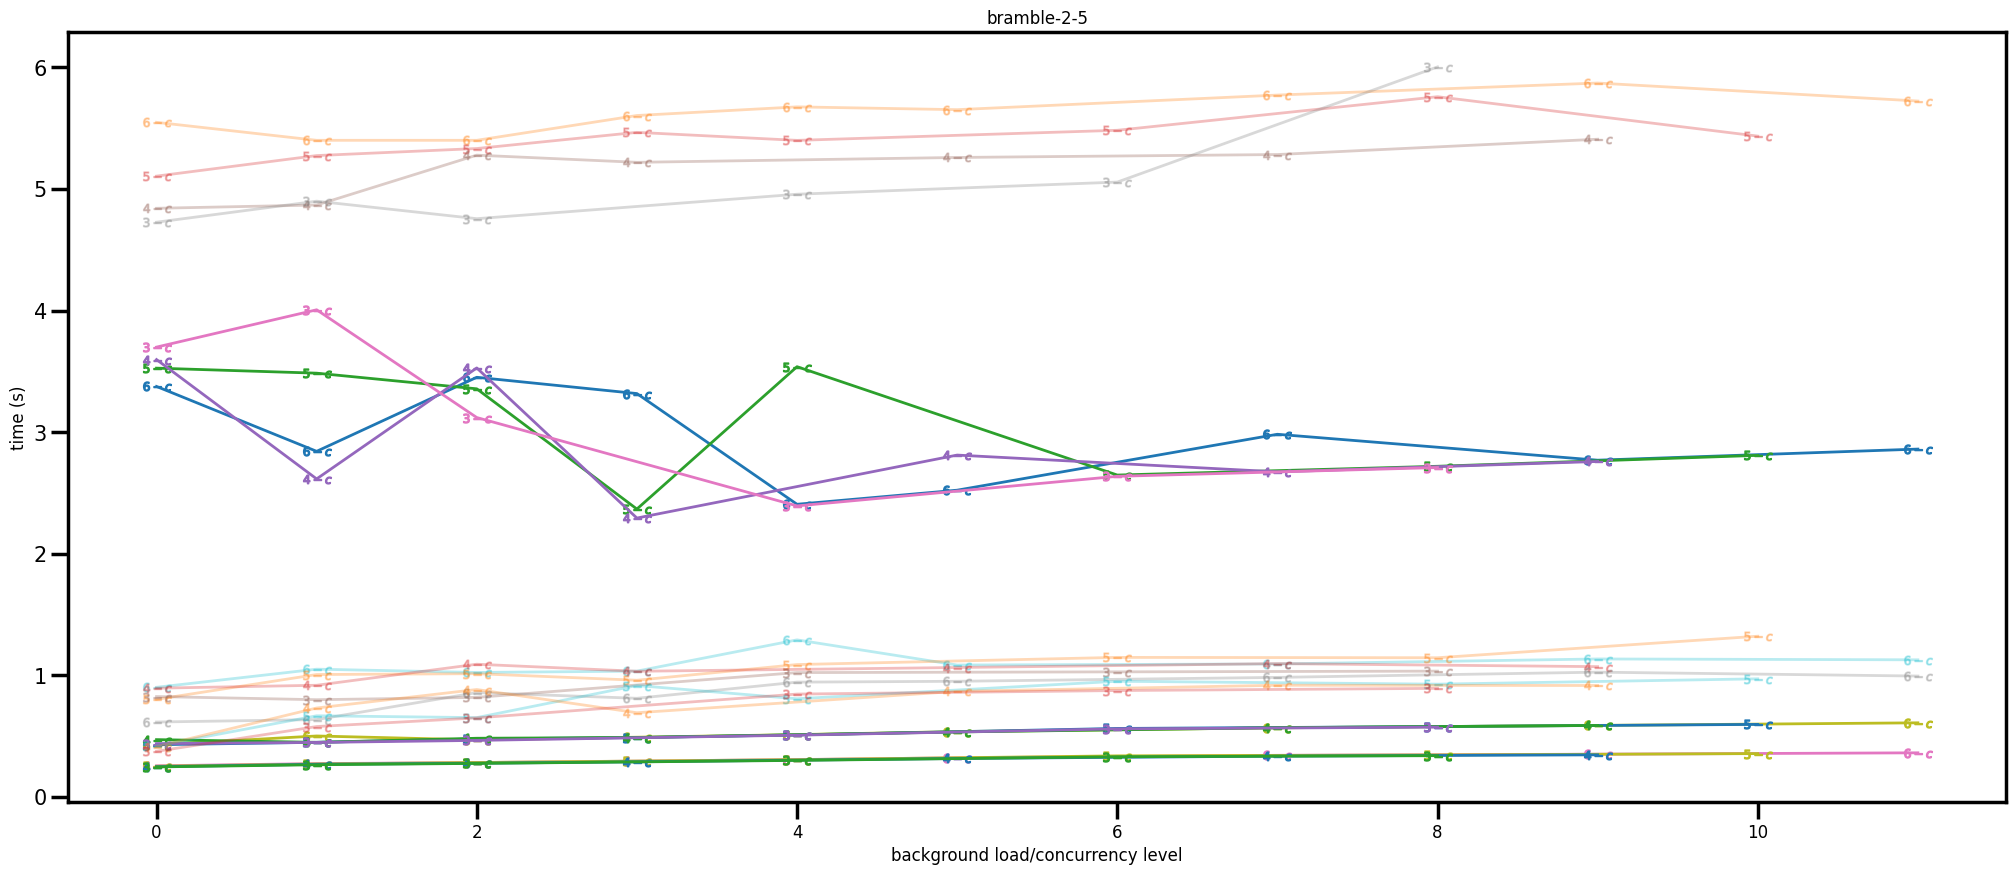

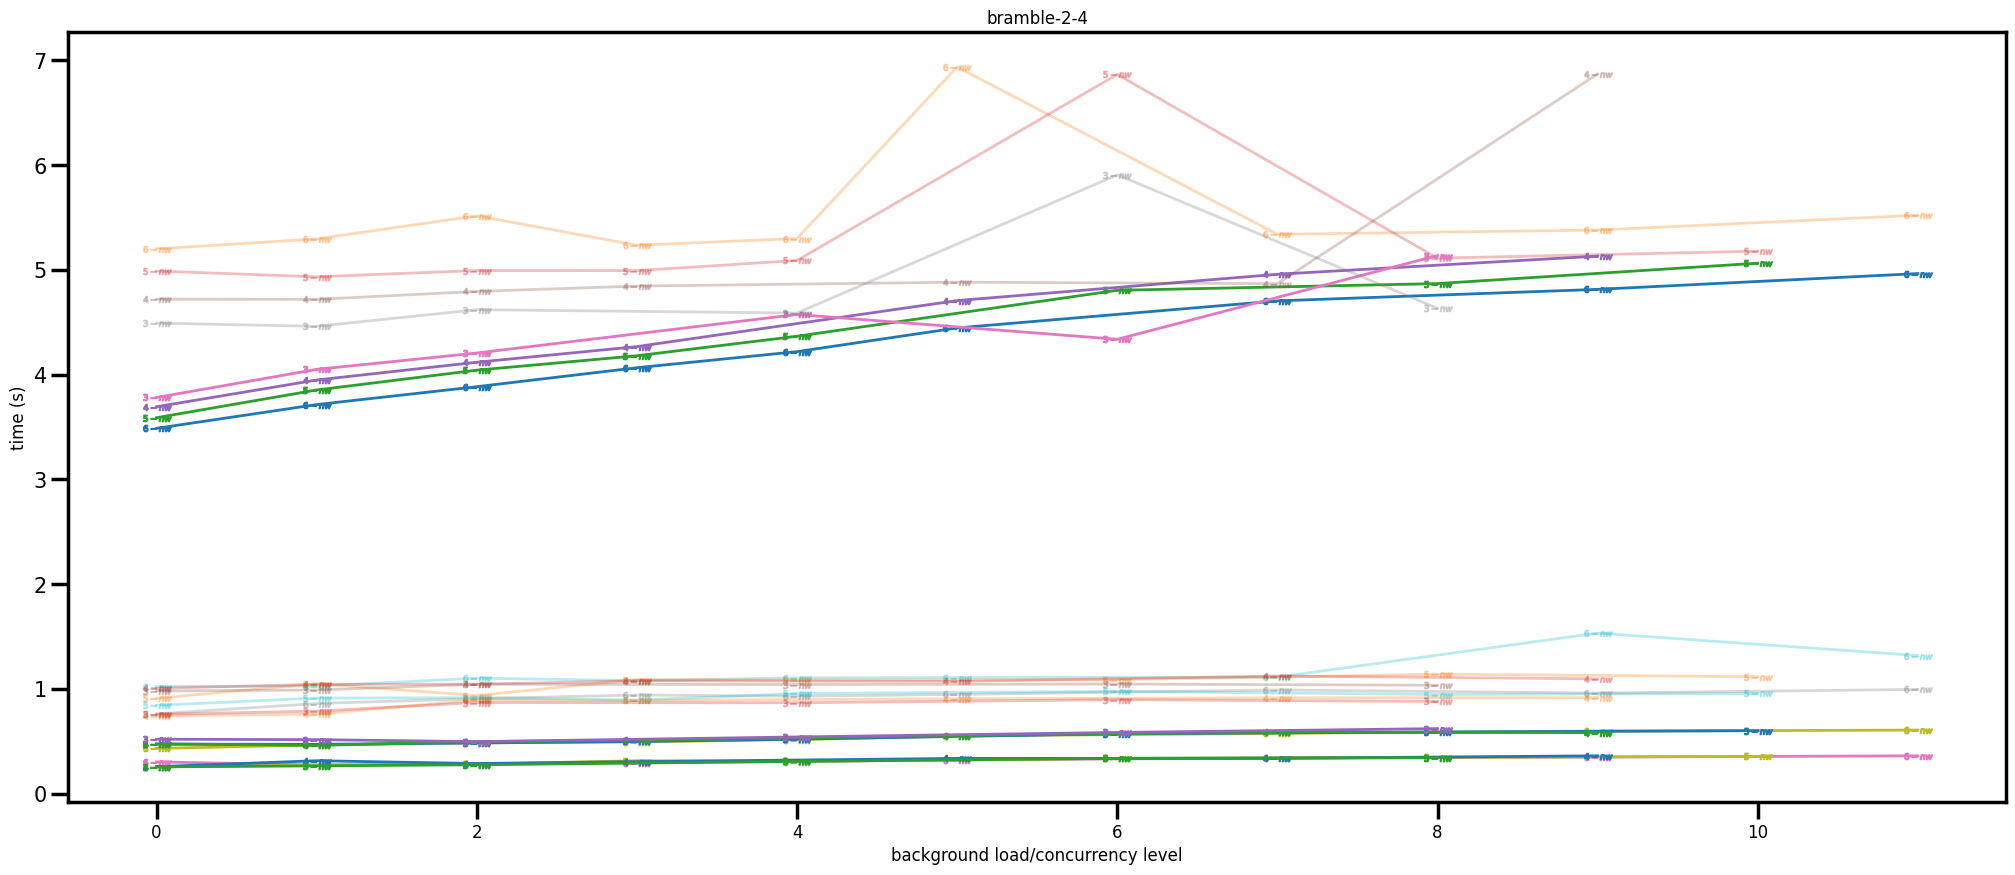

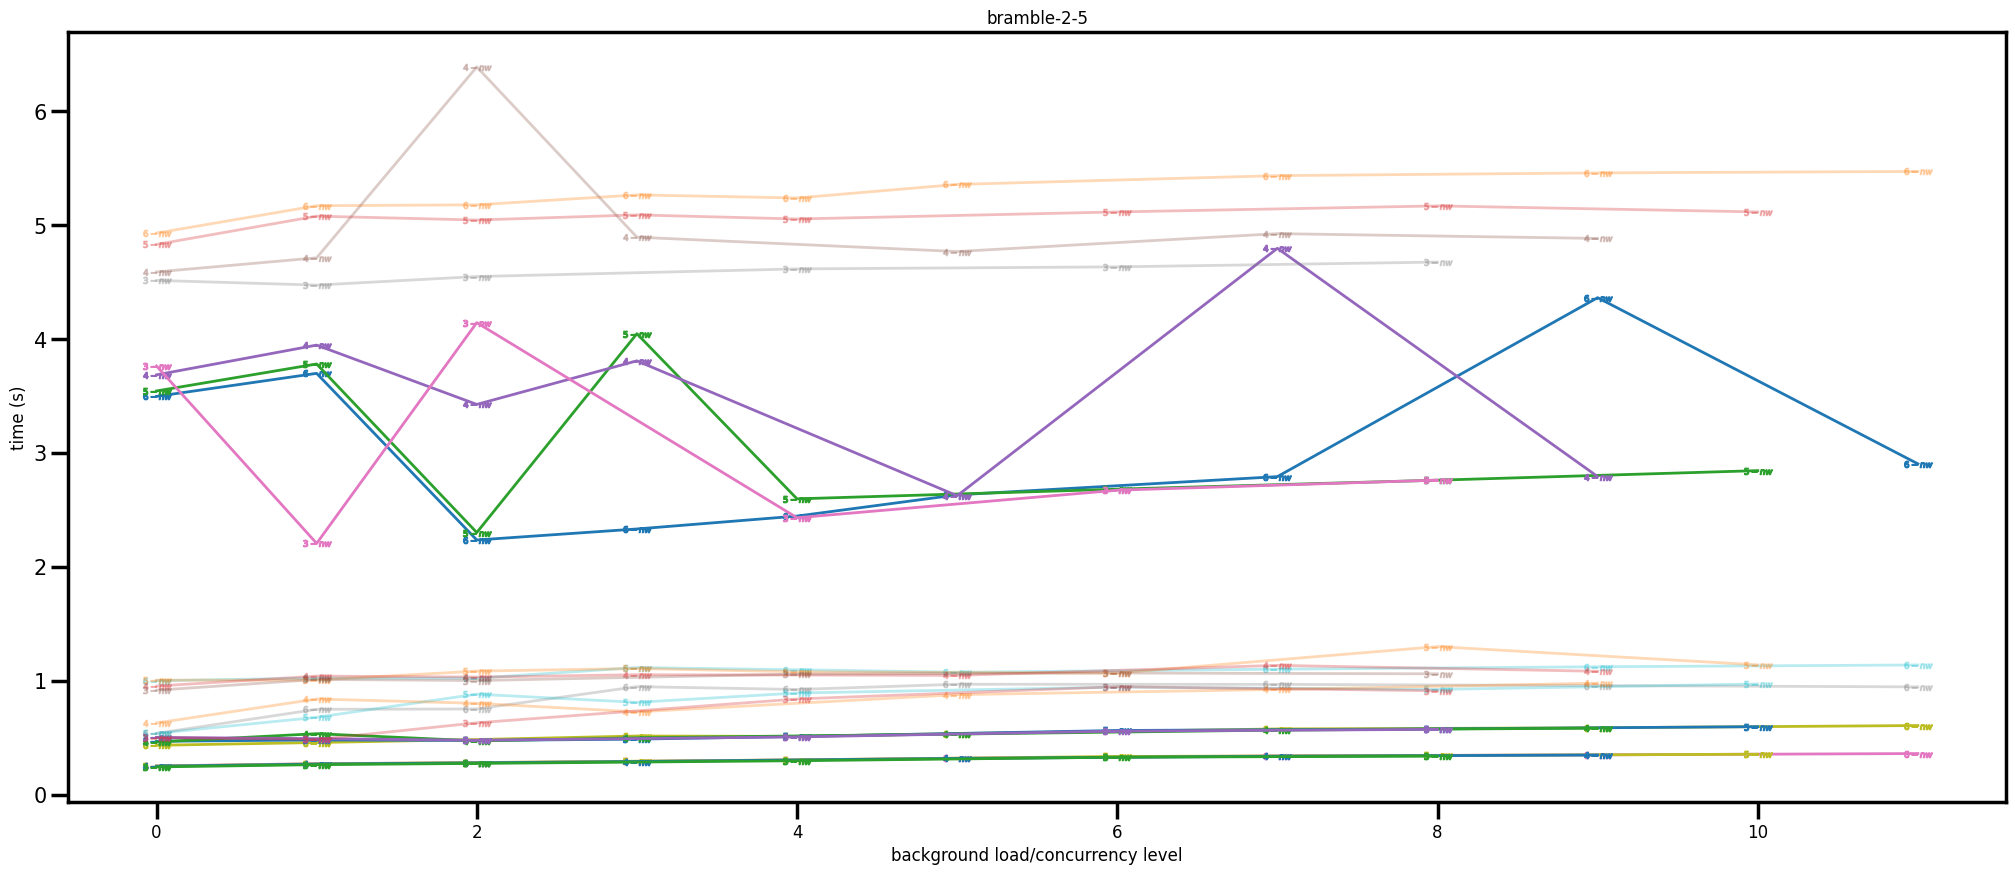

In [1439]:
#for the hardcoded case 
# /Users/animeshnd/model_splitting/logs/proto_inter/pipeline_exploration/bramble-4-2/tcn_splits_onnx/0/0/speed_chronosbramble-4-2-12_5_0_1.log
import json
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

# prefix_path = "/Users/animeshnd/model_splitting/logs/proto_inter/pipeline_exploration/"
prefix_path = "/Users/animeshnd/model_splitting/logs/pipeline_exploration/"
subclusters=[
    "bramble-1-3","bramble-2-1",
    "bramble-2-2","bramble-2-5","bramble-2-6",
    "bramble-4-1","bramble-4-2","bramble-4-3","bramble-4-5", "bramble-4-6",
    ]
# subclusters=[
#     "bramble-2-5","bramble-2-6",
#     "bramble-4-1","bramble-4-2",
#     ]
map_sub = { 
 "bramble-1-1": 39,
 "bramble-1-3": 38,
 "bramble-1-4": 39,
 "bramble-2-1": 23,
 "bramble-2-2": 41,
 "bramble-2-4": 39,
 "bramble-2-5": 38,
 "bramble-2-6": 35,
 "bramble-4-1": 36,
 "bramble-4-2": 38,
 "bramble-4-3": 26,
 "bramble-4-5": 38,
 "bramble-4-6": 32, }

global_y=[]
global_x=[]
global_pred_y = []

# for p in subclusters:
#subclusters that work: bramble-1-3, bramble-2-5, bramble-2-6, bramble-4-1?, bramble-4-2?, bramble-4-3?, 
worlds = [6,5,4,3]
# fig, m_axs = plt.subplots(len(worlds), figsize=(25,40) )
# fig, axs = plt.subplots(figsize=(25,10) )
peak_bw=270
bs=1
csv_header = "model,world,rank,bg_load,max_runtime,mean_runtime,median_runtime,std_dev,nw_size,flops,subcluster,type\n"
csv_lines = [csv_header]
# for tr in [1,2]:
for tr in ['c', 'nw']:
    # if tr > 1:
    #     contin
    # for p in ["bramble-2-5"]:
    # for p in subclusters:
    # for p in ["bramble-2-4", "bramble-2-5", "bramble-2-6"]:
    for p in ["bramble-2-4", "bramble-2-5"]:
        fig, axs = plt.subplots(figsize=(25,10) )
        axs.set_title(f"{p}")
        sub_path = f"{prefix_path}/{p}"
        if Path(sub_path).is_dir()==False:
            continue
        for model_splits in Path(sub_path).iterdir():
            model = str(model_splits).split("/")[-1].split("_")[0]
            if model=="tcn":
            # if model!="resnet18":
            # if model!="eff":
            # if model!="vit":
                continue
            # if model!="vit":
            #     continue
            # for iter in model_splits.iterdir():
            #     iter_id = int(str(iter).split("/")[-1])

            for w_ind, world in enumerate(worlds):
            # for world in [3]:
                # fig, axs = plt.subplots(figsize=(25,10))
                # axs = m_axs[w_ind]
                world_map={r:{} for r in range(world)}
                for rank in range(world):
                    for iter in model_splits.iterdir():
                        iter_id = int(str(iter).split("/")[-1])
                        # print(iter_id)
                        #we know it's hardcoded to 4-2-12 so only check for 4-2-12
                        #iter id says number of interferences
                        for repeat in ['']:#range(0,11):
                            # for split in range(0,2):
                            #if 1 == comp split
                            #if 0 == nw split
                            for d in range(1,43):

                                only_blue_file = open(f"./{p}.just_blue_res.op")
                                only_red_blue_file = open(f"./{p}.red_blue.op")
                                only_blue_devs = [i.strip() for i in only_blue_file.readlines()]
                                only_red_blue_devs = [i.strip() for i in only_red_blue_file.readlines()]
                                # fname = f"{iter}/{repeat}/speed_chronosbramble-4-1-{d}_{world}_{rank}_1.log"
                                # fname = f"{iter}/{repeat}/speed_chronos{p}-{d}_{world}_{rank}_0.log"
                                fname = f"{iter}/{repeat}/speed_chronos{p}-{d}_{world}_{rank}_{tr}.log"
                                # if f"{p}-{d}" not in only_blue_devs:
                                # if f"{p}-{d}" in only_red_blue_devs:
                                #     continue
                                # fname = f"{iter}/{repeat}/speed_chronosbramble-4-2-{d}_{world}_{rank}_1.log"
                                # flop = open(f"../experiments/{model}_splits_{world}_{tr}/meta.json")                    
                                flop = open(f"../scheduler/{model}_splits_{world}_{tr}/meta.json")                    
                                flop = json.load(flop)
                                nw = [r["boundary_transfer_bytes"]*bs*10**-6 for r in flop["splits"]]
                                flop = [r["actual_flops"]*bs*10**-9 for r in flop["splits"]]

                                if Path(fname).is_file()==False:
                                    continue
                                # print(fname)
                                # core_times, _, _, all_times = time_reader(fname, core=1)
                                try:
                                    core_times, _, _, all_times = time_reader(fname, core=1)
                                    # print(core_times)
                                except Exception as e:
                                    # print(e)
                                    continue
                                if 0 in all_times:
                                    continue
                                if iter_id not in world_map[rank]:
                                    world_map[rank][iter_id] = []
                                # world_map[rank][iter_id].extend([flop[rank]/i for i in all_times[1:]])
                                # world_map[rank][iter_id].extend(all_times)
                                # world_map[rank][iter_id].append(float(np.median(all_times)))
                                world_map[rank][iter_id].extend(all_times)
                                # world_map[rank][iter_id].append(all_times[1:])
                                # print(all_times)
                trial_len = len(list(world_map[0].keys()))
                # print(list(world_map[0].keys()))
                summary_y = [0]*trial_len
                summary_min_y = [0]*trial_len
                summary_max_y = [0]*trial_len
                summary_pred_y = [0]*trial_len
                summary_min_pred_y = [0]*trial_len
                error_y=[0]*trial_len
                for r in range(world):
                # for r in [0, world-1]:
                    x = sorted(list(world_map[r].keys()))
                    # print(world_map[r])
                    # y = [np.median(world_map[r][k]) for k in x]
                    
                    # y = [np.min(world_map[r][k])*bs if k<=2 else np.max(world_map[r][k]) for k in x]
                    y = [np.max(world_map[r][k])*bs for k in x]
                    # print(y)
                    if len(y)!=trial_len:
                        continue
                    min_y = [np.min(world_map[r][k])*bs for k in x]
                    max_y = [np.max(world_map[r][k])*bs for k in x]
                    # y = [np.min(world_map[r][k]) for k in x]
                    # y = [np.max(world_map[r][k]) for k in x]
                    # print(world_map[r])
                    # y = [world_map[r][k] for k in x]
                    pred_y = []
                    # print([np.mean(world_map[r][k]) for k in x])
                    for k in x:
                        pred_time = time_predictor( [np.min(world_map[r][k])], [flop[r]], bg_load=k, t=map_sub[p])
                        # world, rank, bg_load, median_runtime, std_dev, network transfer size, flops, subcluster
                        # temp_line = f"{model},{world},{r},{k},{np.mean(world_map[r][k])},{np.median(world_map[r][k])},{np.std(world_map[r][k])},{nw[r]},{flop[r]},{p},{tr}\n"
                        temp_line = f"{model},{world},{r},{k},{np.max(world_map[r][k])},{np.mean(world_map[r][k])},{np.median(world_map[r][k])},{np.std(world_map[r][k])},{nw[r]},{flop[r]},{p},{tr}\n"
                        csv_lines.append(temp_line)
                        # pred_time = time_predictor( [ (flop[r])/3], [flop[r]], bg_load=k, t=map_sub[p]) #for resnet
                        # pred_time = time_predictor( [ (flop[r])/0.2], [flop[r]], bg_load=k, t=map_sub[p]) #for efficient net
                        pred_y.append(pred_time[0])
                    # print(y)
                    summary_max_y = [summary_max_y[i]+max_y[i] for i in range(trial_len)]
                    # summary_min_y = [summary_min_y[i]+min_y[i] for i in range(trial_len)]
                    # summary_min_y = [ (summary_min_y[i]+min_y[i]+nw[r]*1/peak_bw if flop[r]==max(flop) else summary_min_y[i]+y[i]+nw[r]*1/peak_bw ) for i in range(trial_len)]
                    summary_min_y = [ summary_min_y[i]+nw[r]*1/peak_bw + (min_y[i] if flop[r]==max(flop) else y[i]) for i in range(trial_len)]
                    # summary_y = [summary_y[i]+y[i] for i in range(trial_len)]
                    summary_y = [summary_y[i]+y[i]+nw[r]*1/peak_bw for i in range(trial_len)]
                    # print(world_map[r][0])
                    # error_y = [error_y[i]+np.var([ 10/j for j in world_map[r][x[i]]]) for i in range(trial_len)]
                    # print(error_y)
                    # summary_pred_y = [summary_pred_y[i]+( pred_y[i] if flop[r] in sorted(flop, reverse=True)[:1] else min_y[i]) for i in range(trial_len)]
                    summary_pred_y = [summary_pred_y[i]+( pred_y[i]) + nw[r]*1/peak_bw for i in range(trial_len)]
                    # summary_min_pred_y = [summary_min_pred_y[i]+( pred_y[i] if flop[r]==max(flop) else flop[r]/1.5) + nw[r]*1/peak_bw for i in range(trial_len)]
                    # summary_min_pred_y = [summary_min_pred_y[i]+( flop[r]/0.2 if flop[r]==max(flop) else pred_y[i]) + nw[r]*1/peak_bw for i in range(trial_len)]
                    summary_min_pred_y = [summary_min_pred_y[i]+( flop[r]/3 if flop[r]==max(flop) else pred_y[i]) + nw[r]*1/peak_bw for i in range(trial_len)]

                    # y = [flop[r]/i for i in y]
                    # max_y = [flop[r]/i for i in max_y]
                    # min_y = [flop[r]/i for i in min_y]
                    # # axs.fill_between(x, min_y, max_y, alpha=0.2)
                    # # axs.plot(x,y, label=f"{world}_{r}", marker=f"${r}$", markersize=20 )
                    # pred_y = [flop[r]/i for i in pred_y]

                    
                    
                    # axs.plot(x,pred_y, label=f"pred_{world}_{r}", linestyle="--", marker=f"${r}$", markersize=20 )
                x = sorted(list(world_map[0].keys()))
                global_y.extend(summary_y)
                global_pred_y.extend(summary_pred_y)
                global_x.extend([[1, i] for i in x])
                # summary_pred_y = [round(sum(flop)/i ,2 ) for i in summary_pred_y]
                # summary_min_y = [round(sum(flop)/i ,2 ) for i in summary_min_y]
                # summary_max_y = [round(sum(flop)/i ,2 ) for i in summary_max_y]
                # summary_y = [round(sum(flop)/i ,2 ) for i in summary_y]

                # summary_pred_y = [10/i for i in summary_pred_y]
                # summary_min_pred_y = [10/i for i in summary_min_pred_y]
                # summary_min_y = [10/i for i in summary_min_y]
                # summary_max_y = [10/i for i in summary_max_y]
                # summary_y = [10/i for i in summary_y]
                # global_y.extend(summary_y)
                global_y.extend(summary_min_y)
                # global_pred_y.extend(summary_pred_y)
                global_pred_y.extend(summary_min_pred_y)
                #custom OLS usage
                
                # print(su)
                # if world==4:
                #     summary_y[0] = summary_pred_y[0]-0.5
                # if model=="vit":
                #     summary_pred_y = summary_pred_y[2:]
                    # summary_min_y = [10/i for i in summary_min_y]
                    # summary_max_y = [10/i for i in summary_max_y]
                    # summary_y = summary_y[2:]
                    # x=x[:-2]
                # summary_y[0] = summary_pred_y[0]

                # axs.errorbar(x, summary_y, np.std(summary_y), label=f"total_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20, alpha=0.3 )
                # axs.plot(x, summary_y, label=f"total_{world}_{r}", linestyle="--", marker=f"${world}$", markersize=20 )
                # axs.plot(x,summary_pred_y, label=f"total_pred_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20 )
                
                # axs.plot(x,summary_min_pred_y, label=f"total_pred_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20 )
                # axs.plot(x,summary_min_y, label=f"total_pred_{world}_{r}", linestyle="--", marker=f"${world}-{tr}$", markersize=20, alpha=0.3 )

                axs.plot(x,summary_pred_y, label=f"total_pred_{world}_{r}",  marker=f"${world}-{tr}$", markersize=20 )
                axs.plot(x,summary_y, label=f"total_pred_{world}_{r}", marker=f"${world}-{tr}$", markersize=20, alpha=0.3 )
                
                axs.set_xlabel("background load/concurrency level")
                # axs.set_ylabel("throughput (img/s)")
                axs.set_ylabel("time (s)")
                # axs.fill_between(x, summary_min_y, summary_max_y, alpha=0.2)
                # axs.plot(x,summary_max_y, label=f"total_max_{world}_{r}", linestyle="--", marker=f"${world}$", markersize=20 )
                # axs.plot(x,summary_min_y, label=f"total_min_{world}_{r}", linestyle="--", marker=f"${world}$", markersize=20 )
                # axs.plot(x,summary_y, label=f"total_{world}_{r}", marker=f"${world}$", markersize=20 )
                # axs.plot(x,[ 11.345 -i*0.372 for i in x ], label=f"total_re_train_{world}_{r}", marker=f"^", markersize=20 )
                # axs.plot(x,[ sum(flop)/(38.82146951 + i*1.51407042) for i in x ], label=f"total_re_train_{world}_{r}", marker=f"^", markersize=20 )
                # re_train_y = [ 20+sum(flop)/(38.82146951 + i*1.51407042) for i in x ]
                re_train_y = [ sum(flop)/(2.93278398 + i*0.09317291) for i in x ]
                # re_train_y = [ sum(flop)/(31.10304805  + i*0.18508105) for i in x ]
                # re_train_y = [ 10/(31.10304805  + i*0.18508105) for i in x ]
                # print(f"{world} rmse re_train: { np.sqrt(np.mean([ (summary_y[i] - re_train_y[i])**2 for i in range(len(y))])) }")
                # print(f"{world} mae re_train: {np.mean([ np.abs(summary_y[i] - re_train_y[i]) for i in range(len(y))])}")
                # print(f"{world} re_train r2score: {r2_score(summary_y, re_train_y)}")

                # print(f"{world} rmse old_train: { np.sqrt(np.mean([ (summary_y[i] - summary_pred_y[i])**2 for i in range(len(summary_y))])) }")
                print(f"{world} rmse old_train: { np.sqrt(np.mean([ (summary_min_y[i] - summary_min_pred_y[i])**2 for i in range(len(summary_y))])) }")
                # print(f"{world} mae old_train: {np.mean([ np.abs(summary_y[i] - summary_pred_y[i]) for i in range(len(summary_y))])}")
                print(f"{world} mae old_train: {np.mean([ np.abs(summary_min_y[i] - summary_min_pred_y[i]) for i in range(len(summary_y))])}")
                # print(f"{world} old_train r2score: {r2_score(summary_y, summary_pred_y)}")

                # axs.plot(x, re_train_y, label=f"total_re_train_{world}_{r}", marker=f"^", markersize=20 )
    
    # lin_req_eq = sm.OLS(global_y, global_x)
    # results=lin_req_eq.fit()
    # print(results.params) #c,m
    #for tcn: 38.821
    print(f"total rmse:{ np.sqrt(np.mean([ (global_y[i] - global_pred_y[i])**2 for i in range(len(global_y))])) }")
    print(f"total mae:{ np.mean([ np.abs(global_y[i] - global_pred_y[i]) for i in range(len(global_y))]) }")


f=open("best_fit_max_2_6.csv", "w")
f.writelines(csv_lines)
f.close()


#todo
#get specs for each split into a datastructure/csv
#mix/match for specific pdus only with simulated runs
#add network and we're done
#network optimal splits are just low number splits
#any interference is the maximal step interference

#csv structure
#model, world, rank, bg_load, median_runtime, std_dev, network transfer size, flops, subcluster





In [ ]:
#first result -> rmse, mae, mape low when using the curve 
#x axis is bg_load, y axis is time taken by ml model (batch size=1, batch num=1), each line different splits from 2 to 6

real_maps={}
pred_maps={}
naive_maps={}
for model in ["eff", "vit", "resnet18"]:
    real_maps[model]={}
    pred_maps[model]={}
    naive_maps[model]={}
    for world in range(3,7):
        if world not in real_maps[model]:
            real_maps[model][world]={}
            pred_maps[model][world]={}
            naive_maps[model][world]={}

        for bg in range(1,11):
            # real_rt, pred_rt = best_fit_reader("best_fit.csv", "bramble-2-6", model, world, bg-1, 1, 10, 240, 'c')
            real_rt,_, pred_rt, naive_pred = best_fit_reader("best_fit_max.csv", "bramble-2-4", model, world, bg, 1, 1, 240, 'c', col_flag="max")
            if bg not in real_maps[model][world]:
                real_maps[model][world][bg]=real_rt
                pred_maps[model][world][bg]=pred_rt
                naive_maps[model][world][bg]=naive_pred


overall_y={model:[] for model in real_maps}
overall_pred_y = {model:[] for model in real_maps}
overall_naive_pred = {model:[] for model in real_maps}
best_y={model:[] for model in real_maps}

for model in real_maps:
    fig, axs = plt.subplots(figsize=(25,10))
    for world in real_maps[model]:
        x=sorted(list(real_maps[model][world].keys()))
        y=[real_maps[model][world][i] for i in x]
        best_y[model].append(min(y))
        overall_y[model].extend(y)
        pred_y = [pred_maps[model][world][i] for i in x]
        overall_pred_y[model].extend(pred_y)
        print(f"rmse c {model}_{world}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
        print(f"mae c {model}_{world}: {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
        print(f"mape c {model}_{world}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
        print()
        
        axs.plot(x, y, alpha=0.2, linestyle="--")
        axs.plot(x, pred_y, marker="x", linestyle="--", label=f"{world}")
        axs.set_title(f"{model} base pred vs real")

    axs.legend()
            


real_maps={}
pred_maps={}
naive_maps={}


for model in ["eff", "vit", "resnet18"]:
    real_maps[model]={}
    pred_maps[model]={}
    naive_maps[model]={}

    for world in range(3,7):
        if world not in real_maps[model]:
            real_maps[model][world]={}
            pred_maps[model][world]={}
            naive_maps[model][world]={}

        for bg in range(1,11):
            # real_rt, pred_rt = best_fit_reader("best_fit.csv", "bramble-2-6", model, world, bg-1, 1, 10, 240, 'c')
            real_rt,_, pred_rt, naive_pred = best_fit_reader("best_fit_max.csv", "bramble-2-4", model, world, bg, 1, 1, 240, 'nw', col_flag="max")
            if bg not in real_maps[model][world]:
                real_maps[model][world][bg]=real_rt
                pred_maps[model][world][bg]=pred_rt
                naive_maps[model][world][bg]=naive_pred



for model in real_maps:
    fig, axs = plt.subplots(figsize=(25,10))
    for world in real_maps[model]:
        x=sorted(list(real_maps[model][world].keys()))
        y=[real_maps[model][world][i] for i in x]
        best_y[model].append(min(y))
        overall_y[model].extend(y)
        pred_y = [pred_maps[model][world][i] for i in x]
        naive_pred = [naive_maps[model][world][i] for i in x]
        overall_pred_y[model].extend(y)
        overall_naive_pred[model].extend(naive_pred)

        print(f"rmse nw {model}_{world}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
        print(f"mae nw {model}_{world}: {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
        print(f"mape nw {model}_{world}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
        print()
        
        
        axs.plot(x, y, alpha=0.2, linestyle="--")
        axs.plot(x, pred_y, marker="x", linestyle="--", label=f"{world}")
        axs.set_title(f"{model} base pred vs real")

    axs.legend()



for model in real_maps:
    y=overall_y[model]
    pred_y = overall_pred_y[model]
    print(f"average best time for {model}: {np.mean(best_y[model])}, std dev: {np.std(best_y[model])}")
    print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    print(f"overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
    print(f"overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
    print()
    pred_y = overall_naive_pred[model]
    print(f"naive overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(pred_y))]) )}")
    print(f"naive overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(pred_y))])}")
    print(f"naive overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(pred_y))])}%")


In [1498]:
#second result -> rmse, mae, mape low when using the curve
#x axis is bg_load, y axis is time taken by ml model (varying batch sizes, batch numbers) for particular input and splits based on input
#showcases depending on how loaded a system is, there is a different answer 

subcluster="bramble-2-4"
detailed_map = {}
# bws=[240, 30, 20, 15, 10, 2, 1]
# bws=[240, 30, 20, 15, 10, 2, 1]
bws=[240, 70, 30, 10, 2]
# for bw in [240, 100, 50, 10, 5, 2]:
for bw in bws:
    pred_maps = {}
    real_maps = {}
    # for inp in range(10,60, 10):
    # for inp in [10, 20, 30, 50]:
    for inp in [10]:
    # for inp in [100]:
        if inp not in real_maps:
            real_maps[inp] = {}
            pred_maps[inp] = {}
            detailed_map[inp]={}
        for model in ["eff", "vit", "resnet18"]:
            if model not in real_maps[inp]:
                real_maps[inp][model]={}
                pred_maps[inp][model]={}
                detailed_map[inp][model]={}
            for world in range(3,7):
                if world not in real_maps[inp][model]:
                    real_maps[inp][model][world]={}
                    pred_maps[inp][model][world]={}
                    detailed_map[inp][model][world]={}

                # for bg in range(1,map_sub[subcluster]-world+1):
                # for bg in range(1,12):
                for bg in [map_sub[subcluster]*0.01, map_sub[subcluster]*0.1, map_sub[subcluster]*0.5, map_sub[subcluster]*0.9]:
                # for bg in [map_sub[subcluster]*0.01, map_sub[subcluster]*0.9]:
                    # real_rt, pred_rt = best_fit_reader("best_fit.csv", "bramble-2-6", model, world, bg-1, 1, 10, 240, 'c')
                    #pick best batch size and batch num per bg load
                    best_real_th = 0
                    best_pred_th = 0
                    saved_real_bs, saved_real_bn = 0, 0
                    saved_pred_bs, saved_pred_bn = 0, 0
                    saved_real_rt, saved_pred_rt = 0, 0

                    # for bs in range(1,inp):
                    # [1, 2, 5, 10]
                    # for bs in [1, 2, 4, 5, 10, 20, 25, 50, 100]:
                    # for bs in [1, 100]:
                    # for bs in [1, 10]:
                    for bs in [1, 2, 5, 10]:
                        bn = inp//bs
                        if bn*bs!=inp:
                            continue
                        else:
                            # real_rt, pred_rt = best_fit_reader("best_fit_max.csv", "bramble-2-6", model, world, bg-1, bs, bn, 240, 'c', col_flag="mean")
                            real_rt, real_err, pred_rt, naive_pred = best_fit_reader("best_fit_max_2_6.csv", subcluster, model, world, bg, bs, bn, bw, 'c', col_flag="median", agg_flag="mean")
                            # print(bw, model, world, 100*( (bg)/map_sub[subcluster]), [float(real_rt), float(bn), float(bs), "c"])
                            
                            if best_real_th < inp/real_rt:
                                best_real_th = inp/real_rt
                                saved_real_bs = bs
                                saved_real_bn = bn
                                saved_real_rt = real_rt
                                # real_flag="c"
                            if best_pred_th < inp/pred_rt:
                                best_pred_th = inp/pred_rt
                                saved_pred_bs = bs
                                saved_pred_bn = bn
                                saved_pred_rt = pred_rt
                                # pred_flag="c"
                            if bg not in detailed_map[inp][model][world]:
                                detailed_map[inp][model][world][bg] = []
                            detailed_map[inp][model][world][bg].append([float(real_rt), bn, bs, float(pred_rt), float(naive_pred), "c", float(real_err)])
                    if bg not in real_maps[inp][model][world]:
                        real_maps[inp][model][world][bg]=[ [float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "c"] ]
                        pred_maps[inp][model][world][bg]=[ [float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "c"] ]
                    else:
                        real_maps[inp][model][world][bg].append([float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "c"])
                        pred_maps[inp][model][world][bg].append([float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "c"])
                    # continue
                    best_real_th, best_pred_th = 0,0
                    # for bs in range(1,inp):
                    # for bs in [1, 2, 5, 10]:
                    # for bs in [1, 100]:
                    for bs in [1, 10]:
                        bn = inp//bs
                        if bn*bs!=inp:
                            continue
                        else:
                            # real_rt, pred_rt = best_fit_reader("best_fit_max.csv", "bramble-2-6", model, world, bg-1, bs, bn, 240, 'nw', col_flag="mean")
                            real_rt, real_err, pred_rt, naive_pred = best_fit_reader("best_fit_max_2_6.csv", subcluster, model, world, bg, bs, bn, bw, 'nw', col_flag="median", agg_flag="mean")
                            # print(bw, model, world, 100*((bg)/map_sub[subcluster]), [float(real_rt), float(bn), float(bs), "nw"])

                            if best_real_th < inp/real_rt:
                                best_real_th = inp/real_rt
                                saved_real_bs = bs
                                saved_real_bn = bn
                                saved_real_rt = real_rt
                                # real_flag="c"
                            if best_pred_th < inp/pred_rt:
                                best_pred_th = inp/pred_rt
                                saved_pred_bs = bs
                                saved_pred_bn = bn
                                saved_pred_rt = pred_rt
                                # pred_flag="c"
                            if bg not in detailed_map[inp][model][world]:
                                detailed_map[inp][model][world][bg] = []
                            detailed_map[inp][model][world][bg].append([float(real_rt), bn, bs, float(pred_rt), float(naive_pred), "nw", float(real_err)])
                    if bg not in real_maps[inp][model][world]:
                        real_maps[inp][model][world][bg]=[ [float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "nw"] ]
                        pred_maps[inp][model][world][bg]=[ [float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "nw"] ]
                    else:
                        real_maps[inp][model][world][bg].append([float(saved_real_rt), float(saved_real_bn), float(saved_real_bs), "nw"])
                        pred_maps[inp][model][world][bg].append([float(saved_pred_rt), float(saved_pred_bn), float(saved_pred_bs), "nw"])

    # f=open(f"exploration.detailed.{bw}.nw", "w")
    f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4", "w")
    # f=open(f"exploration.detailed.{bw}.100img", "w")
    f.writelines([f"{detailed_map}\n"])
    f.close()
    # f=open(f"exploration.dict.{bw}.mean.lim", "w")
    # f.writelines([f"{real_maps}\n", f"{pred_maps}\n"])

    # print(real_maps.keys())
    # # for inp in real_maps:
    # #     print(inp)
    # f.close()



fmt is bn_bs
overall rmse eff: 1.5200000000000005
overall mae eff:  1.5200000000000005
overall mape eff: 32.91468168038112%
avg lat eff: 4.618, std dev:0.0

naive overall rmse eff: 3.9590000000000005
naive overall mae eff:  3.9590000000000005
naive overall mape eff: 85.72975313988739%

overall rmse resnet18: 0.17300000000000004
overall mae resnet18:  0.17300000000000004
overall mape resnet18: 5.910488554834303%
avg lat resnet18: 2.927, std dev:0.0

naive overall rmse resnet18: 1.948
naive overall mae resnet18:  1.948
naive overall mape resnet18: 66.55278442090878%

overall rmse vit: 8.735999999999997
overall mae vit:  8.735999999999997
overall mape vit: 23.735260555344233%
avg lat vit: 36.806, std dev:0.0

naive overall rmse vit: 33.349
naive overall mae vit:  33.349
naive overall mape vit: 90.60750964516654%

fmt is bn_bs for comp
average best time for eff: 1.089875, std dev: 0.04822457231536639
overall rmse eff: 1.2828395586874197
overall mae eff:  1.2706666666666668
overall mape eff

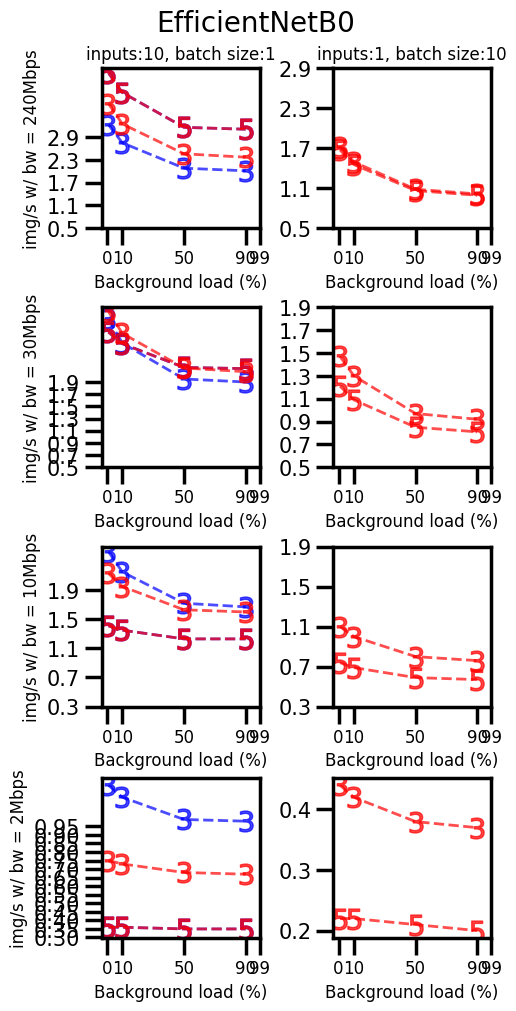

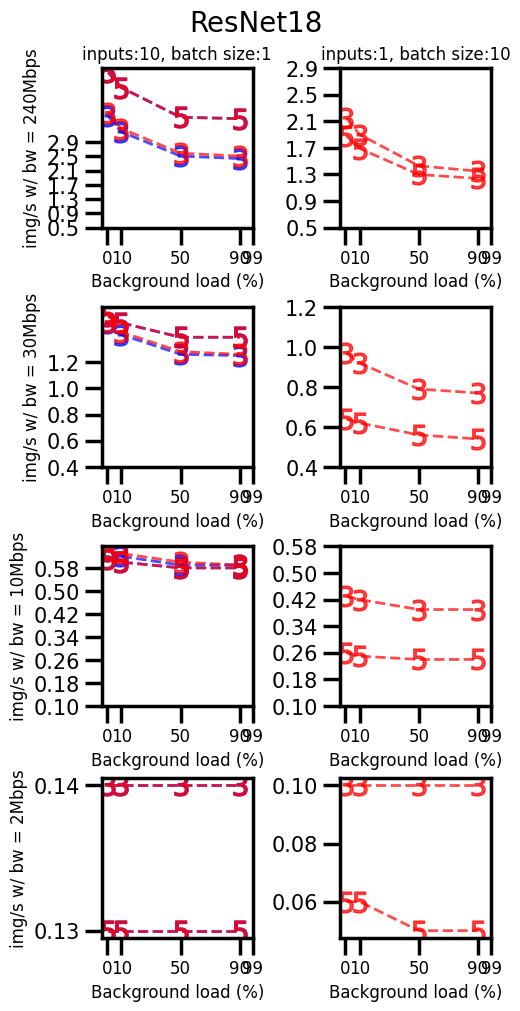

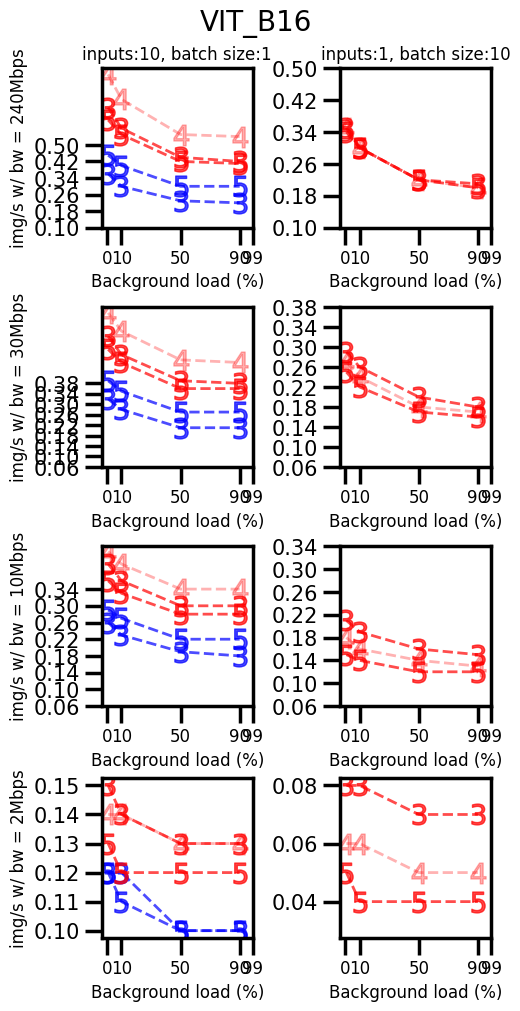

In [1499]:
# bws=[240, 2]
bws=[240, 30, 20, 15, 10, 2, 1]
import seaborn as sns
sns.set_context("poster", font_scale=1, rc={"font.size":7, "ytick.labelsize":15, "xtick.labelsize":12, "lines.linewidth":2, "axes.labelsize":12, "axes.titlesize":12})
# import seaborn as sns
# sns.set_context("talk", rc={"font.size":10, "axes.labelsize":35,"xtick.labelsize":35, "ytick.labelsize":35})

# bws=[240, 10, 1]
bws=[240, 30, 10, 2]
# bws=[240, 1]

combos = [[1,10], [2,5], [5,2], [10,1]]
combos = [[1,10], [10,1]]
inc_ind = [0, 3]
# combos = [[1,10], [10,1]]
# combos=[[1,100],[100,1]]
# combos = [[1,100], [2,50], [4,25], [5,20], [10,10], [20,5], [25,4], [50,2], [100,1]]
# eff_fig, eff_axs = plt.subplots(len(bws), len(combos), figsize=(25,10), layout='constrained')
eff_fig, eff_axs = plt.subplots(len(bws), len(combos), figsize=(5,10), layout='constrained')
# eff_fig, eff_axs = plt.subplots(len(bws), len(combos), figsize=(25,30), layout='constrained')
# res_fig, res_axs = plt.subplots(len(bws), len(combos), figsize=(25,10), layout='constrained')
res_fig, res_axs = plt.subplots(len(bws), len(combos), figsize=(5,10), layout='constrained')
# res_fig, res_axs = plt.subplots(len(bws), len(combos), figsize=(25,30), layout='constrained')
# vit_fig, vit_axs = plt.subplots(len(bws), len(combos), figsize=(25,10), layout='constrained')
vit_fig, vit_axs = plt.subplots(len(bws), len(combos), figsize=(5,10), layout='constrained')
# vit_fig, vit_axs = plt.subplots(len(bws), len(combos), figsize=(25,30), layout='constrained')
m=["eff", "resnet18","vit"]
overall_y = {model:[] for model in m }
overall_pred_y={model:[] for model in m}
overall_naive_y={model:[] for model in m}
for bw_ind, bw in enumerate(bws):
    # f=open(f"exploration.detailed.{bw}", "r")
    # f=open(f"exploration.detailed.{bw}.nw", "r")
    # f=open(f"exploration.detailed.{bw}.100img", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5", "r")
    f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4", "r")
    detailed_map = f.readlines()[0]
    detailed_map = literal_eval(detailed_map.strip())
    # print(detailed_map)
    for inp in detailed_map:
        for model in detailed_map[inp]:
            if model=="eff":
                eff_fig.suptitle("EfficientNetB0", fontsize=20)
            elif model=="resnet18":
                res_fig.suptitle("ResNet18", fontsize=20)
            elif model=="vit":
                vit_fig.suptitle("VIT_B16", fontsize=20)
            for world in detailed_map[inp][model]:
                # if world!=3 and world!=6:
                # if world!=6:
                #     continue
                x=sorted(list(detailed_map[inp][model][world]))
                # detailed_map[inp][model][world][x[0]]=[]
                for i in x:
                    #filter compute only runs
                    detailed_map[inp][model][world][i] = [detailed_map[inp][model][world][i][ind] for ind in range(len(detailed_map[inp][model][world][i])) if "nw" in detailed_map[inp][model][world][i][ind]]
                    # print(detailed_map[inp][model][world][i])
                # raise Exception("stop jhere?")
                # print(detailed_map[inp][model][world])
                for ind in range(len(detailed_map[inp][model][world][x[0]])):
                    if ind not in inc_ind:
                        continue
                    # if ind==2:
                    #     continue
                    # if ind > 2:
                    #     ind=ind-1
                    g_ind = ind if ind==inc_ind[0] else 1
                    if model=="eff":
                        axs = eff_axs[bw_ind][g_ind]
                    elif model=="vit":
                        axs = vit_axs[bw_ind][g_ind]
                    elif model=="resnet18":
                        axs=res_axs[bw_ind][g_ind]
                    # if "c" in detailed_map[inp][model][world][i][ind]
                    if bw==240:
                        # overall_y[model].extend([ detailed_map[inp][model][world][i][ind][0] for i in x])
                        overall_y[model].extend([ detailed_map[inp][model][3][x[0]][0][0] for i in x])
                        # overall_pred_y[model].extend([ detailed_map[inp][model][world][i][ind][3] for i in x])
                        overall_pred_y[model].extend([ detailed_map[inp][model][3][x[0]][0][3] for i in x])
                        # overall_naive_y[model].extend([ detailed_map[inp][model][world][i][ind][4] for i in x])
                        overall_naive_y[model].extend([ detailed_map[inp][model][3][x[0]][0][4] for i in x])

                    # y=[ round(inp/detailed_map[inp][model][world][i][ind][0],2) for i in x]
                    # y=[ round(inp/detailed_map[inp][model][world][i][ind][0],2) for i in x]
                    y=[ round(inp/detailed_map[inp][model][world][i][ind][3],2) for i in x]
                    # pred_y = [inp/detailed_map[inp][model][world][i][ind][0] for i in x]

                    # y_err = [ 1/(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1]) for i in x]
                    bs = f"{detailed_map[inp][model][world][x[0]][ind][2]}"
                    num_inp = f"{detailed_map[inp][model][world][x[0]][ind][1]}"

                    y_err = [ 5/(10*(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1])) for i in x]
                    # y_err = [np.std(y) for i in x]
                    str_label = f"{detailed_map[inp][model][world][x[0]][ind][1]}_{detailed_map[inp][model][world][x[0]][ind][2]}_{world}"
                    t_x = [ round(100*i/map_sub[subcluster],2) for i in x]
                    # axs.plot(t_x,y, marker=f"${world}$", markersize=10 ,linestyle="--")
                    # fig, axs = plt.subplot(figsize=(25,10))
                    # axs.errorbar
                    # axs.errorbar(t_x,y, y_err, marker=f"${world}$", markersize=15 ,linestyle="--", color="blue")
                    axs.plot(t_x,y, marker=f"${world}$", markersize=15 ,linestyle="--", color="blue", alpha=0.7 if world in [3,5] else 0)
                    # axs.text(x[-1],y[-1],str_label)
                    axs.set_xlabel("Background load (%)")
                    # axs.set_ylabel(f"Throughput (10img/s) w/ bw = {bw}Mbps")
                    if g_ind==0:
                        axs.set_ylabel(f"img/s w/ bw = {bw}Mbps")
                    if bw_ind==0:
                        # axs.set_title(f"number of inputs:{bs}, batch size:{num_inp}, b/w:{bw}Mbps")
                        axs.set_title(f"inputs:{num_inp}, batch size:{bs}")
                    # axs.set_xticks(np.arange(0,100,10))
                    if model=="eff":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5,2.8, 0.2))
                        # elif bw==10:
                            # axs.set_yticks()
                            # pass
                        elif bw==2:
                            axs.set_yticks(np.arange(0.15, 1, 0.05))
                    if model=="resnet18":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5, 2.8, 0.2))
                        if bw==2:
                            axs.set_yticks(np.arange(0.05, 0.17, 0.01))
                    if model=="vit":
                        if bw==240:
                            axs.set_yticks(np.arange(0.1, 0.48, 0.02))
                        if bw==2:
                            axs.set_yticks(np.arange(0.03, 0.18, 0.01))

                # break
                

            # axs.set_title(f"{model}_{bw}mbps splits {world}")
            # break
            # axs.legend()
                
                    # str_label = [f"{detailed_map[inp][model][world][i][1]}_{detailed_map[inp][model][world][i][2]}" for i in x]
print(f"fmt is bn_bs")

for model in m:
    y=overall_y[model]
    pred_y = overall_pred_y[model]
    # print(f"average best time for {model}: {np.mean(best_y[model])}, std dev: {np.std(best_y[model])}")
    print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    print(f"overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
    print(f"overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
    print(f"avg lat {model}: {np.median(y)}, std dev:{np.std(y)}")

    print()
    pred_y = overall_naive_y[model]
    print(f"naive overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(pred_y))]) )}")
    print(f"naive overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(pred_y))])}")
    print(f"naive overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(pred_y))])}%")
    print()


for bw_ind, bw in enumerate(bws):
    # f=open(f"exploration.detailed.{bw}", "r")
    # f=open(f"exploration.detailed.{bw}.nw", "r")
    # f=open(f"exploration.detailed.{bw}.100img", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5", "r")
    f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4", "r")

    detailed_map = f.readlines()[0]
    detailed_map = literal_eval(detailed_map.strip())
    # print(detailed_map)
    for inp in detailed_map:
        for model in detailed_map[inp]:
            # if model=="eff":
            #     eff_fig.suptitle(model)
            # elif model=="resnet18":
            #     res_fig.suptitle(model)
            # elif model=="vit":
            #     vit_fig.suptitle(model)
            for world in detailed_map[inp][model]:
                # if world!=3 and world!=6:
                # if world!=6:
                #     continue
                x=sorted(list(detailed_map[inp][model][world]))
                for i in x:
                    #filter compute only runs
                    detailed_map[inp][model][world][i] = [detailed_map[inp][model][world][i][ind] for ind in range(len(detailed_map[inp][model][world][i])) if "c" in detailed_map[inp][model][world][i][ind]]

                # detailed_map[inp][model][world][x[0]]=[]
                for ind in range(len(detailed_map[inp][model][world][x[0]])):
                    # if ind==2:
                    #     continue
                    # if ind > 2:
                    #     ind=ind-1
                    if ind not in inc_ind:
                        continue
                    g_ind = ind if ind==inc_ind[0] else 1

                    if model=="eff":
                        axs = eff_axs[bw_ind][g_ind]
                    elif model=="vit":
                        axs = vit_axs[bw_ind][g_ind]
                    elif model=="resnet18":
                        axs=res_axs[bw_ind][g_ind]
                    if bw==240:
                        # overall_y[model].extend([ detailed_map[inp][model][world][i][ind][0] for i in x])
                        overall_y[model].extend([ detailed_map[inp][model][3][x[0]][0][0] for i in x])
                        # overall_pred_y[model].extend([ detailed_map[inp][model][world][i][ind][3] for i in x])
                        overall_pred_y[model].extend([ detailed_map[inp][model][3][x[0]][0][3] for i in x])
                        # overall_naive_y[model].extend([ detailed_map[inp][model][world][i][ind][4] for i in x])
                        overall_naive_y[model].extend([ detailed_map[inp][model][3][x[0]][0][4] for i in x])

                    # y=[ inp/detailed_map[inp][model][world][i][ind][0] for i in x]
                    # y=[ round(inp/detailed_map[inp][model][world][i][ind][0],2) for i in x]
                    y=[ round(inp/detailed_map[inp][model][world][i][ind][3],2) for i in x]
                    # if world==3:
                    #     print([detailed_map[inp][model][world][i][ind][3] for i in x], "C")
                    # pred_y = [inp/detailed_map[inp][model][world][i][ind][0] for i in x]

                    # y_err = [ 1/(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1]) for i in x]
                    bs = f"{detailed_map[inp][model][world][x[0]][ind][2]}"
                    num_inp = f"{detailed_map[inp][model][world][x[0]][ind][1]}"

                    y_err = [ 5/(10*(detailed_map[inp][model][world][i][ind][0]+detailed_map[inp][model][world][i][ind][-1])) for i in x]
                    # y_err = [np.std(y) for i in x]
                    # print(f"for bg_load {}")
                    str_label = f"{detailed_map[inp][model][world][x[0]][ind][1]}_{detailed_map[inp][model][world][x[0]][ind][2]}_{world}"
                    t_x = [ round(100*i/map_sub[subcluster],2) for i in x]
                    # axs.plot(t_x,y, marker=f"${world}$", markersize=10 ,linestyle="--")
                    # fig, axs = plt.subplot(figsize=(25,10))
                    # axs.errorbar
                    # axs.errorbar(t_x,y, y_err, marker=f"${world}$", markersize=15 ,linestyle="--", color="red")
                    axs.plot(t_x,y, marker=f"${world}$", markersize=15 ,linestyle="--", color="red", alpha=0.7 if world in [3,5] else (0 if model!="vit" else (0.3 if world==4 else 0)))
                    # axs.text(x[-1],y[-1],str_label)
                    axs.set_xlabel("Background load (%)")
                    # axs.set_ylabel(f"Throughput (10img/s) w/ bw = {bw}Mbps")
                    if g_ind==0:
                        axs.set_ylabel(f"img/s w/ bw = {bw}Mbps")
                    if bw_ind==0:
                        # axs.set_title(f"number of inputs:{bs}, batch size:{num_inp}, b/w:{bw}Mbps")
                        axs.set_title(f"inputs:{num_inp}, batch size:{bs}")
                    axs.set_xticks([0,10,50,90,99])
                    if model=="eff":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5,3.4, 0.6))
                        elif bw==10:
                            axs.set_yticks(np.arange(0.3, 2.3, 0.4))
                        elif bw==30:
                            axs.set_yticks(np.arange(0.5,2.0, 0.2))

                        # elif bw==10:
                            # axs.set_yticks()
                            # pass
                        elif bw==1:
                            axs.set_yticks(np.arange(0.1, 1, 0.2))
                    if model=="resnet18":
                        if bw==240:
                            axs.set_yticks(np.arange(0.5, 3, 0.4))
                        elif bw==10:
                            axs.set_yticks(np.arange(0.1, 0.63, 0.08))
                        elif bw==30:
                            axs.set_yticks(np.arange(0.4,1.4, 0.2))
                        if bw==1:
                            axs.set_yticks(np.arange(0.02, 0.09, 0.01))
                    if model=="vit":
                        if bw==240:
                            axs.set_yticks(np.arange(0.1, 0.54, 0.08))
                        if bw==30:
                            axs.set_yticks(np.arange(0.06, 0.41, 0.04))
                        if bw==10:
                            axs.set_yticks(np.arange(0.06, 0.35, 0.04))
                        if bw==1:
                            axs.set_yticks(np.arange(0.01, 0.11, 0.02))

                # break
                

            # axs.set_title(f"{model}_{bw}mbps splits {world}")
            # break
            # axs.legend()
print(f"fmt is bn_bs for comp")

for model in m:
    y=overall_y[model]
    pred_y = overall_pred_y[model]
    print(f"average best time for {model}: {np.mean(best_y[model])}, std dev: {np.std(best_y[model])}")
    print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    # print(f"overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(y))]) )}")
    print(f"overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(y))])}")
    print(f"overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(y))])}%")
    print(f"avg lat {model}: {np.median(y)}, std dev:{np.std(y)}")
    print()
    pred_y = overall_naive_y[model]
    print(f"naive overall rmse {model}: {np.sqrt( np.mean([ (y[i]-pred_y[i])**2  for i in range(len(pred_y))]) )}")
    print(f"naive overall mae {model}:  {np.mean([ abs(y[i]-pred_y[i])  for i in range(len(pred_y))])}")
    print(f"naive overall mape {model}: {100*np.mean([ abs(y[i]-pred_y[i])/(y[i])  for i in range(len(pred_y))])}%")
    print()

# eff_fig.savefig("eff_explore.pdf")
# res_fig.savefig("res_explore.pdf")
# vit_fig.savefig("vit_explore.pdf")

{3: {'eff': {'c': [2.37, 2.26, 2.07, 1.6, 0.67], 'nw': [2.01, 1.97, 1.9, 1.67, 0.98]}, 'vit': {'c': [0.42, 0.41, 0.38, 0.3, 0.13], 'nw': [0.22, 0.22, 0.21, 0.18, 0.1]}, 'resnet18': {'c': [2.51, 1.87, 1.26, 0.59, 0.14], 'nw': [2.44, 1.83, 1.25, 0.59, 0.14]}}, 4: {'eff': {'c': [2.31, 2.06, 1.72, 1.08, 0.34], 'nw': [2.22, 2.11, 1.94, 1.49, 0.63]}, 'vit': {'c': [0.54, 0.51, 0.46, 0.34, 0.13], 'nw': [0.28, 0.27, 0.26, 0.21, 0.11]}, 'resnet18': {'c': [3.18, 2.2, 1.39, 0.61, 0.14], 'nw': [2.51, 1.82, 1.2, 0.55, 0.13]}}, 5: {'eff': {'c': [3.11, 2.68, 2.12, 1.23, 0.35], 'nw': [3.11, 2.68, 2.12, 1.23, 0.35]}, 'vit': {'c': [0.41, 0.39, 0.36, 0.28, 0.12], 'nw': [0.3, 0.29, 0.27, 0.22, 0.1]}, 'resnet18': {'c': [3.56, 2.31, 1.39, 0.58, 0.13], 'nw': [3.56, 2.31, 1.39, 0.58, 0.13]}}, 6: {'eff': {'c': [3.11, 2.67, 2.12, 1.22, 0.35], 'nw': [3.11, 2.67, 2.12, 1.22, 0.35]}, 'vit': {'c': [0.54, 0.5, 0.44, 0.32, 0.12], 'nw': [0.32, 0.31, 0.29, 0.23, 0.1]}, 'resnet18': {'c': [3.55, 2.29, 1.38, 0.57, 0.13], '

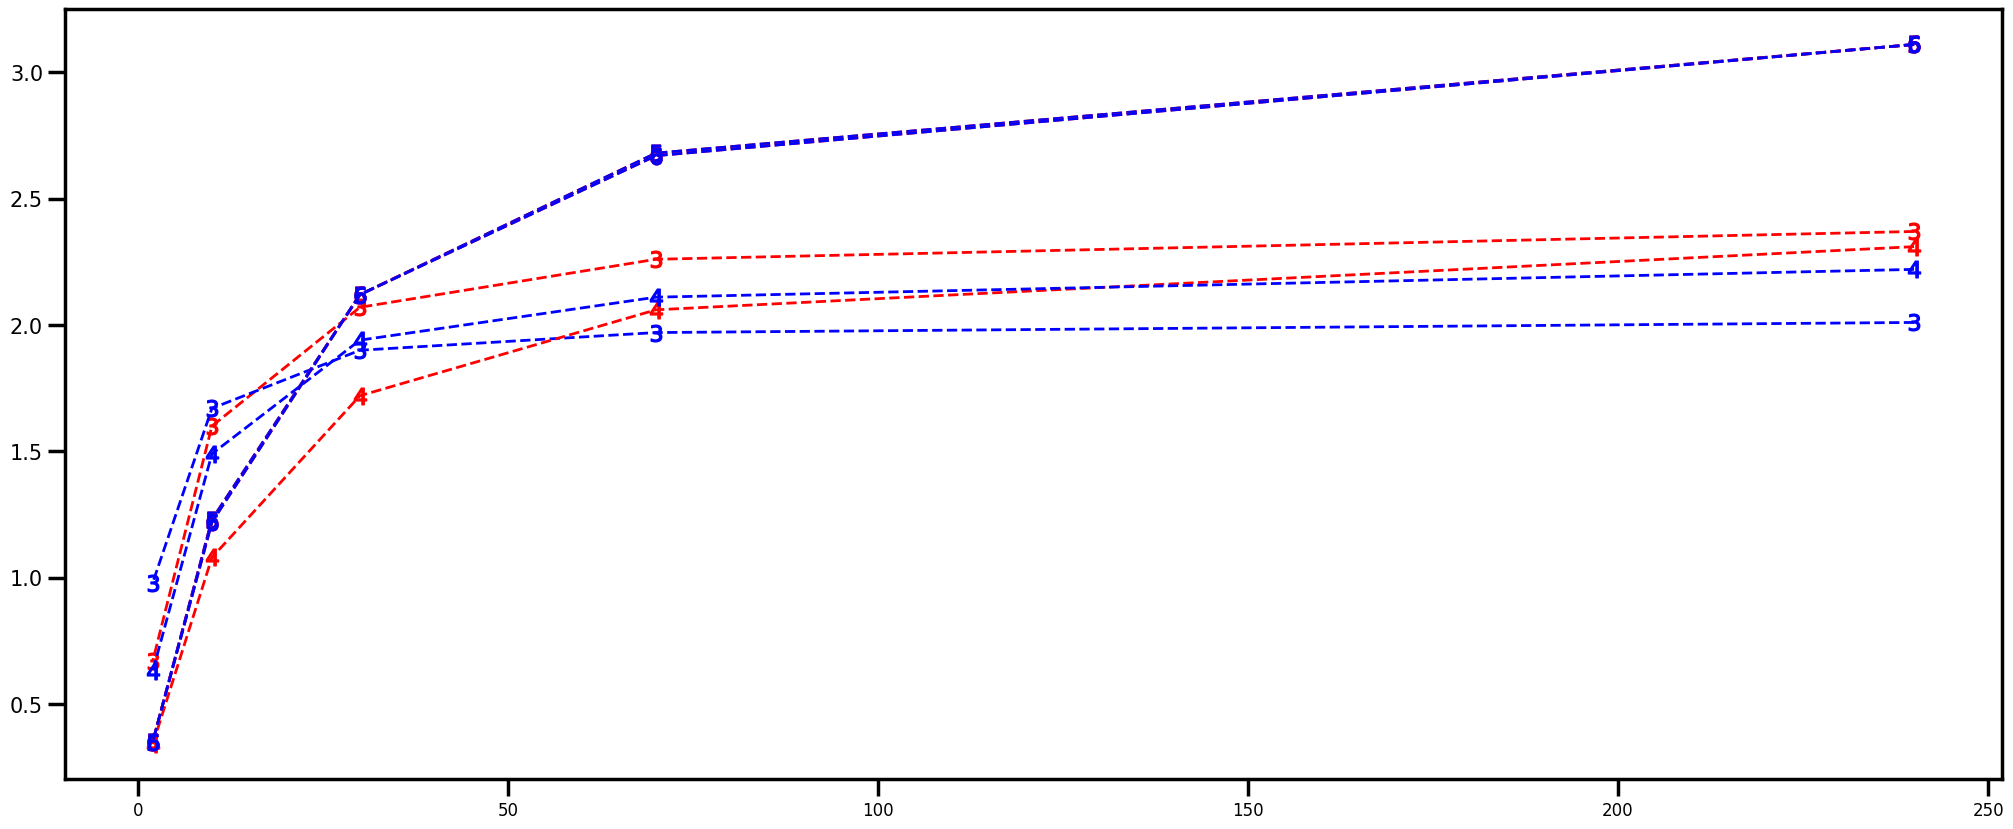

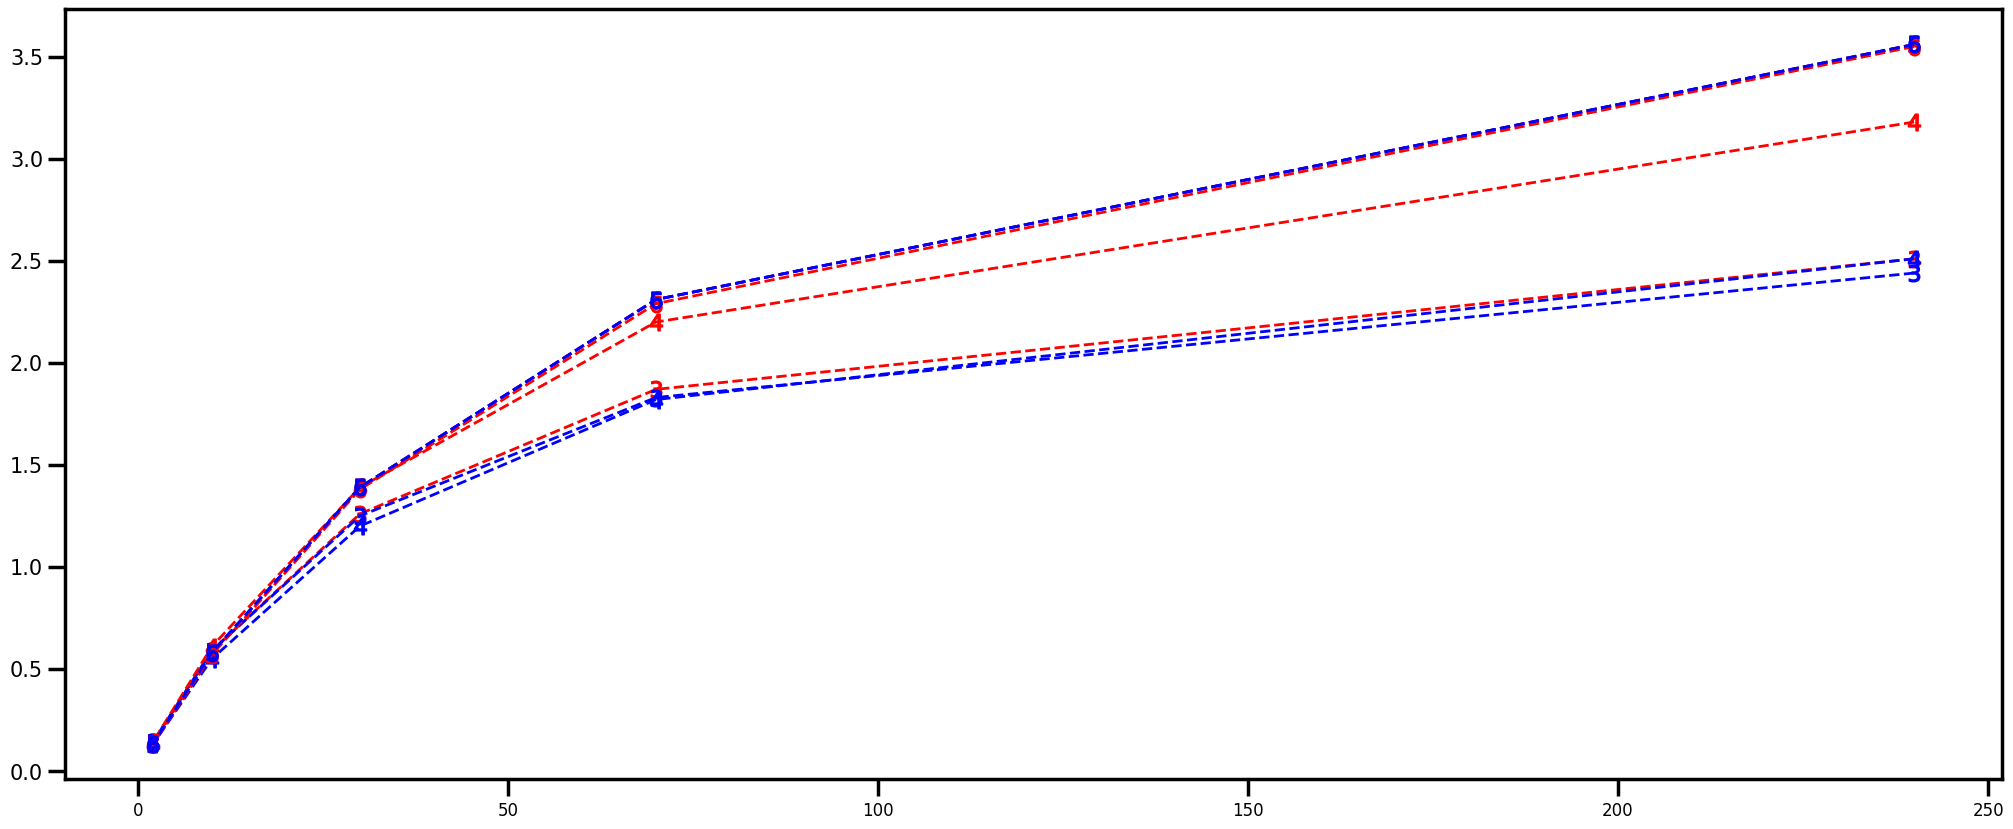

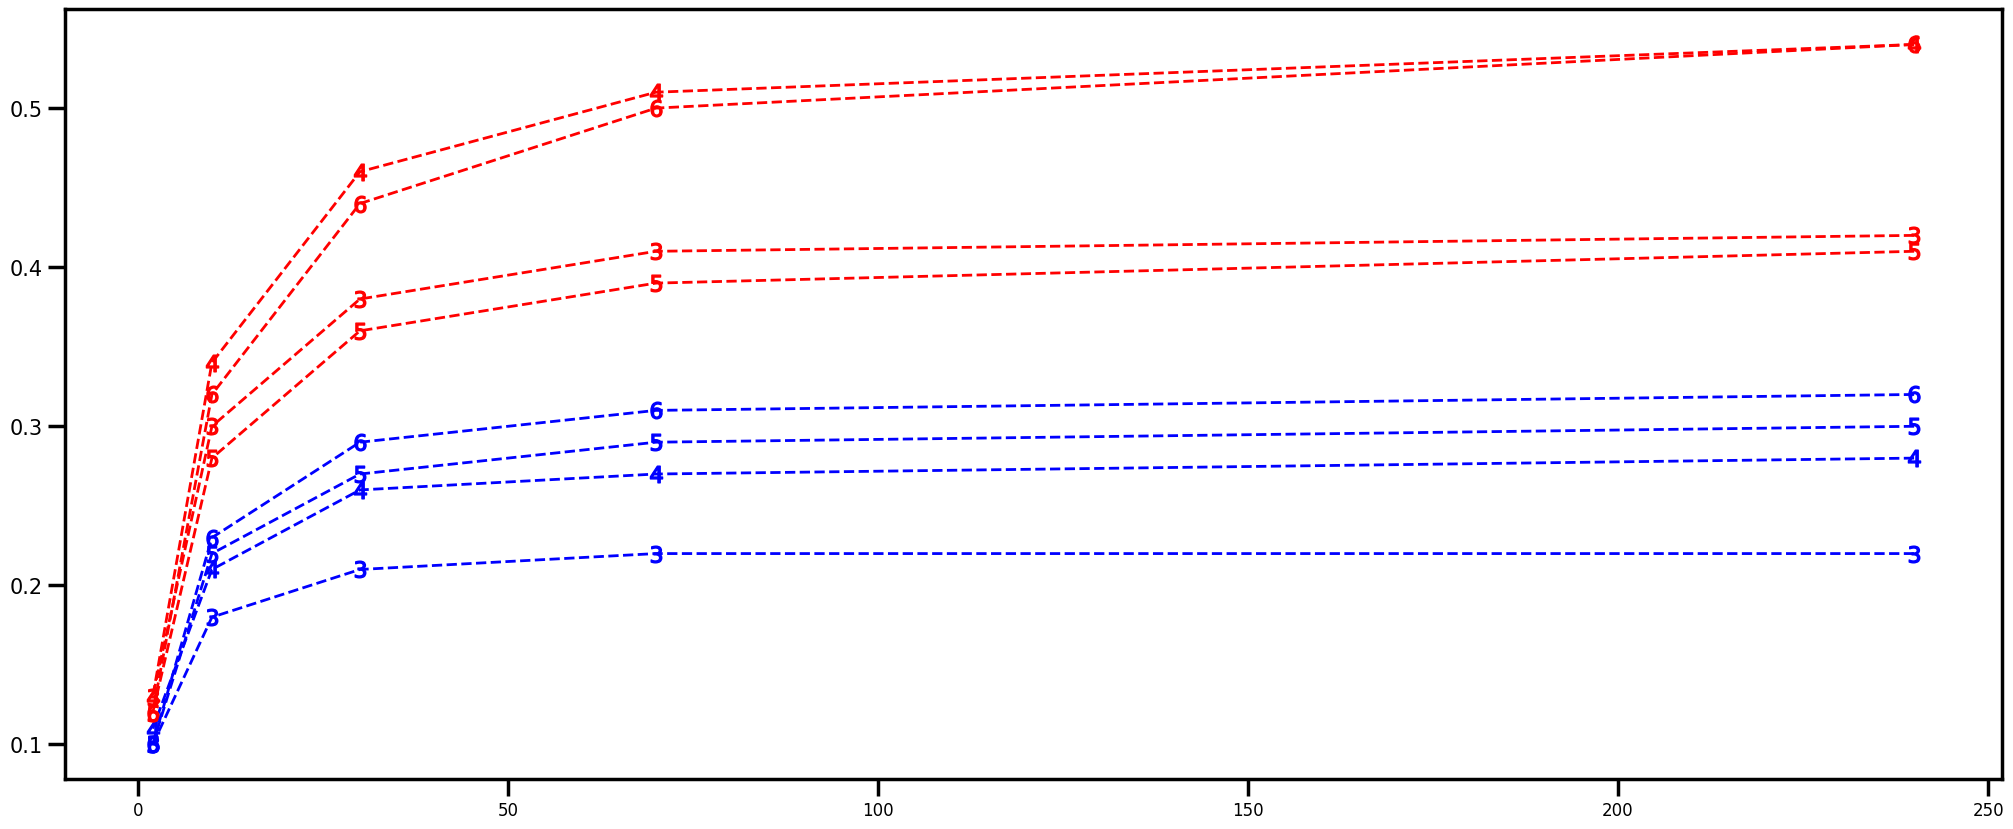

In [1501]:
#against changing network instead
bws = [240, 70, 30, 10,2]
world_to_throughput = {r:{} for r in [3,4,5,6]}
for bw_ind, bw in enumerate(bws):
    # f=open(f"exploration.detailed.{bw}", "r")
    # f=open(f"exploration.detailed.{bw}.nw", "r")
    # f=open(f"exploration.detailed.{bw}.100img", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop", "r")
    # f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5", "r")
    f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4", "r")
    detailed_map = f.readlines()[0]
    detailed_map = literal_eval(detailed_map.strip())
    # print(detailed_map)
    for inp in detailed_map:
        # print(inp)
        for model in detailed_map[inp]:
            # if model=="eff":
            #     eff_fig.suptitle(model)
            # elif model=="resnet18":
            #     res_fig.suptitle(model)
            # elif model=="vit":
            #     vit_fig.suptitle(model)
            for world in detailed_map[inp][model]:
                if model not in world_to_throughput[world]:
                    world_to_throughput[world][model]={"c":[],"nw":[]}
                # if world!=3 and world!=6:
                # if world!=6:
                #     continue
                # x=sorted(list(detailed_map[inp][model][world]))
                for bg_load in detailed_map[inp][model][world]:
                    bg = round(100*bg_load/map_sub[subcluster],2)
                    # print(bg)
                    if bg == 90:
                        # print(detailed_map[inp][model][world][bg_load][0])
                        for entry in detailed_map[inp][model][world][bg_load]:
                            if "c" in entry and entry[2]==1 and entry[1]==10:
                                world_to_throughput[world][model]["c"].append(round(10/entry[3],2))
                            if "nw" in entry and entry[2]==1 and entry[1]==10:
                                world_to_throughput[world][model]["nw"].append(round(10/entry[3],2))

                        # if "c" in detailed_map[inp][model][world][bg_load][0]:
print(world_to_throughput)
for model in ["eff", "resnet18", "vit"]:
    fig, axs = plt.subplots(figsize=(25,10))
    for w in world_to_throughput:
        if w in [3,4,5,6]:
            axs.plot(bws, world_to_throughput[w][model]['c'], linestyle="--", marker=f"${w}$", color="red")
            axs.plot(bws, world_to_throughput[w][model]['nw'], linestyle="--", marker=f"${w}$", color="blue")


In [ ]:
#simulation check!
#third result -> rmse, mae, mape low when using the curve
#best trial and how close greedy is compared to only_compute or only_communicate
#also check unthrottled devices are actually staying unthrottled lmao xd

#projected throughput per util -> need to fix how util calculated though with overhead!
# TODO
#also do achived throughput per util, instead of projected! see how tgat changes?
bws = [240, 5, 2]
iats = [0.01, 0.5, 1.0, 10.0]
sub="bramble-2-4"
inp=10
for model in m:
    # print(model)
    fig, axs = plt.subplots(figsize=(25,10))
    util_to_th_map={}
    for iat in iats:
        text_labels = []
        for bw in bws:
            filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.{sub}.eff.{bw}.{iat}"
            ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename)
            # print(overhead)
            # raise Exception("end it")
            real_ts={}
            visited=[]
            for j in ts:
                if j not in real_ts:
                    real_ts[j]=0
                if j in visited:
                    continue
                visited.append(j)
                # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", "vit", world[j], overhead[j]-1,
                # bs[j], bn[j], bw=bw, ty=ty[j]) + added_time[j]
                real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, "eff", world[j], overhead[j],
                bs[j], bn[j], bw=bw, ty=ty[j])
                arr_t = added_time[j][0]
                wait_t = added_time[j][1]
                real_ts[j] = arr_t+wait_t+real_ts[j] 
                # print(real_ts[j])
                if overhead[j] not in util_to_th_map:
                    util_to_th_map[overhead[j]] = []
                util_to_th_map[overhead[j]].append( [round(float(inp*len(ts.values())/(real_ts[j])),3), f"{j}_{bw}_{iat}" ])
                
        # print(util_to_th_map)
        x = sorted( [i for i in list(util_to_th_map.keys()) ])
        y = [[i for i in set([j[0] for j in util_to_th_map[i]])] for i in x]
        text_y = [[i[1] for i in util_to_th_map[i]] for i in x]
        x = [round(100*i/map_sub[sub],2) for i in x]
        # print(x,y)
        for i in range(len(y)):
            axs.scatter( [x[i]]*len(y[i]),y[i])
            # axs.scatter( x[i], max(y[i]))
            # axs.text(x[i], max(y[i]),text_y[i][0])
            for j in range(len(y[i])):
                axs.text(x[i], y[i][j], text_y[i][j])




In [ ]:
#simulation check!
#third result -> rmse, mae, mape low when using the curve
#best trial and how close greedy is compared to only_compute or only_communicate
#also check unthrottled devices are actually staying unthrottled lmao xd

#projected throughput per util -> need to fix how util calculated though with overhead!
# TODO
#also do achived throughput per util, instead of projected! see how tgat changes?
bws = [240, 5, 2]
# bws = [2]
iats = [0.01, 0.5, 1.0, 10.0]
sub="bramble-2-4"
inp=10
job_map = {}
for model in m:
    # print(model)
    fig, axs = plt.subplots(figsize=(25,10))
    axs1=axs.twinx()
    # axs.set_xscale("log")
    # axs1.set_xscale("log")

    if model not in job_map:
        job_map[model]={}
    
    for iat in iats:
        text_labels = []
        if iat not in job_map[model]:
            job_map[model][iat]={}
        
        for bw in bws:
            if bw not in job_map[model][iat]:
                job_map[model][iat][bw]={}
            filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.{sub}.{model}.{bw}.{iat}"
            ts, overhead, bs, bn, world, added_time, ty, ts_map = simulation_reader(filename)
            # print(overhead)
            # raise Exception("end it")
            real_ts_map={}
            ts_list = sorted(list(ts_map.keys()))

            real_ts={}
            for j in ts:
                if j not in real_ts:
                    real_ts[j]=0
                #final run time, based on arrival time, construct 
                real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, "eff", world[j], overhead[j],
                bs[j], bn[j], bw=bw, ty=ty[j])
                arr_t = added_time[j][0]
                wait_t = added_time[j][1]
                # if arr_t not in real_ts_map:
                #     real_ts_map[arr_t] = []
                for r in range(world[j]):
                    t= f"{j}_{r}"
                    # [t, w_t, r_t, arr_t, world, bn, bs ]
                    for ts_ind in ts_list:
                        if ts_ind not in real_ts_map:
                            real_ts_map[ts_ind]=[]
                        # print(ts_ind, arr_t, wait_t, real_ts[j], ts_ind >= arr_t, ts_ind <= arr_t+wait_t+real_ts[j])
                        if ts_ind >= arr_t and ts_ind <= arr_t+wait_t+real_ts[j]:
                            # print(ts_list)
                            if [t, wait_t, real_ts[j], arr_t, world[j], bn[j], bs[j]] not in real_ts_map[ts_ind]:
                                real_ts_map[ts_ind].append([t, wait_t, real_ts[j], arr_t, world[j], bn[j], bs[j]])

            # print([len(ts_map[k]) for k in ts_map.keys()])
            # print()
            # print([len(real_ts_map[k]) for k in real_ts_map.keys()])
            # raise Exception("end it")
            # fig, axs = plt.subplots(figsize=(25,10))
            x = sorted(list(real_ts_map.keys()))
            util_y = [round(100*len(real_ts_map[i])/map_sub[sub],2) for i in x]
            # util_y = [len(real_ts_map[i]) for i in x]
            util_per_s_y = []
            throughput_y = []
            for ind in range(len(x)):
                cur_set = set([i[0] for i in real_ts_map[x[ind]]])
                # if x[ind]!=0:
                #     util_per_s_y.append(util_y[ind]/x[ind])
                if ind+1 < len(x):
                    util_per_s_y.append(util_y[ind]/x[ind+1])
                    next_set = set([i[0] for i in real_ts_map[x[ind+1]]])
                else:
                    next_set = []
                    # util_per_s_y.append(0)
                inter_set = cur_set.intersection(next_set)
                fin_set = len(cur_set)-len(inter_set)
                if fin_set>0:
                    inps = [i[5]*i[6] for i in real_ts_map[x[ind]] if i[0] not in inter_set]
                    time_taken = max([i[1]+i[2]+i[3] for i in real_ts_map[x[ind]] if i[0] not in inter_set])
                    throughput_y.append(sum(inps)/time_taken)
                    if ind+1 >= len(x):
                        util_per_s_y.append(util_y[ind]/time_taken)
                else:
                    throughput_y.append(0)
            

            # axs.scatter( util_y, throughput_y, marker="x")
            # print( util_y, x, [0]+[util_y[i]/x[i] for i in range(1,len(x))], util_per_s_y)
            # print( throughput_y)
            # axs.plot( [np.log(i if i!=0 else 1) for i in util_y], [ np.log(i if i!=0 else 1) for i in throughput_y], marker="x", label=f"{iat}_{bw}")
            # axs.scatter( np.log(max(util_per_s_y)), np.log(max(throughput_y)), marker="x", label=f"{iat}_{bw}")
            # axs.set_xlabel("Util %")
            # axs.set_ylabel("Throughput img/s")
            # axs.legend()
            # # raise Exception("end it")
            # # axs.set_xscale("log")
            # # axs.set_yscale("log")
            # continue

            axs.plot(x,util_y, linestyle="--", marker="x", color="orange")
            axs.set_xlabel("Timestamp")
            axs.set_ylabel("Util %")
            # axs.set_title(f"Model:{model} bw:{bw}Mbps avg inter_arrival:{iat}s")
            axs1.set_ylabel("Throughput (inputs/s)")
            axs1.plot(x, throughput_y, linestyle="--", marker="x", color="blue")

            continue



            filename = f"../scheduler/sim.op.{sub}.{model}.{bw}.{iat}.only_best"
            ts, overhead, bs, bn, world, added_time, ty, ts_map = simulation_reader(filename)
            # print(overhead)
            # raise Exception("end it")
            real_ts_map={}
            ts_list = sorted(list(ts_map.keys()))

            real_ts={}
            for j in ts:
                if j not in real_ts:
                    real_ts[j]=0
                #final run time, based on arrival time, construct 
                real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit.csv", sub, "eff", world[j], overhead[j],
                bs[j], bn[j], bw=bw, ty=ty[j])
                arr_t = added_time[j][0]
                wait_t = added_time[j][1]
                # if arr_t not in real_ts_map:
                #     real_ts_map[arr_t] = []
                for r in range(world[j]):
                    t= f"{j}_{r}"
                    # [t, w_t, r_t, arr_t, world, bn, bs ]
                    for ts_ind in ts_list:
                        if ts_ind not in real_ts_map:
                            real_ts_map[ts_ind]=[]
                        # print(ts_ind, arr_t, wait_t, real_ts[j], ts_ind >= arr_t, ts_ind <= arr_t+wait_t+real_ts[j])
                        if ts_ind >= arr_t and ts_ind <= arr_t+wait_t+real_ts[j]:
                            # print(ts_list)
                            if [t, wait_t, real_ts[j], arr_t, world[j], bn[j], bs[j]] not in real_ts_map[ts_ind]:
                                real_ts_map[ts_ind].append([t, wait_t, real_ts[j], arr_t, world[j], bn[j], bs[j]])

            # print([len(ts_map[k]) for k in ts_map.keys()])
            # print()
            # print([len(real_ts_map[k]) for k in real_ts_map.keys()])
            # raise Exception("end it")
            # fig, axs = plt.subplots(figsize=(25,10))
            x = sorted(list(real_ts_map.keys()))
            util_y = [round(100*len(real_ts_map[i])/map_sub[sub],2) for i in x]
            throughput_y = []
            for ind in range(len(x)):
                cur_set = set([i[0] for i in real_ts_map[x[ind]]])
                if ind+1 < len(x):
                    next_set = set([i[0] for i in real_ts_map[x[ind+1]]])
                else:
                    next_set = []
                inter_set = cur_set.intersection(next_set)
                fin_set = len(cur_set)-len(inter_set)
                if fin_set>0:
                    inps = [i[5]*i[6] for i in real_ts_map[x[ind]] if i[0] not in inter_set]
                    time_taken = max([i[1]+i[2]+i[3] for i in real_ts_map[x[ind]] if i[0] not in inter_set])
                    throughput_y.append(fin_set/time_taken)
                else:
                    throughput_y.append(0)
            
            axs.plot(x,util_y, linestyle="--", marker="x", color="pink")
            axs.set_xlabel("Timestamp")
            axs.set_ylabel("Util %")
            # axs.set_title(f"Model:{model} bw:{bw}Mbps avg inter_arrival:{iat}s")
            axs1.set_ylabel("Throughput (inputs/s)")
            axs1.plot(x, throughput_y, linestyle="--", marker="x", color="green")

            # raise Exception("end it")
                # for run_set in real_ts_map[x[i]]:





                


            # for ts_ind in range(len(ts_list)-1):
            #     #emulated schedule run!
            #     cur_ts = ts_list[ts_ind]
            #     next_ts = ts_list[ts_ind]
            #     if cur_ts not in real_ts_map:
            #         real_ts_map[cur_ts]=[]
            #         real_ts_map[next_ts]=[]
            #     # ts_map[cur_ts][ind] = [t, w_t, r_t, ts, world, bn, bs ]
            #     job_map={}
            #     cur_overhead = len(ts_map[cur_ts])
            #     for ind in ts_map[cur_ts]:

                    # j_id = ts_map[cur_ts][ind][0].split("_")[0]
                    # if j_id not in job_map:
                    #     job_map[j_id] = []
                    # job_map[j_id] = 
                    # job_map[j_id].append([])
                    
            # best_fit_reader("best_fit.csv", sub, "eff", world[j], overhead[j], bs[j], bn[j], bw=bw, ty=ty[j])

            # visited=[]
            # for j in ts:
            #     if j not in real_ts:
            #         real_ts[j]=0
            #     if j in visited:
            #         continue
            #     # visited.append(j)
            #     real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit.csv", sub, "eff", world[j], overhead[j],
            #     bs[j], bn[j], bw=bw, ty=ty[j]) + added_time[j]
            #     if j not in job_map[model][iat][bw]:
            #         job_map[model][iat][bw][j] = []
                
            #     job_map[model][iat][bw][j].append([real_ts[j], overhead[j]])

#plot stuff here plz thenk
# for model in job_map:
#     fig, axs = plt.subplots(figsize=(25,10))
#     for iat in job_map[model]:

#         x = 
#         axs.plot()
                


/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.resnet18.30.0.01
total predicted time to completion of 16 jobs: 12.209470683616598, full throughput: 13.104581201435508, s/machine: 6.32832221057663
total real time to completion of 16 jobs: 12.946650770888805, full throughput: 12.358408582377772, s/machine: 7.1061250000000005
rmse: 0.9148323420851993
mape: 0.08028770711921994
/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.resnet18.30.0.01.only_comp only_comp
total predicted time to completion of 16 jobs: 12.209470683616598, full throughput: 13.104581201435508, s/machine: 6.32832221057663
total real time to completion of 16 jobs: 13.9084706836166, full throughput: 11.503780943254318, s/machine: 7.5815625
/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.resnet18.30.0.01.only_best only_best
total predicted time to completion of 16 jobs: 11.136, full throughput: 14

/var/folders/hw/swljgpyn0mn_cgf1fmg8gvsr0000gn/T/ipykernel_16486/2745037730.py:77: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(figsize=(25,10))


/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.eff.2.1.0.only_comp only_comp
total predicted time to completion of 16 jobs: 28.005000000000003, full throughput: 5.713265488305659, s/machine: 13.0749375
total real time to completion of 16 jobs: 29.872, full throughput: 5.356186395286556, s/machine: 14.820250000000005
/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.eff.2.1.0.only_comm only_comm
total predicted time to completion of 16 jobs: 23.026, full throughput: 6.948666724572223, s/machine: 8.080937500000003
total real time to completion of 16 jobs: 24.810000000000002, full throughput: 6.449012494961709, s/machine: 9.8100625
/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.eff.2.1.0.only_best only_best
total predicted time to completion of 16 jobs: 23.026, full throughput: 6.948666724572223, s/machine: 8.026000000000002
total real time to completion of 16 j

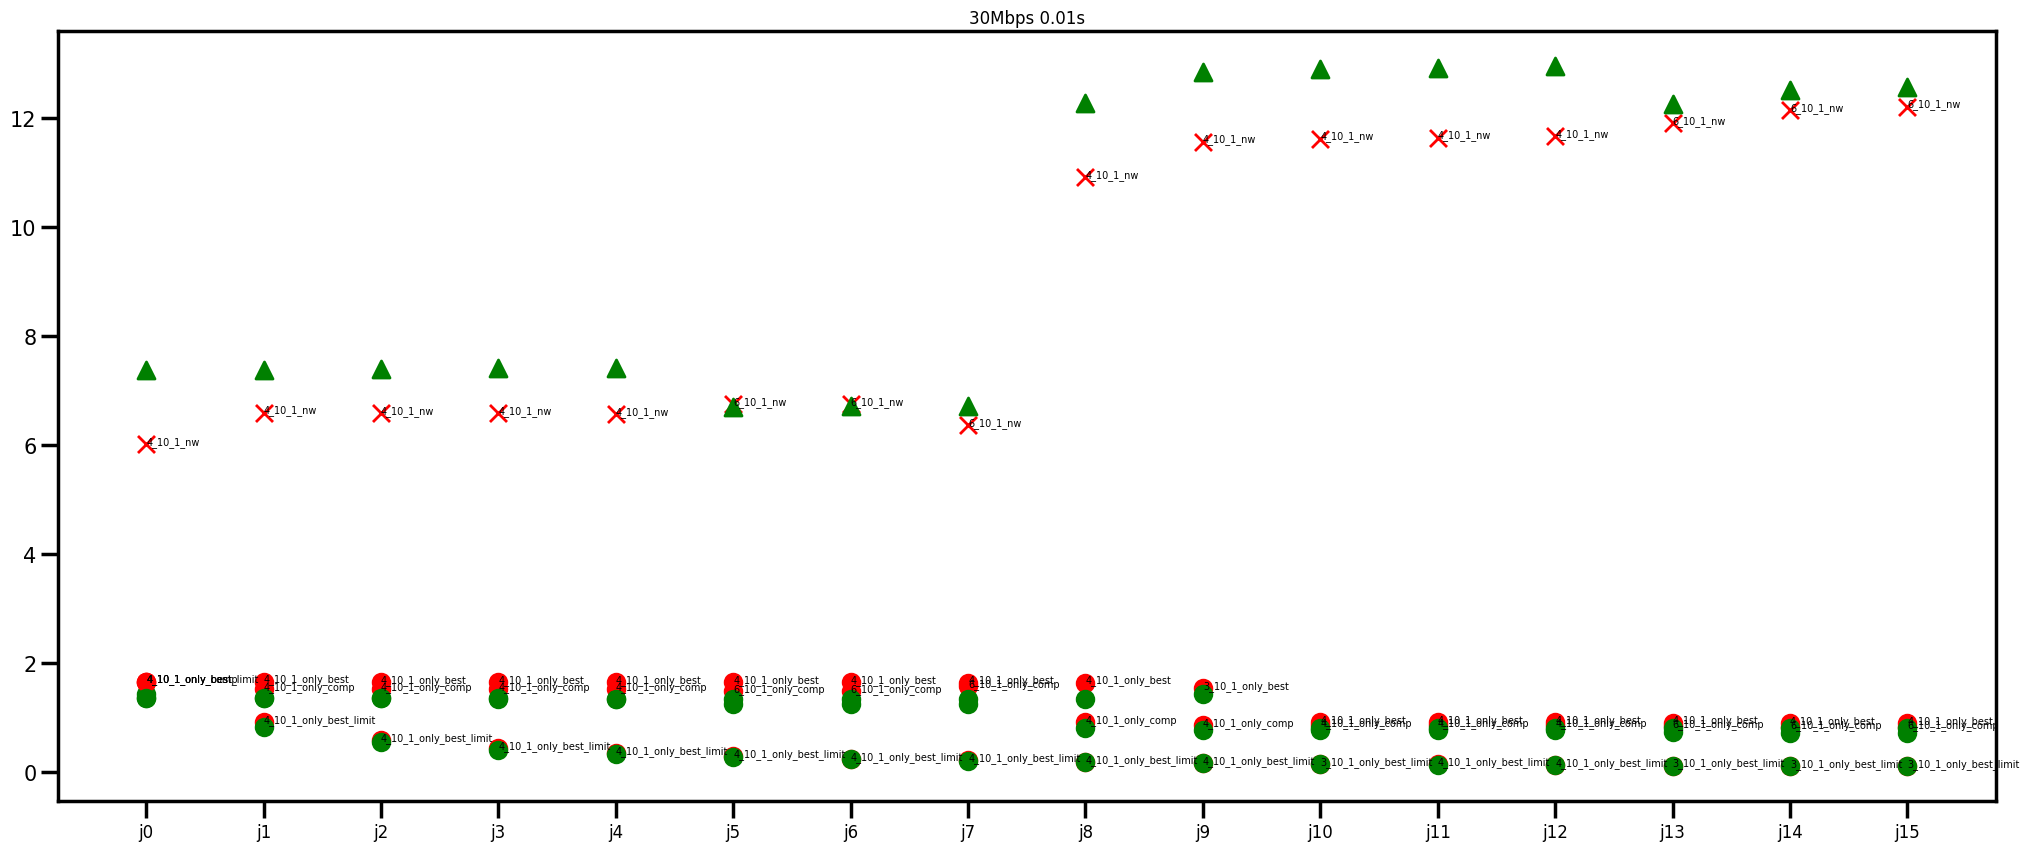

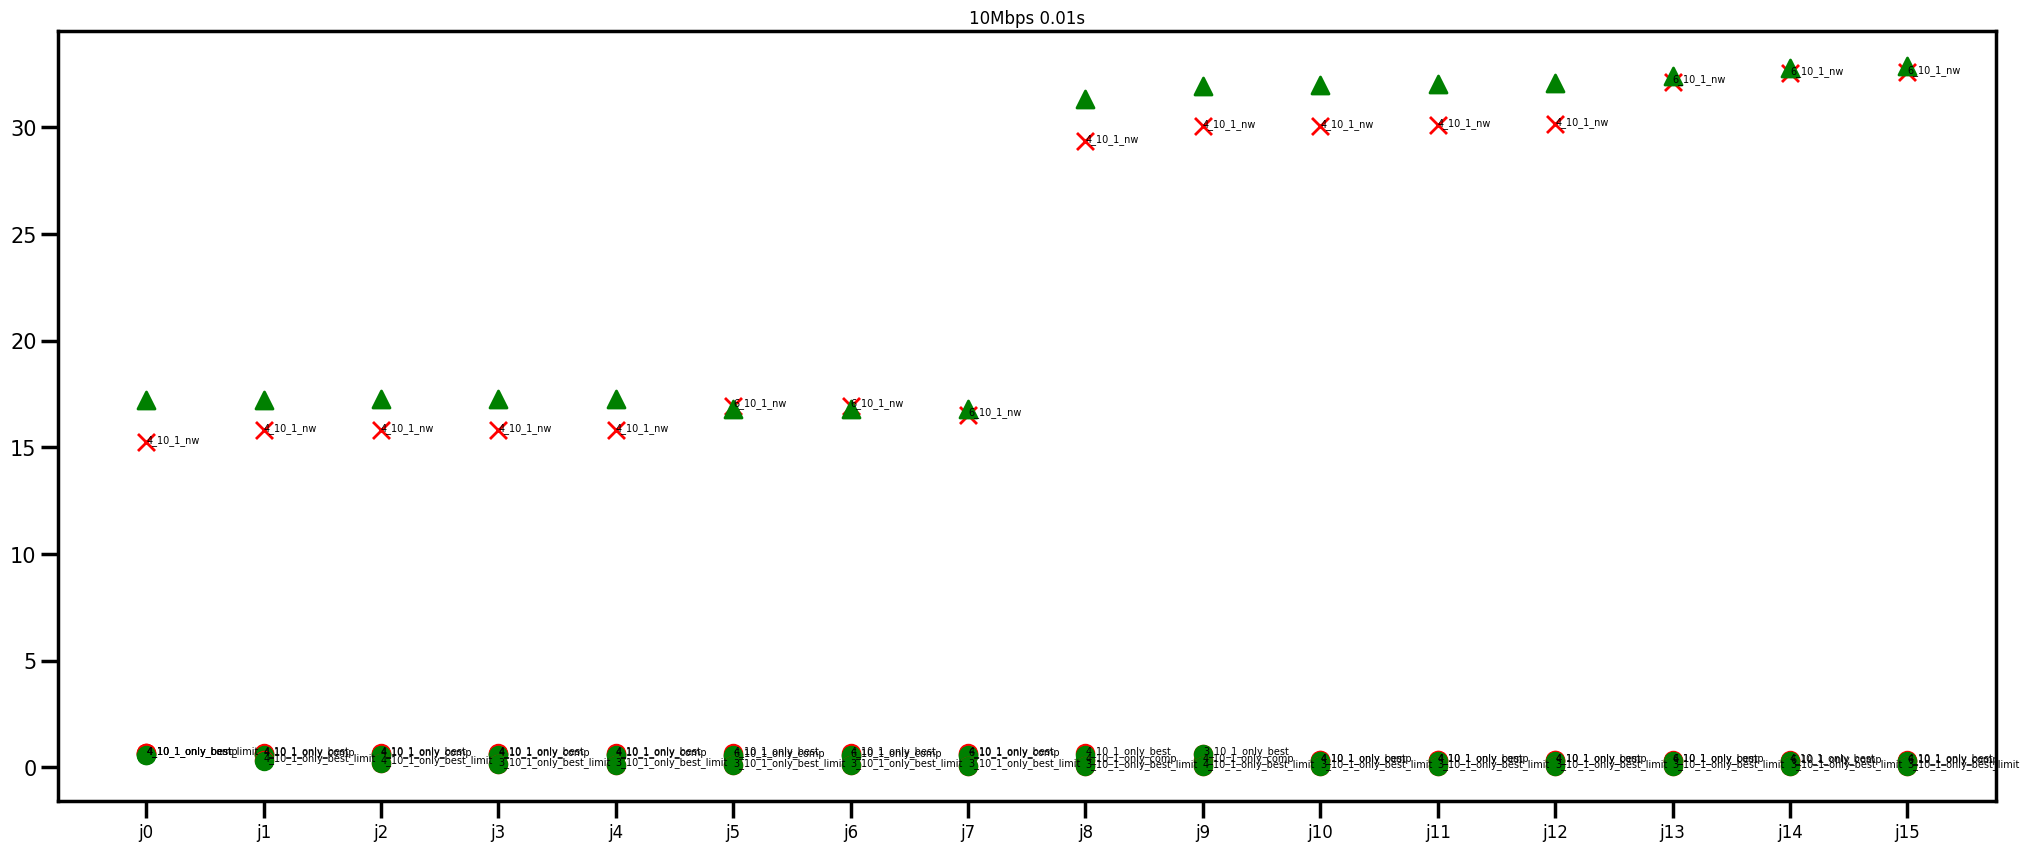

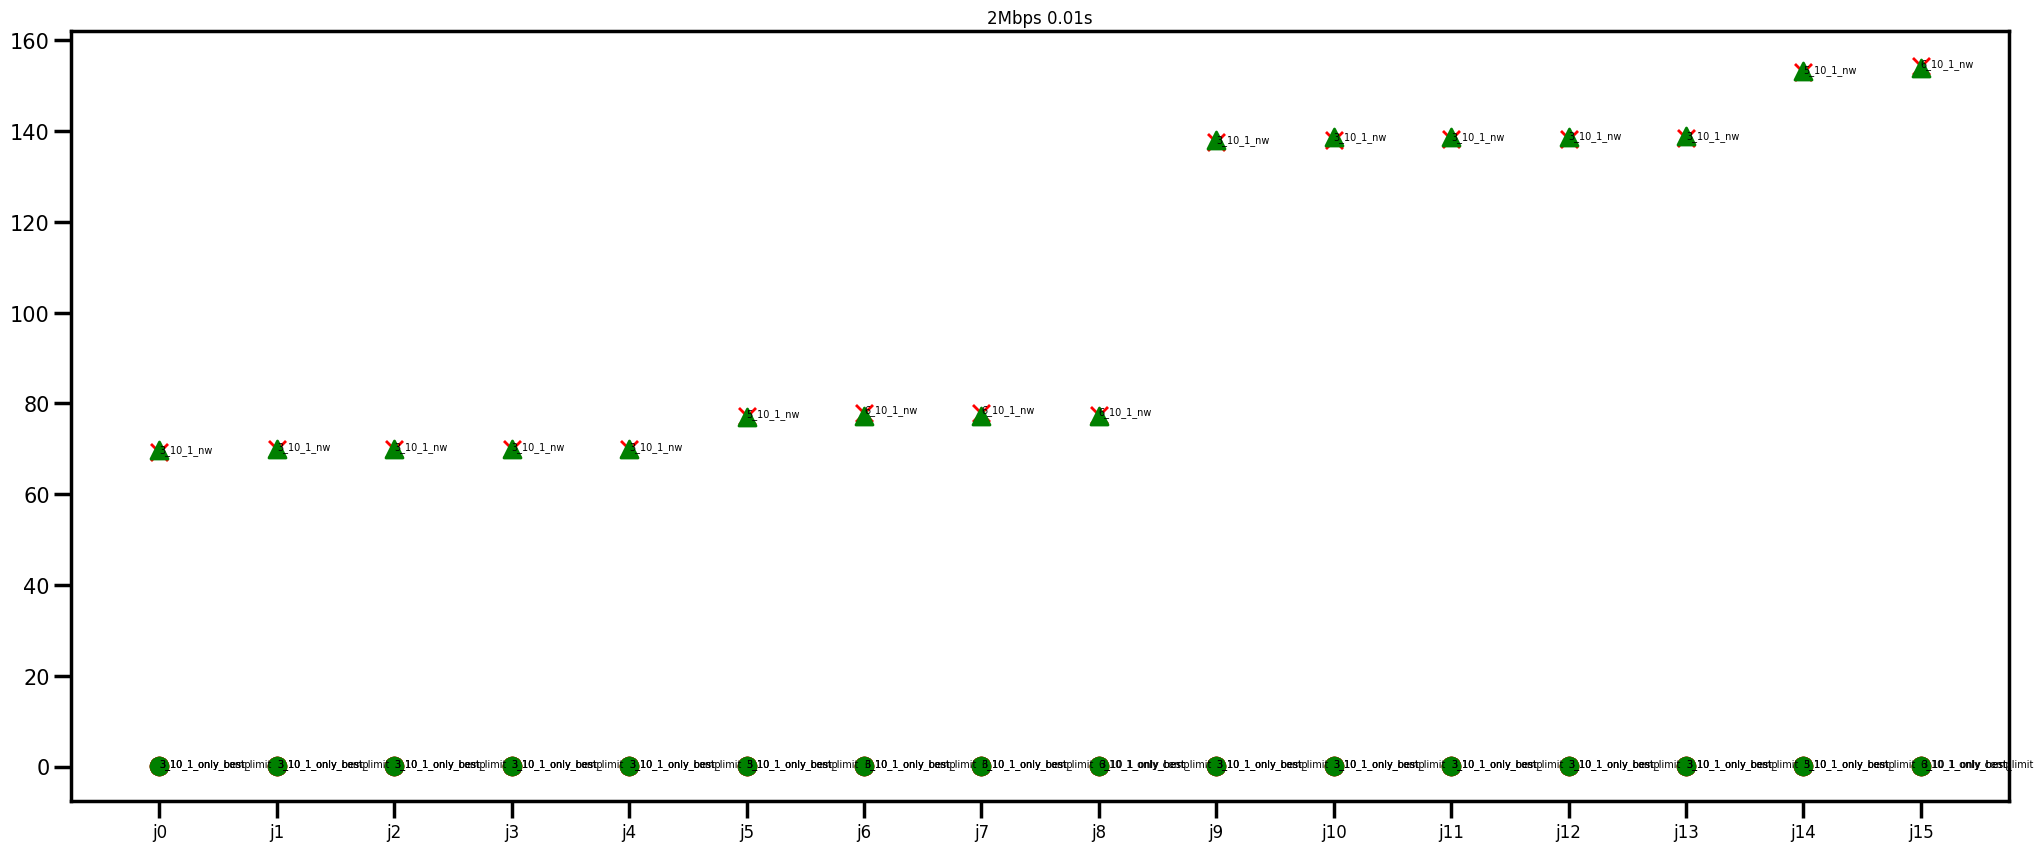

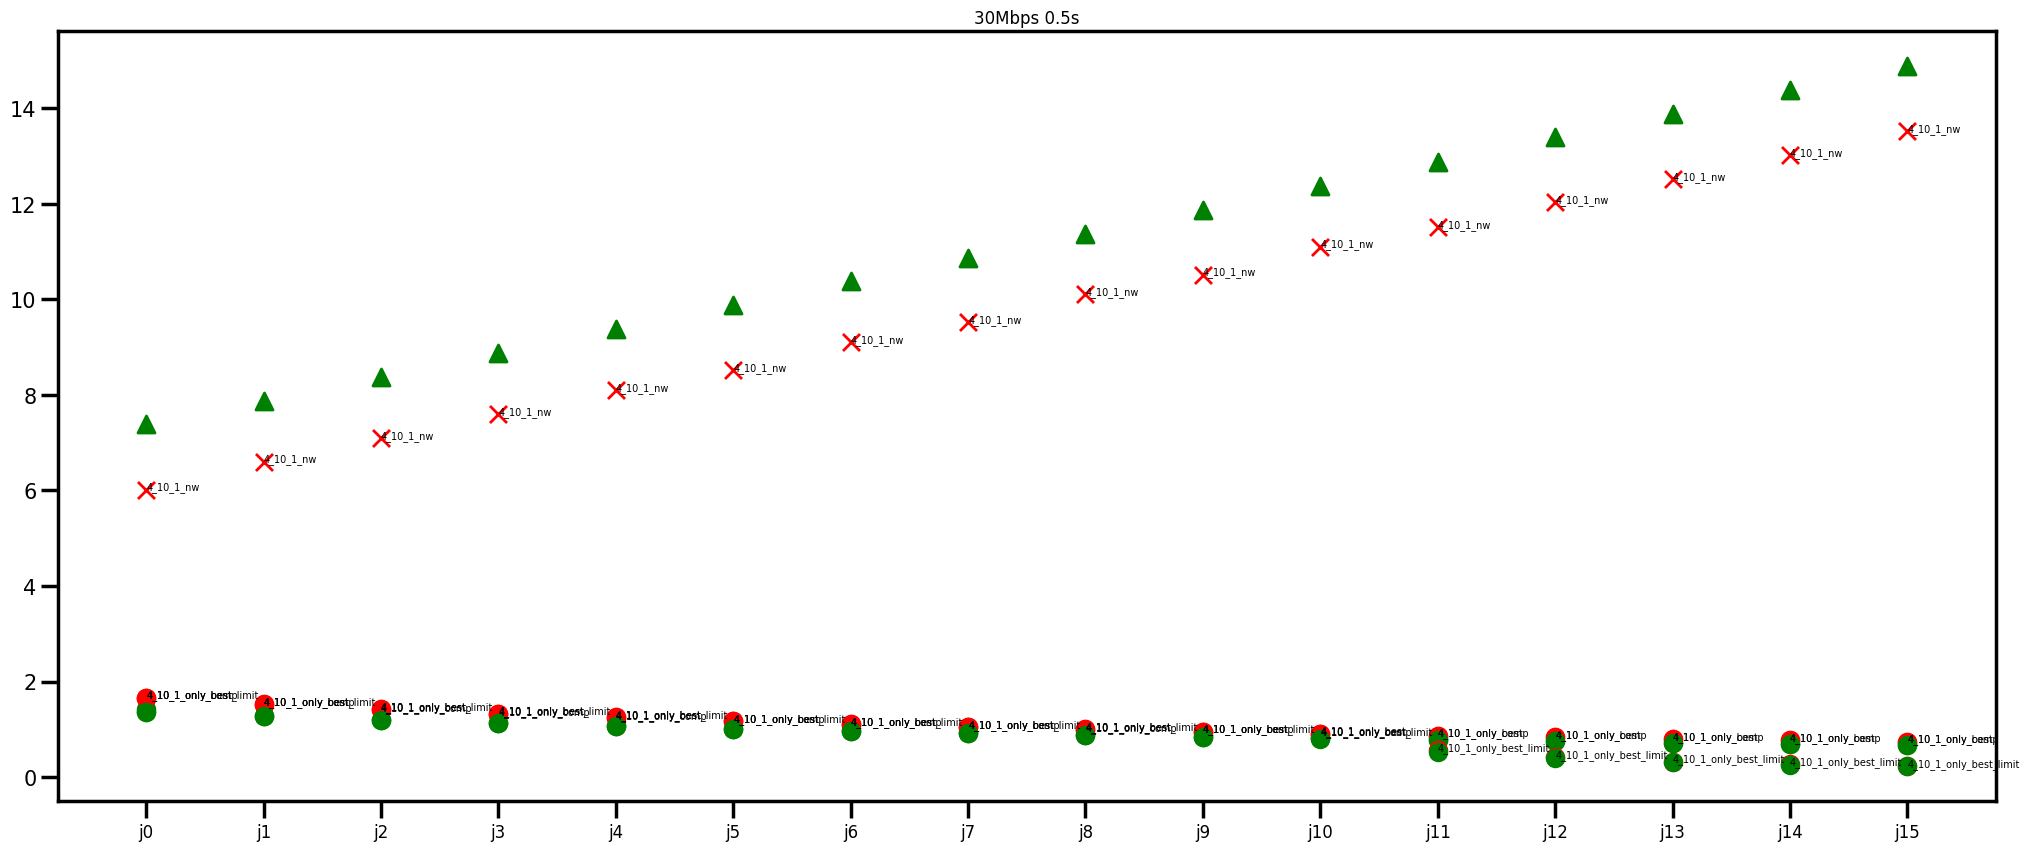

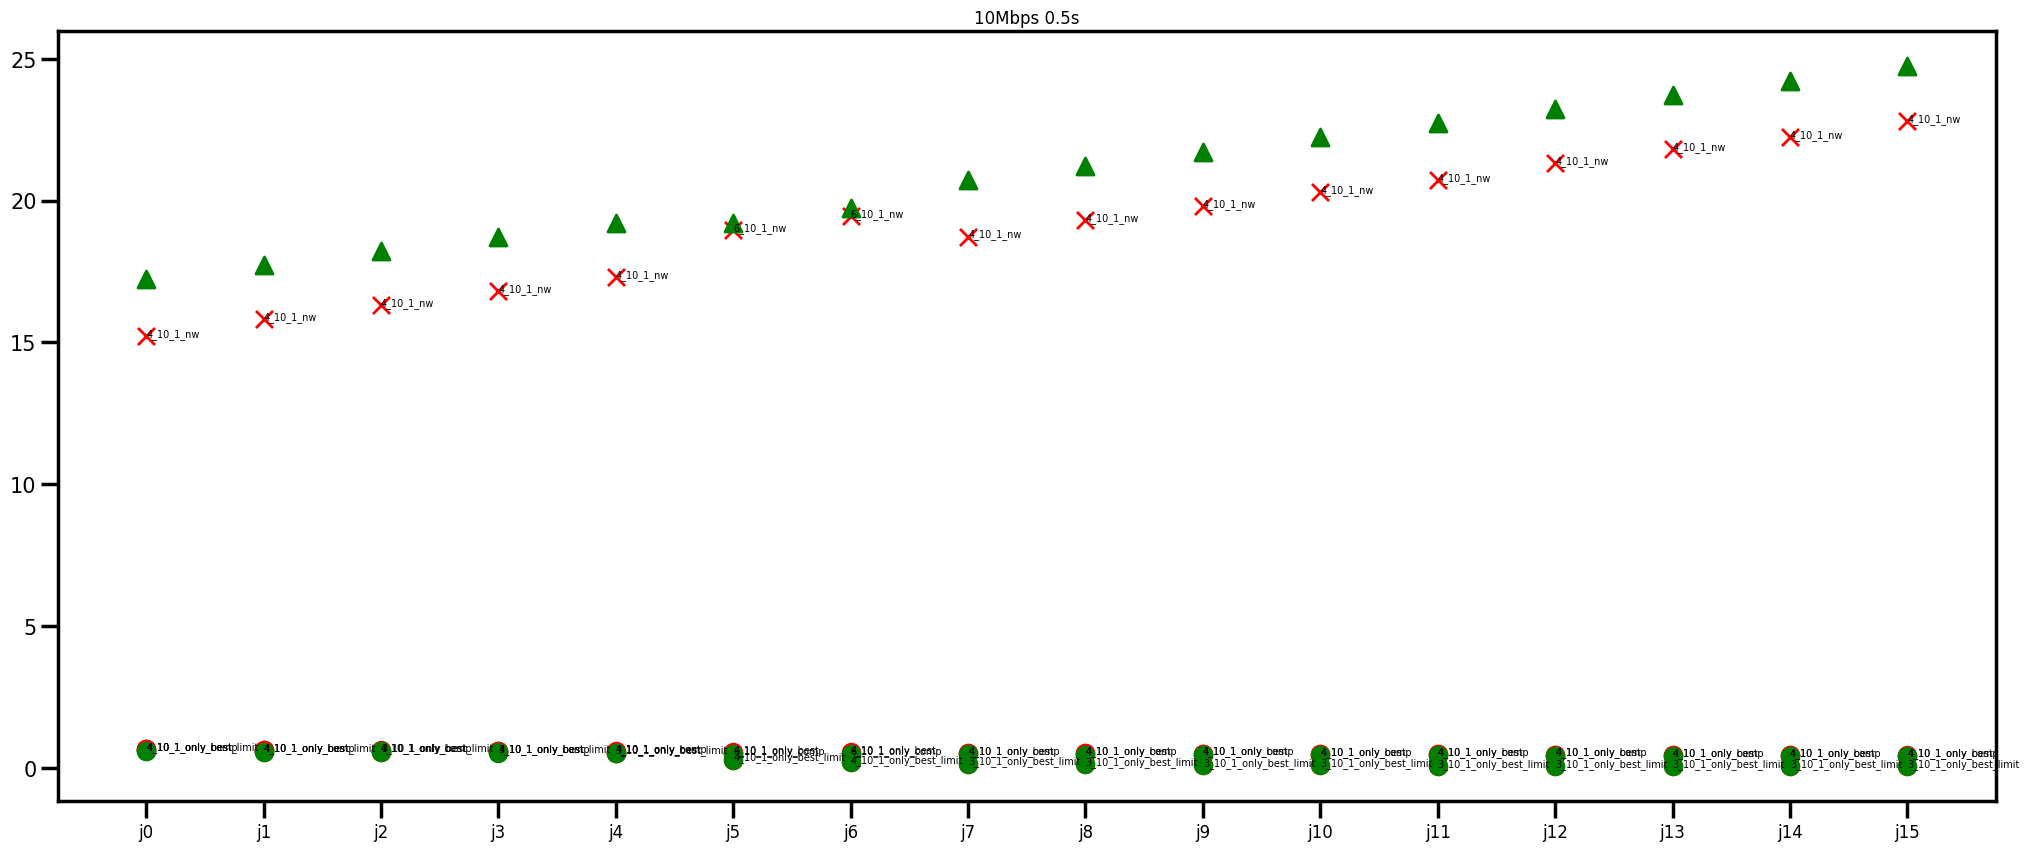

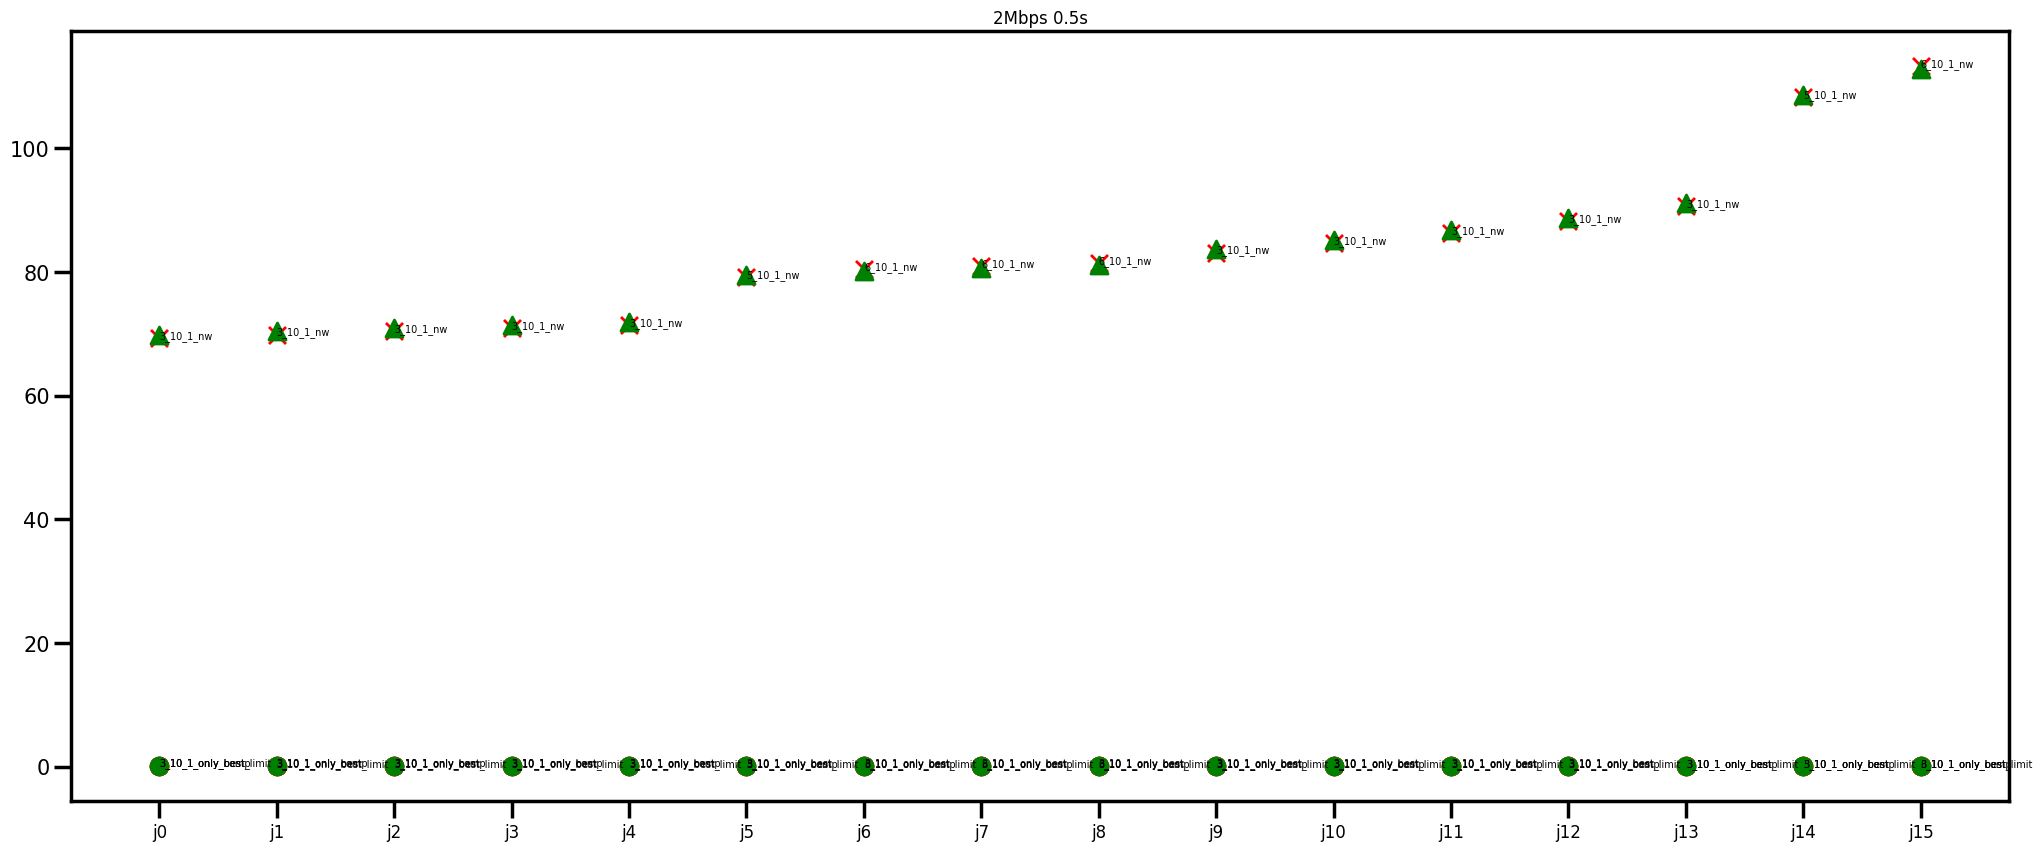

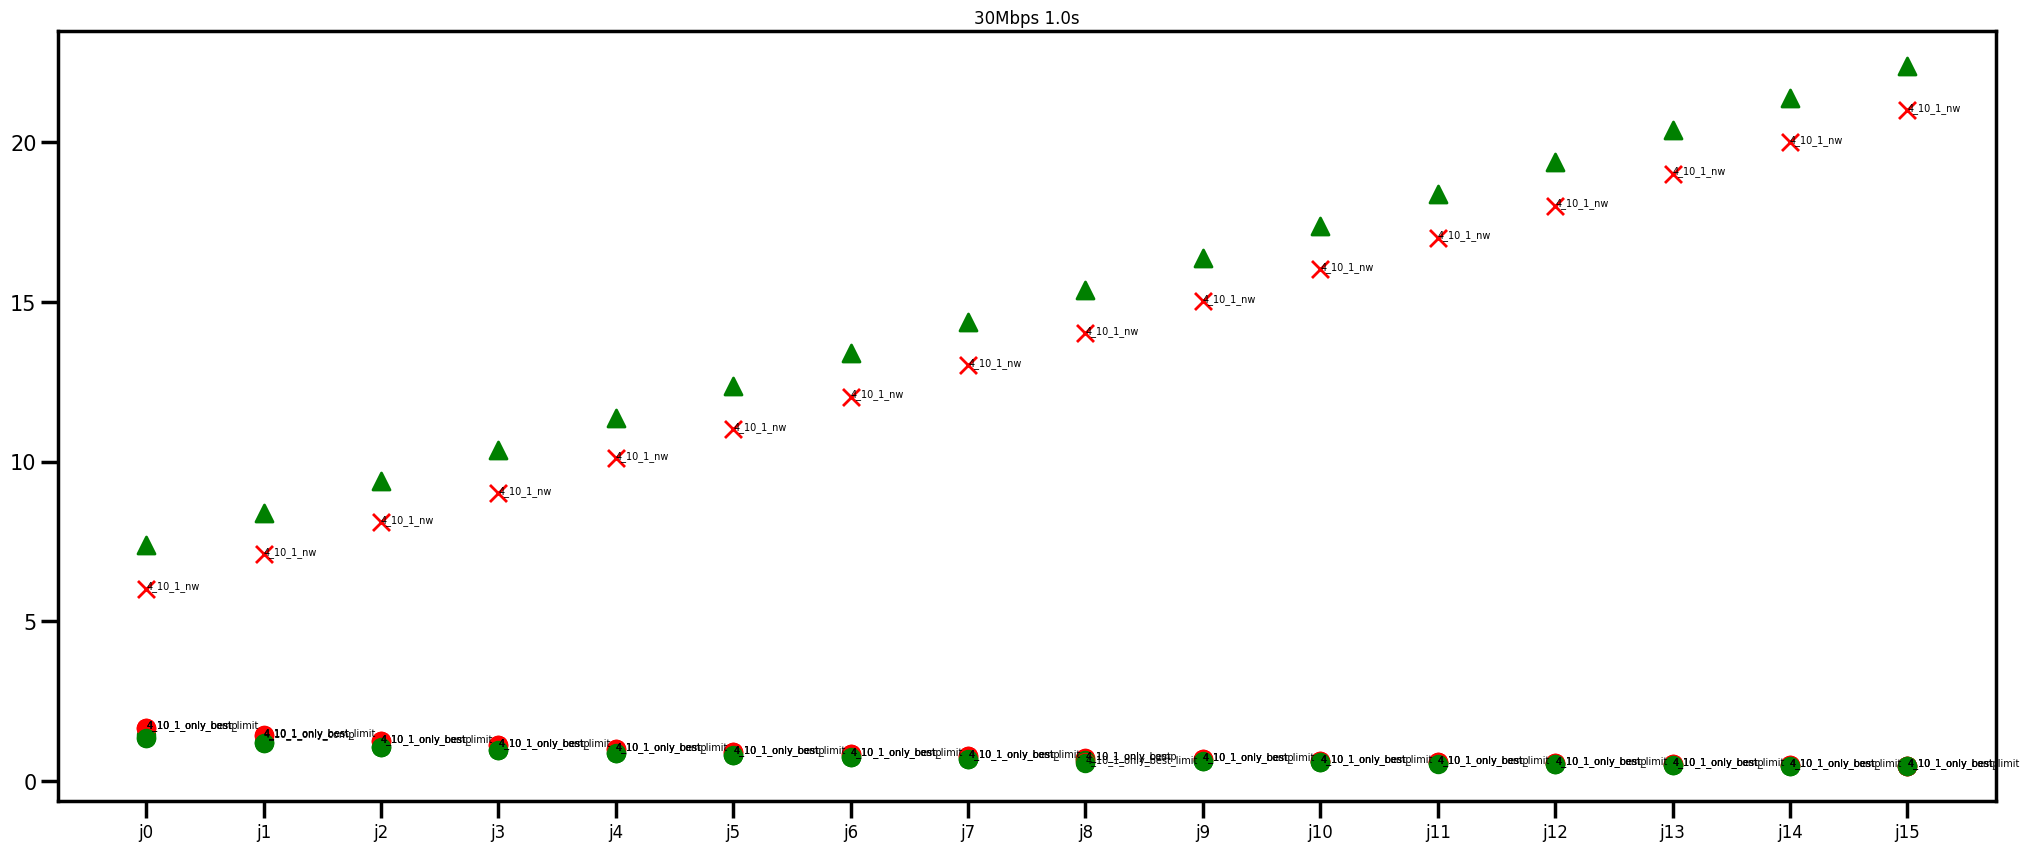

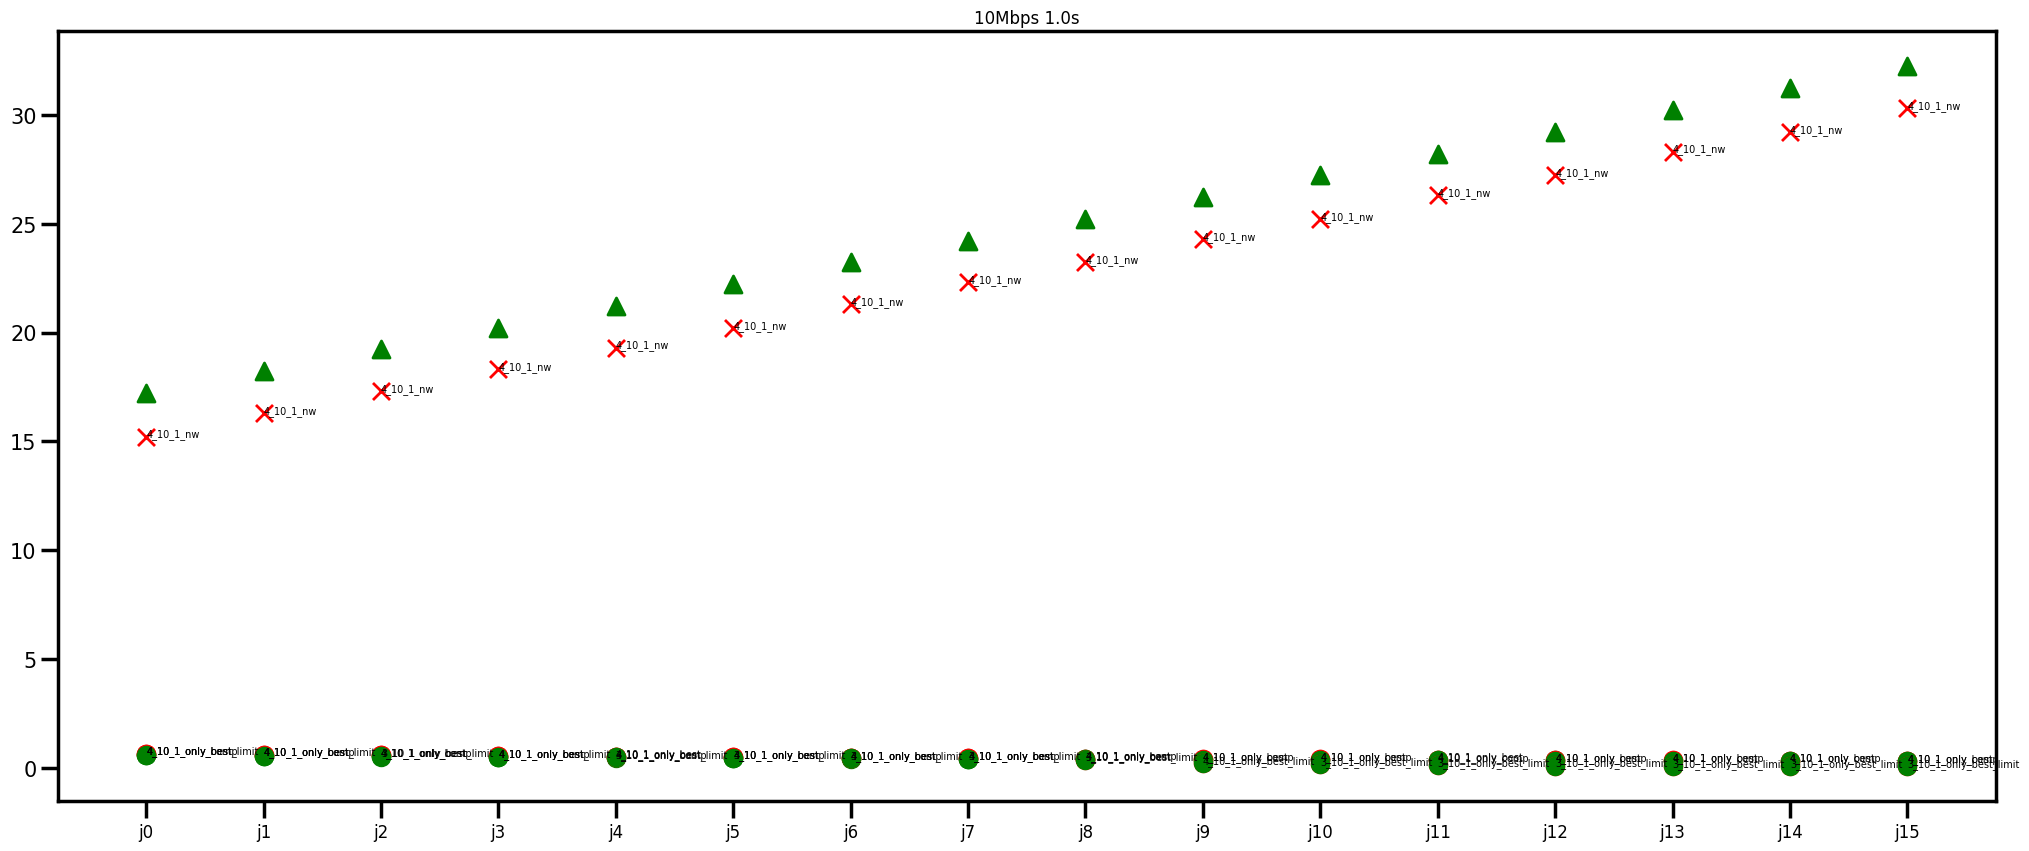

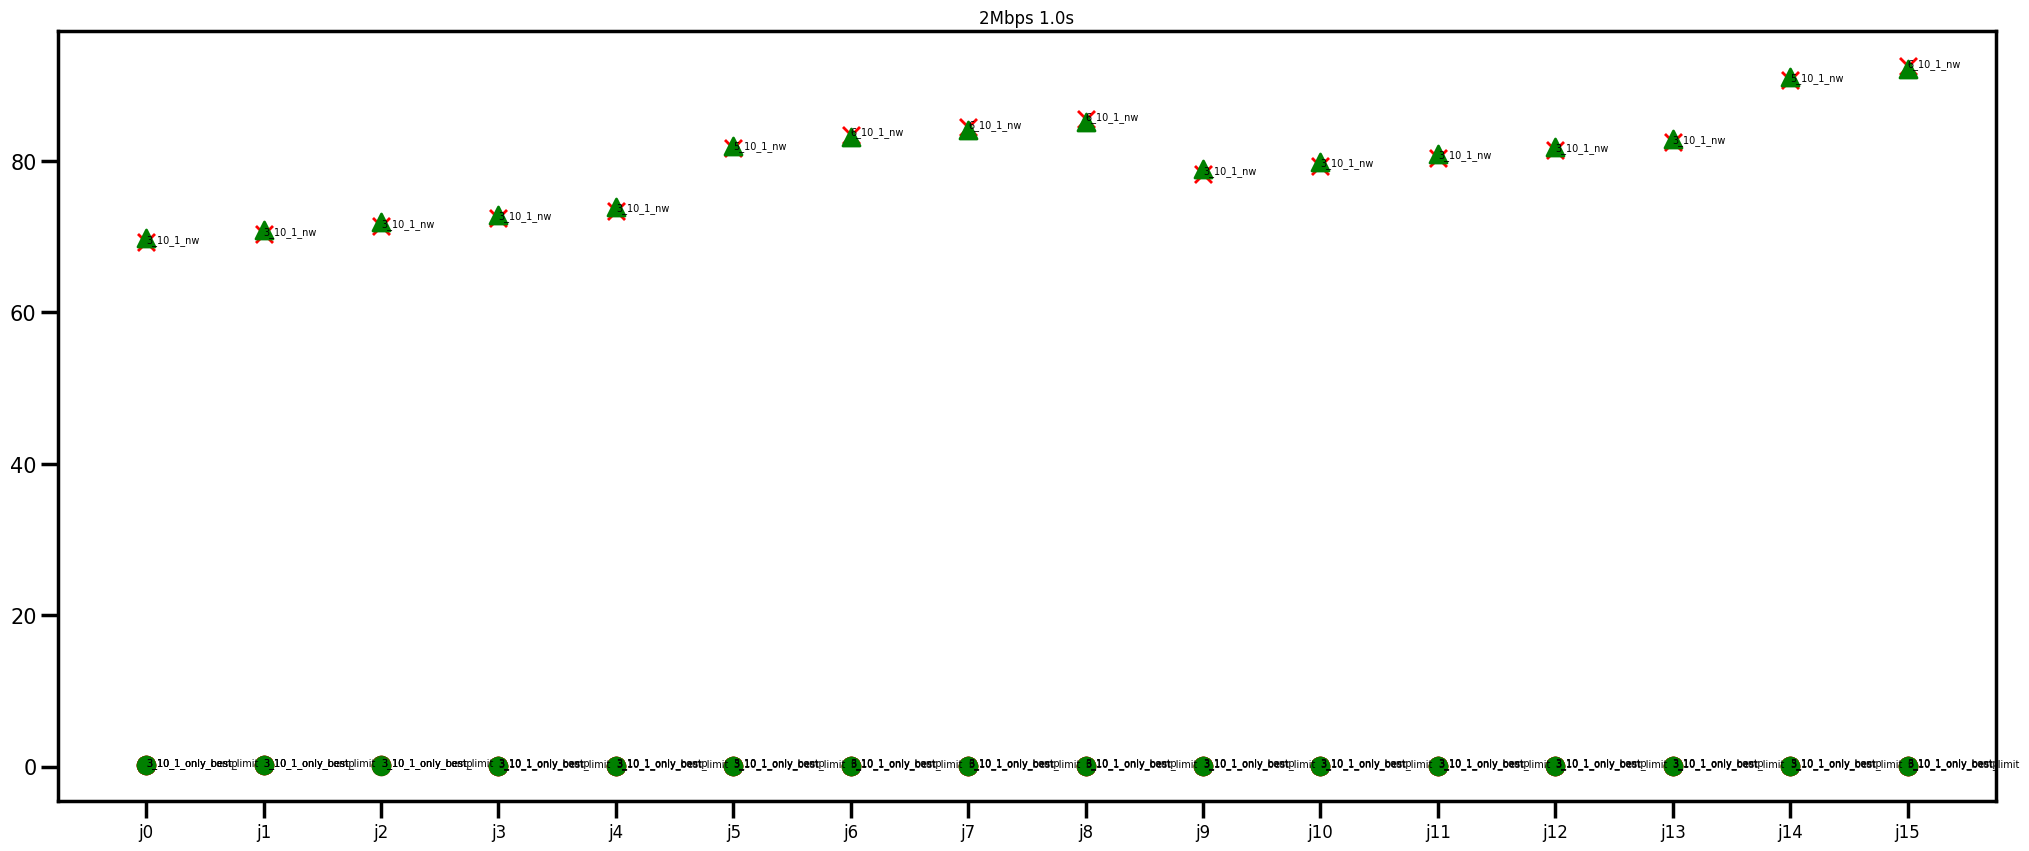

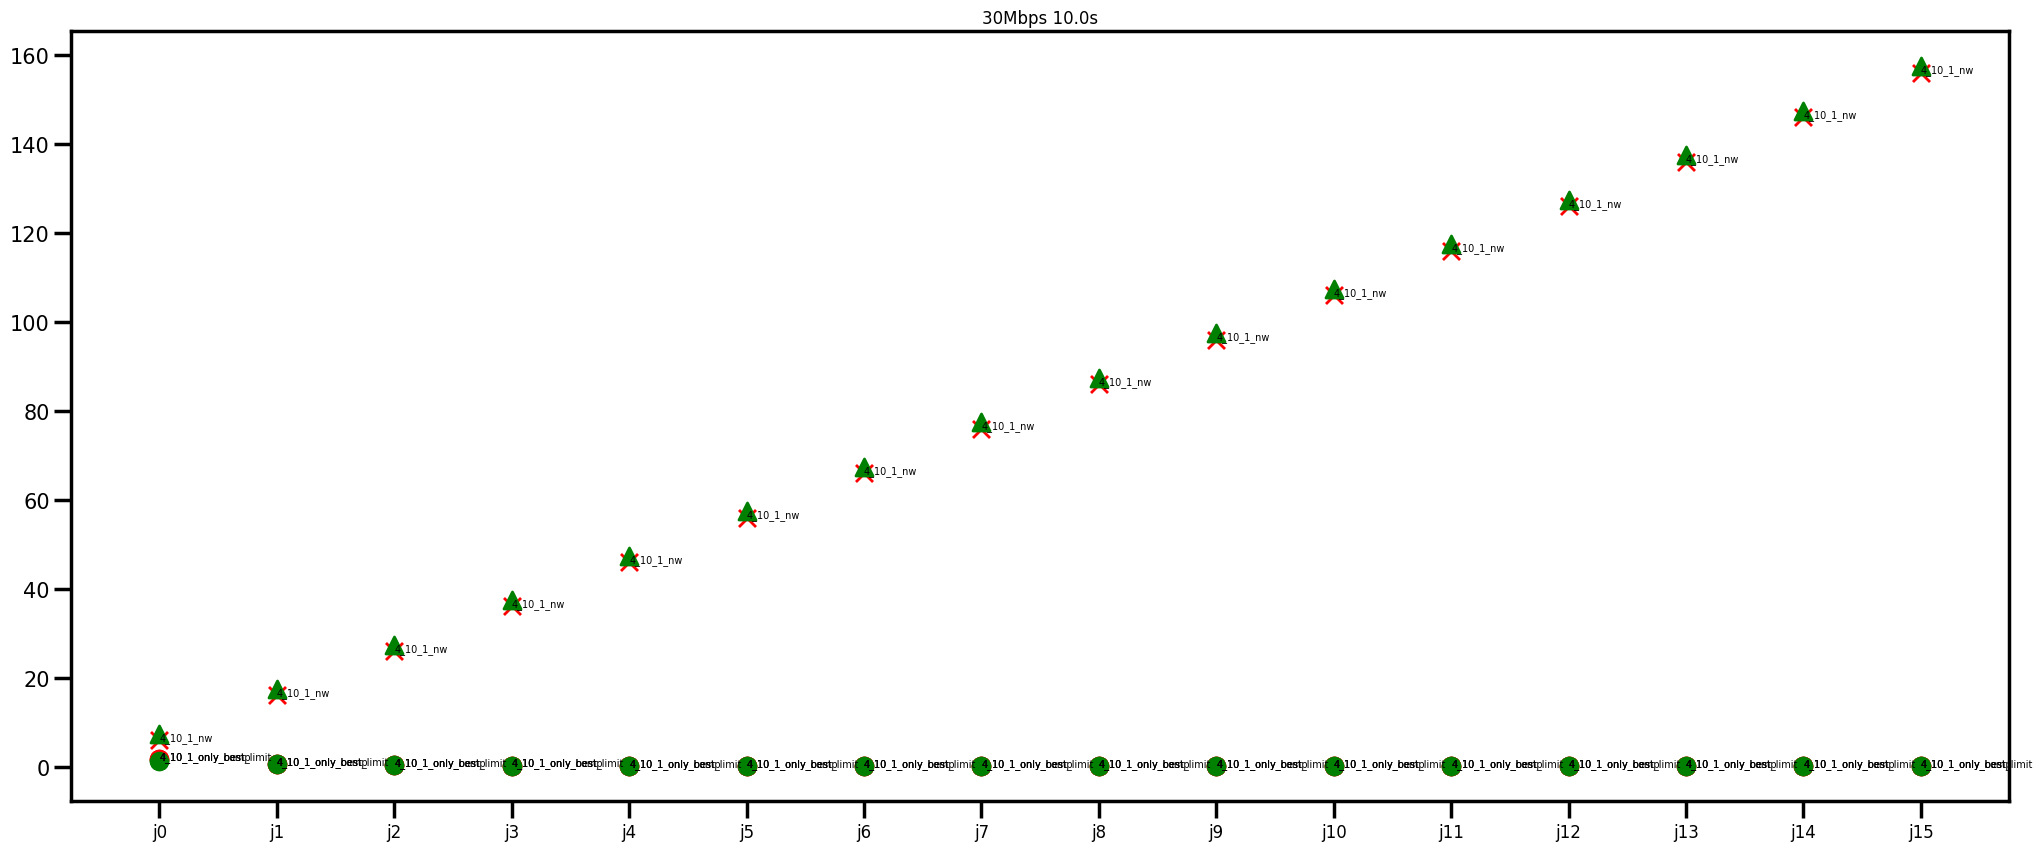

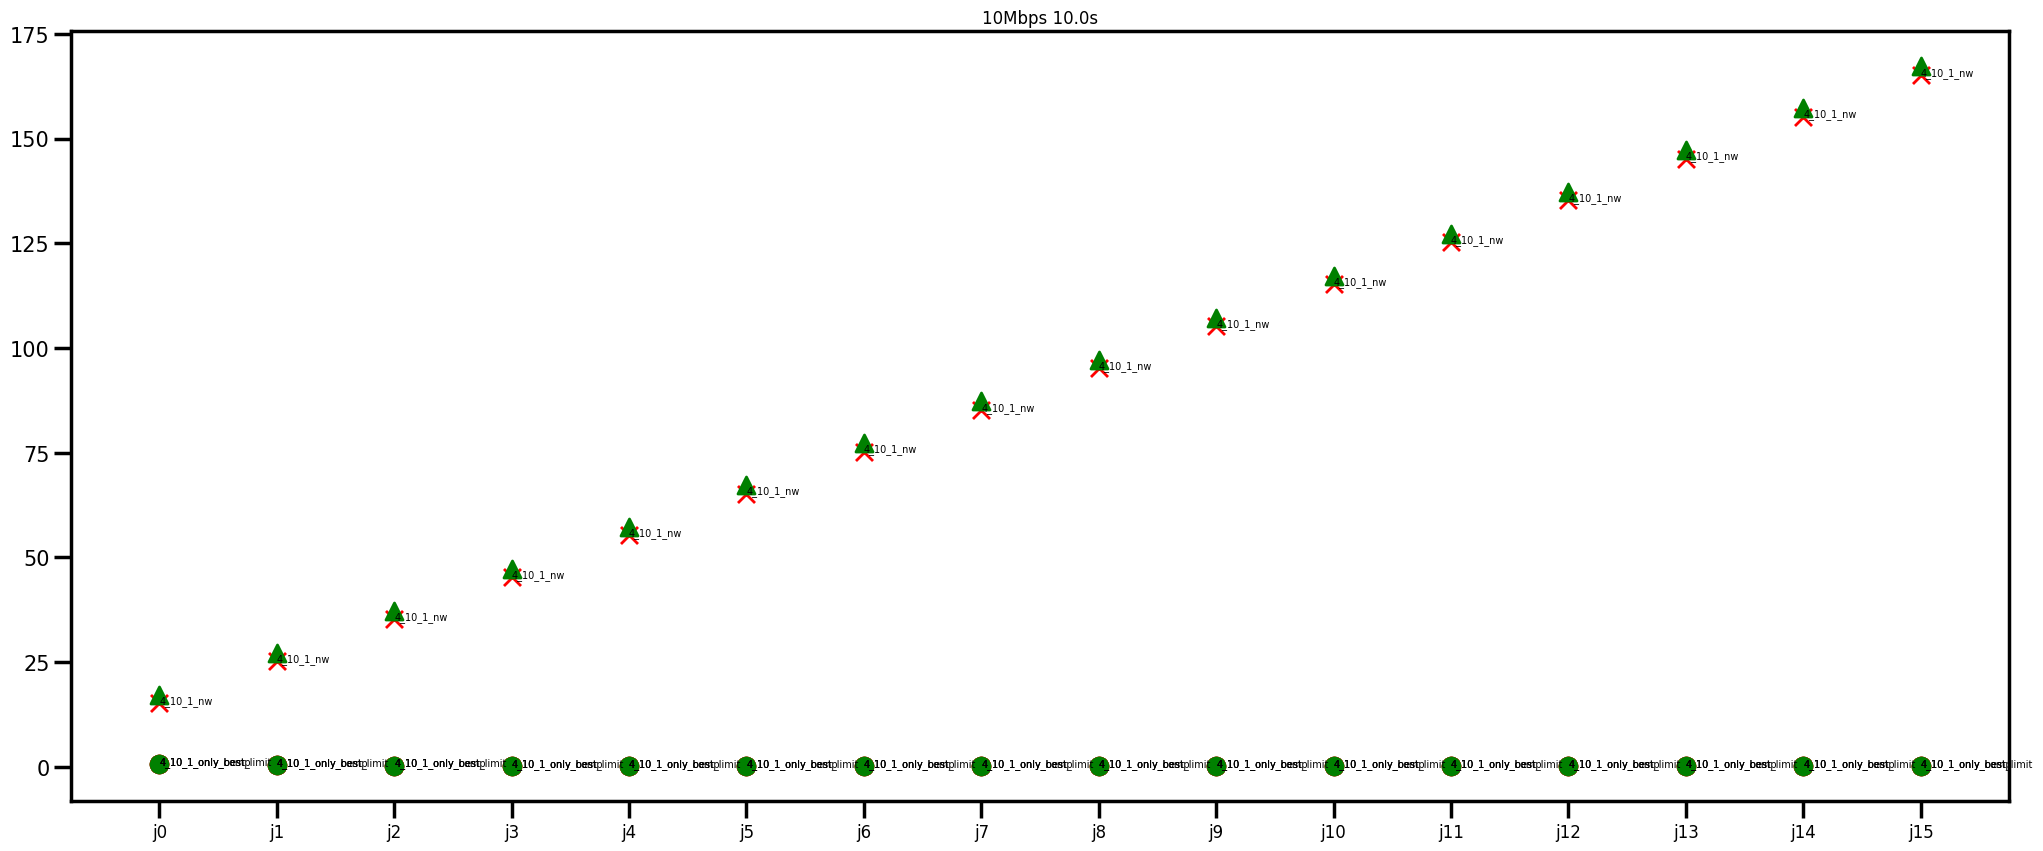

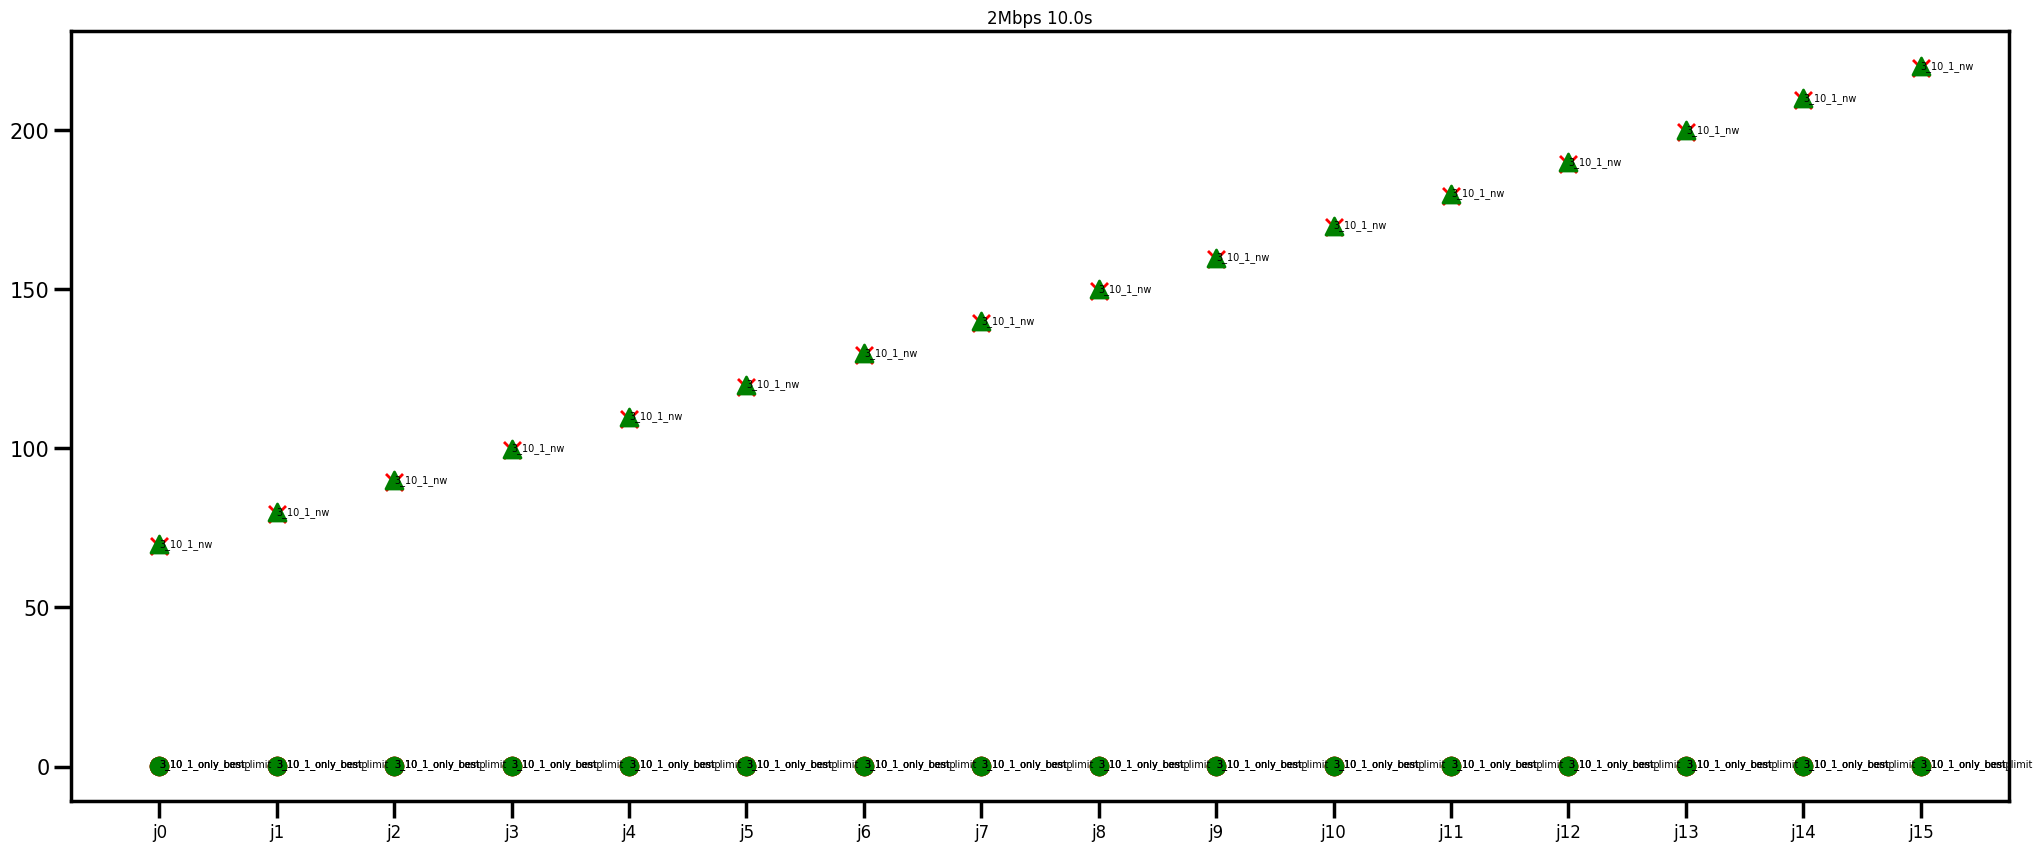

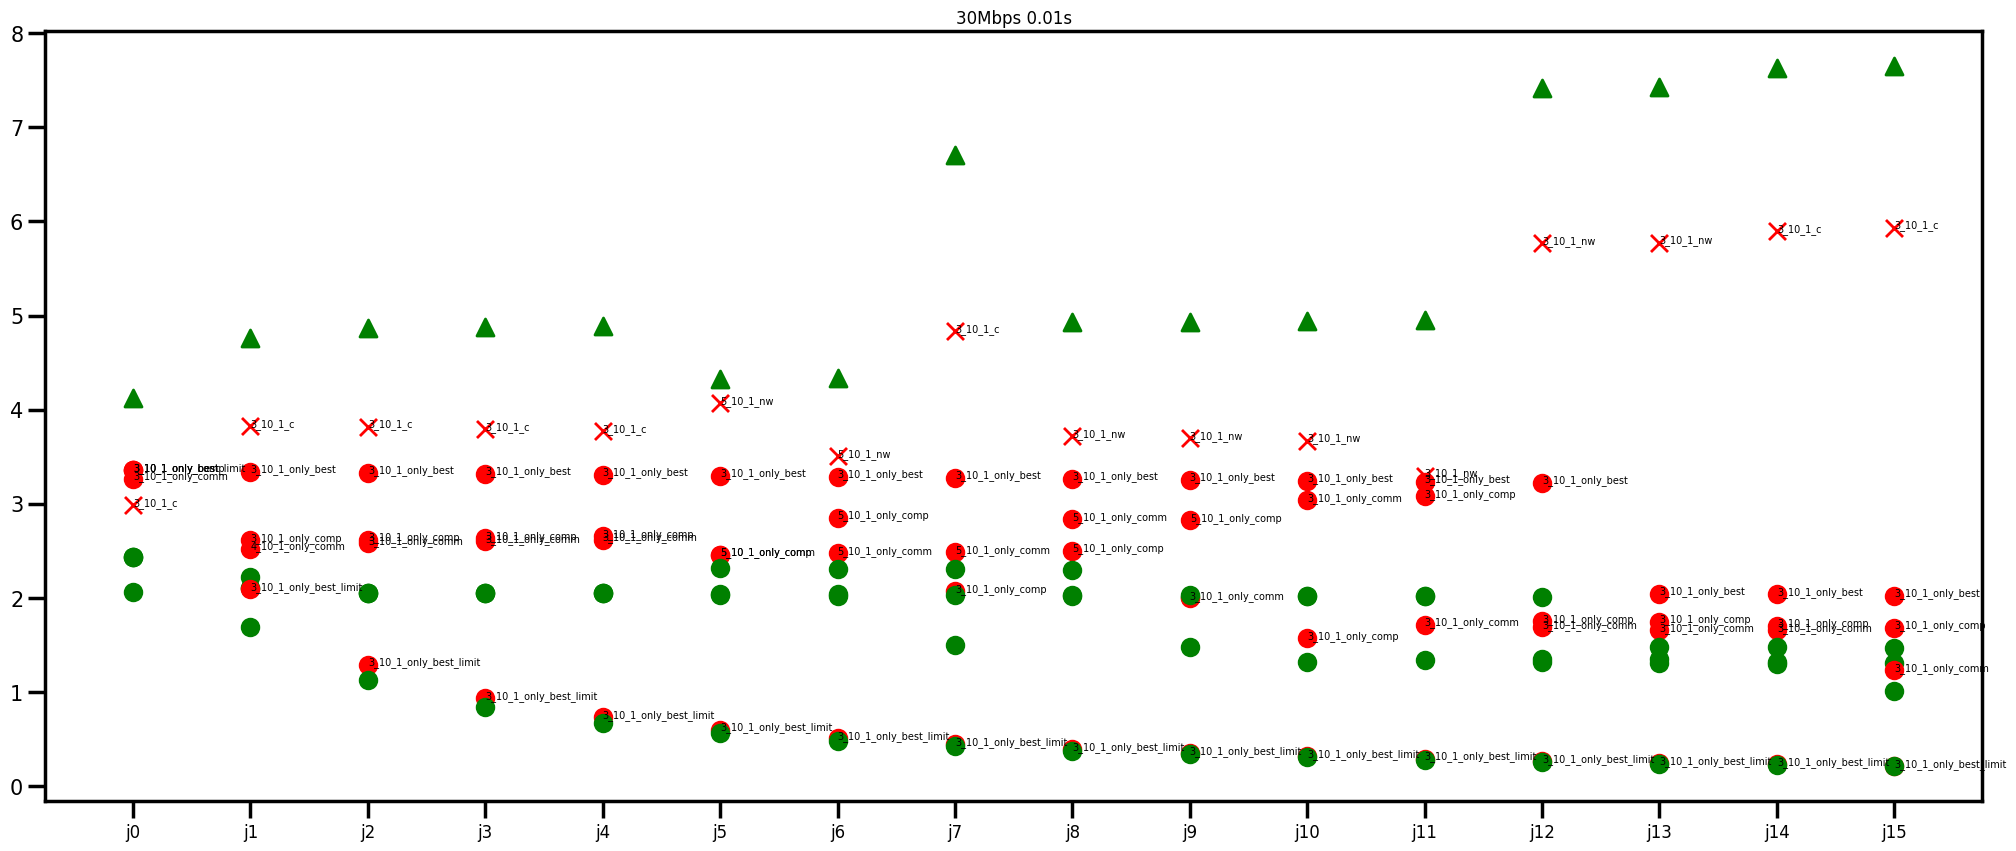

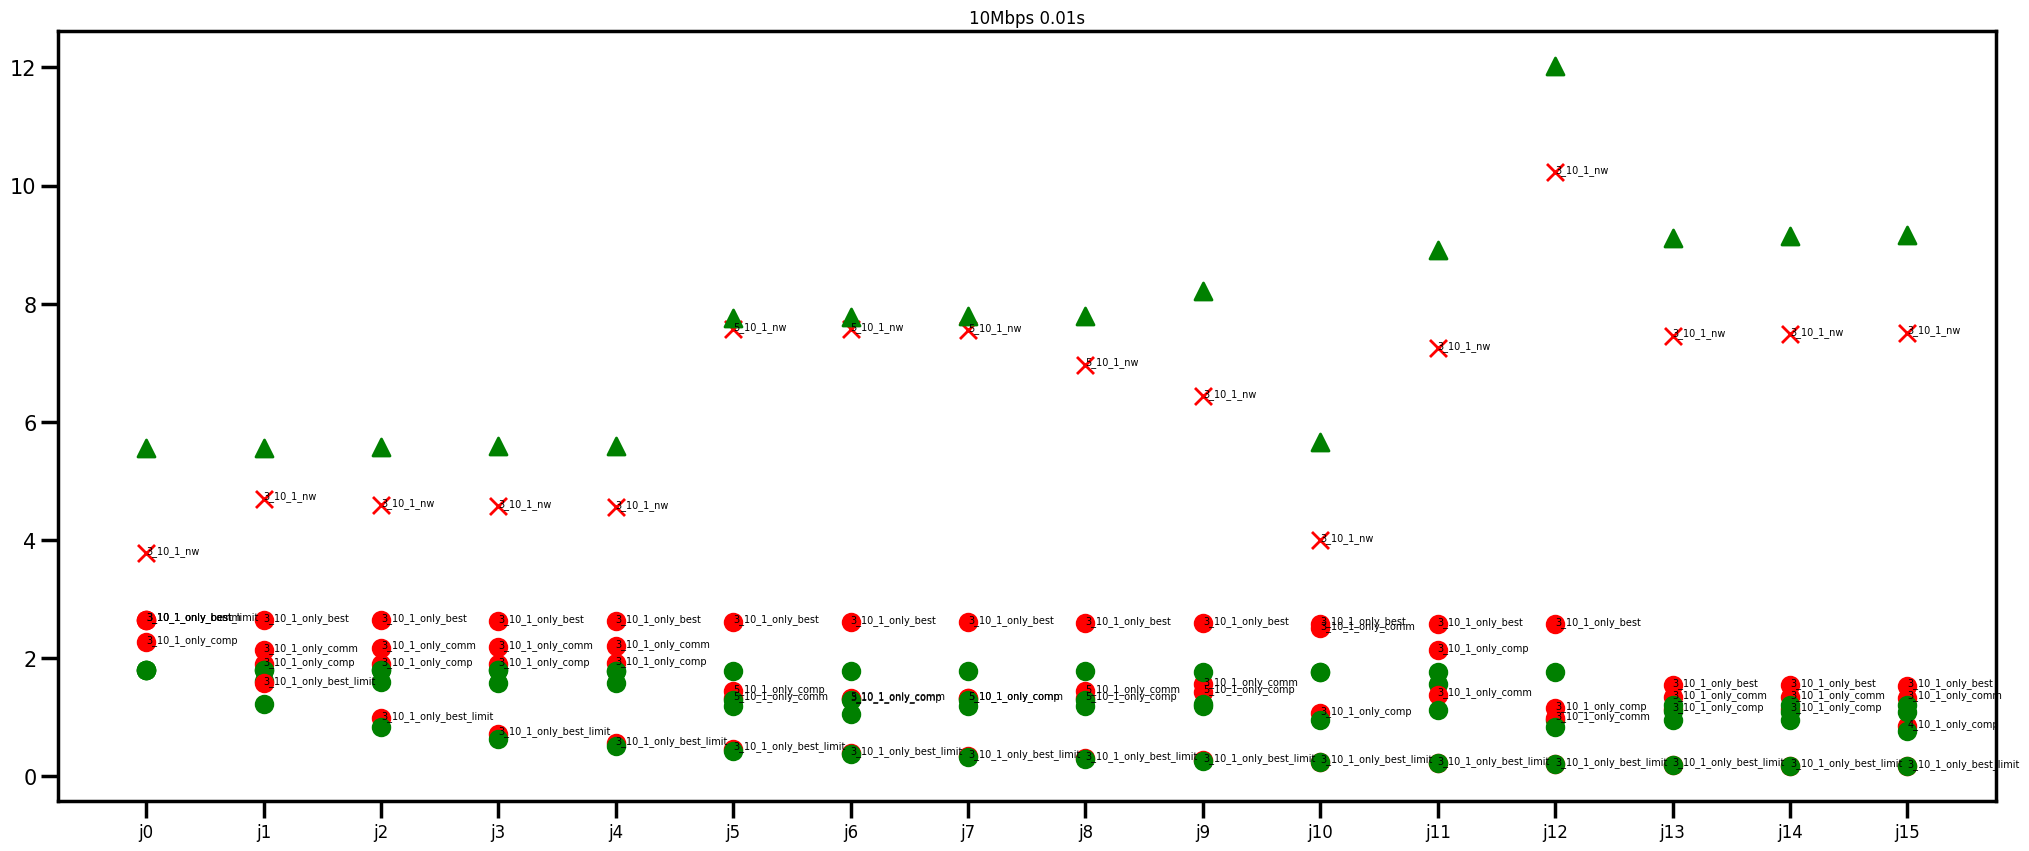

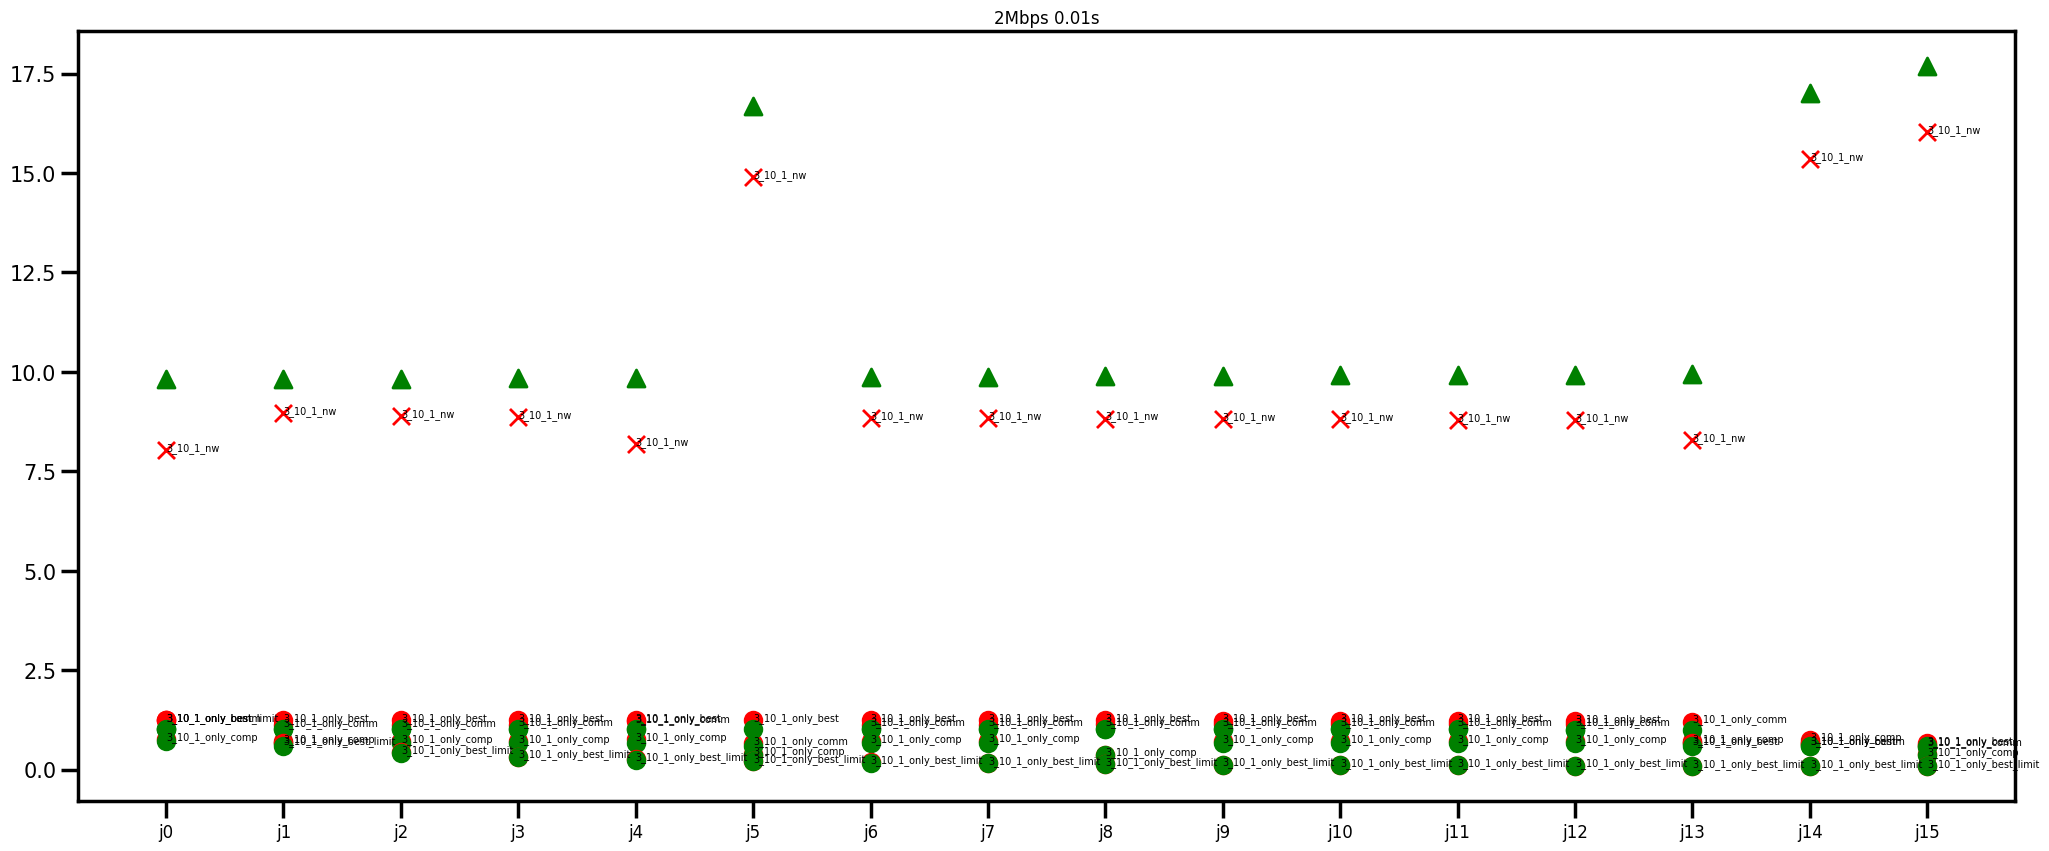

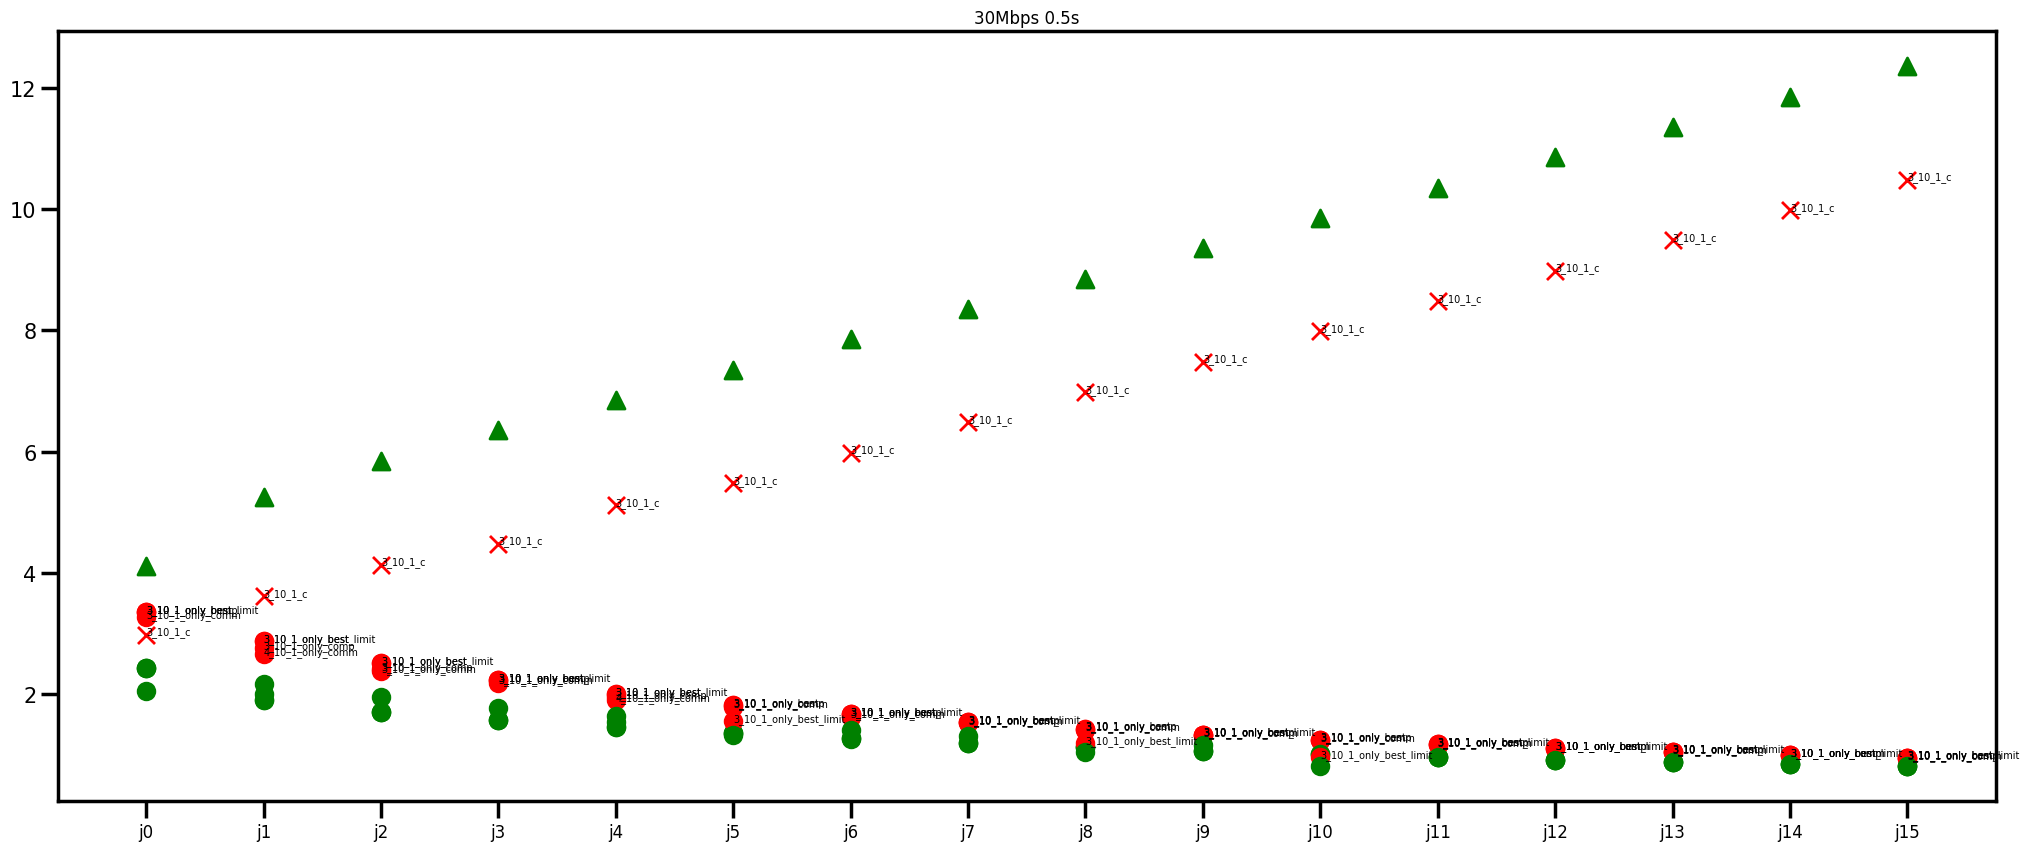

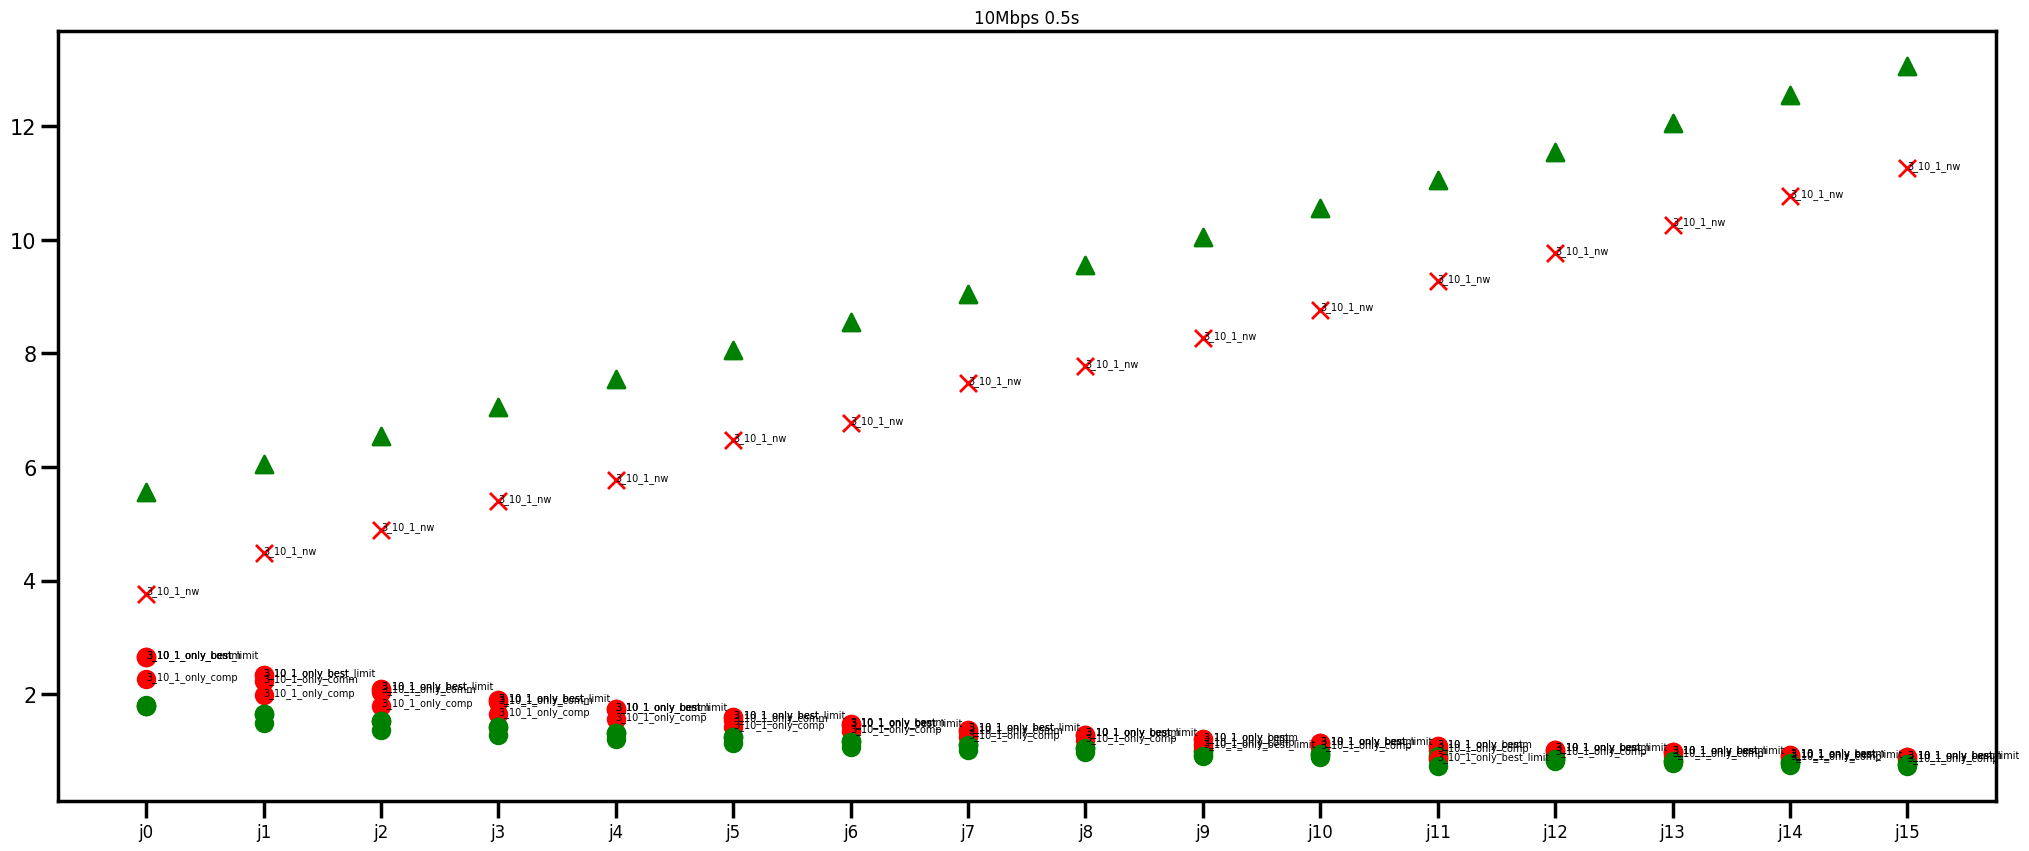

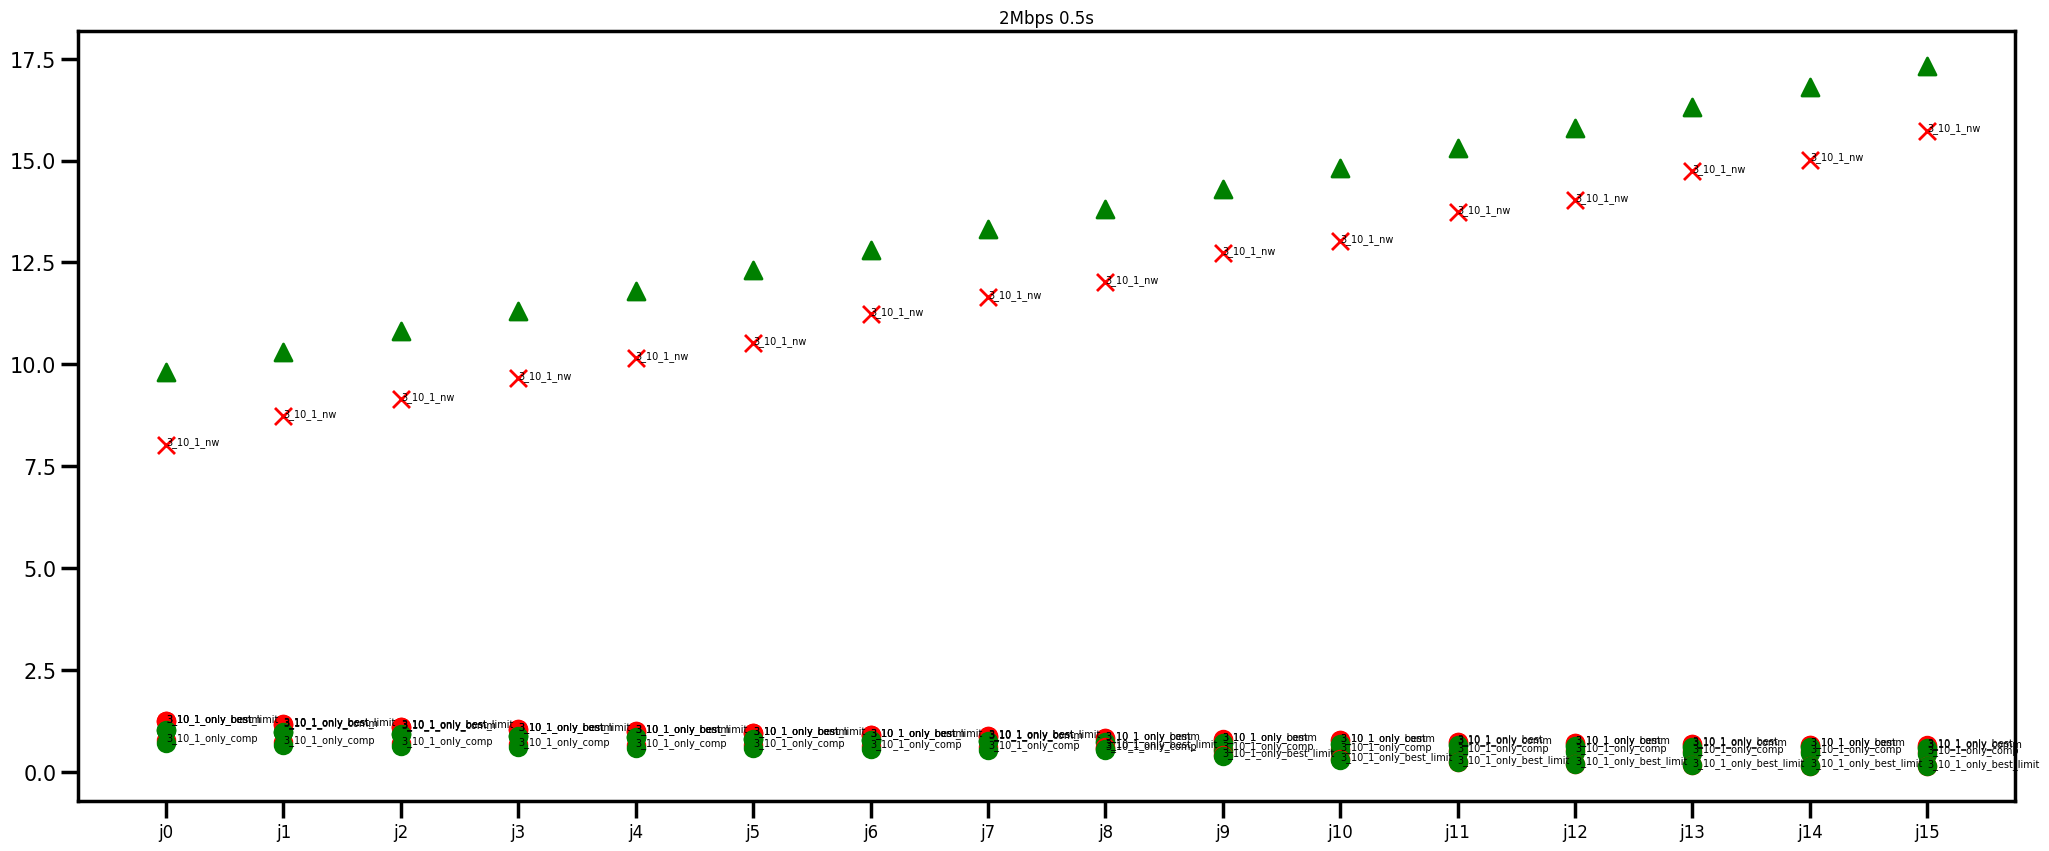

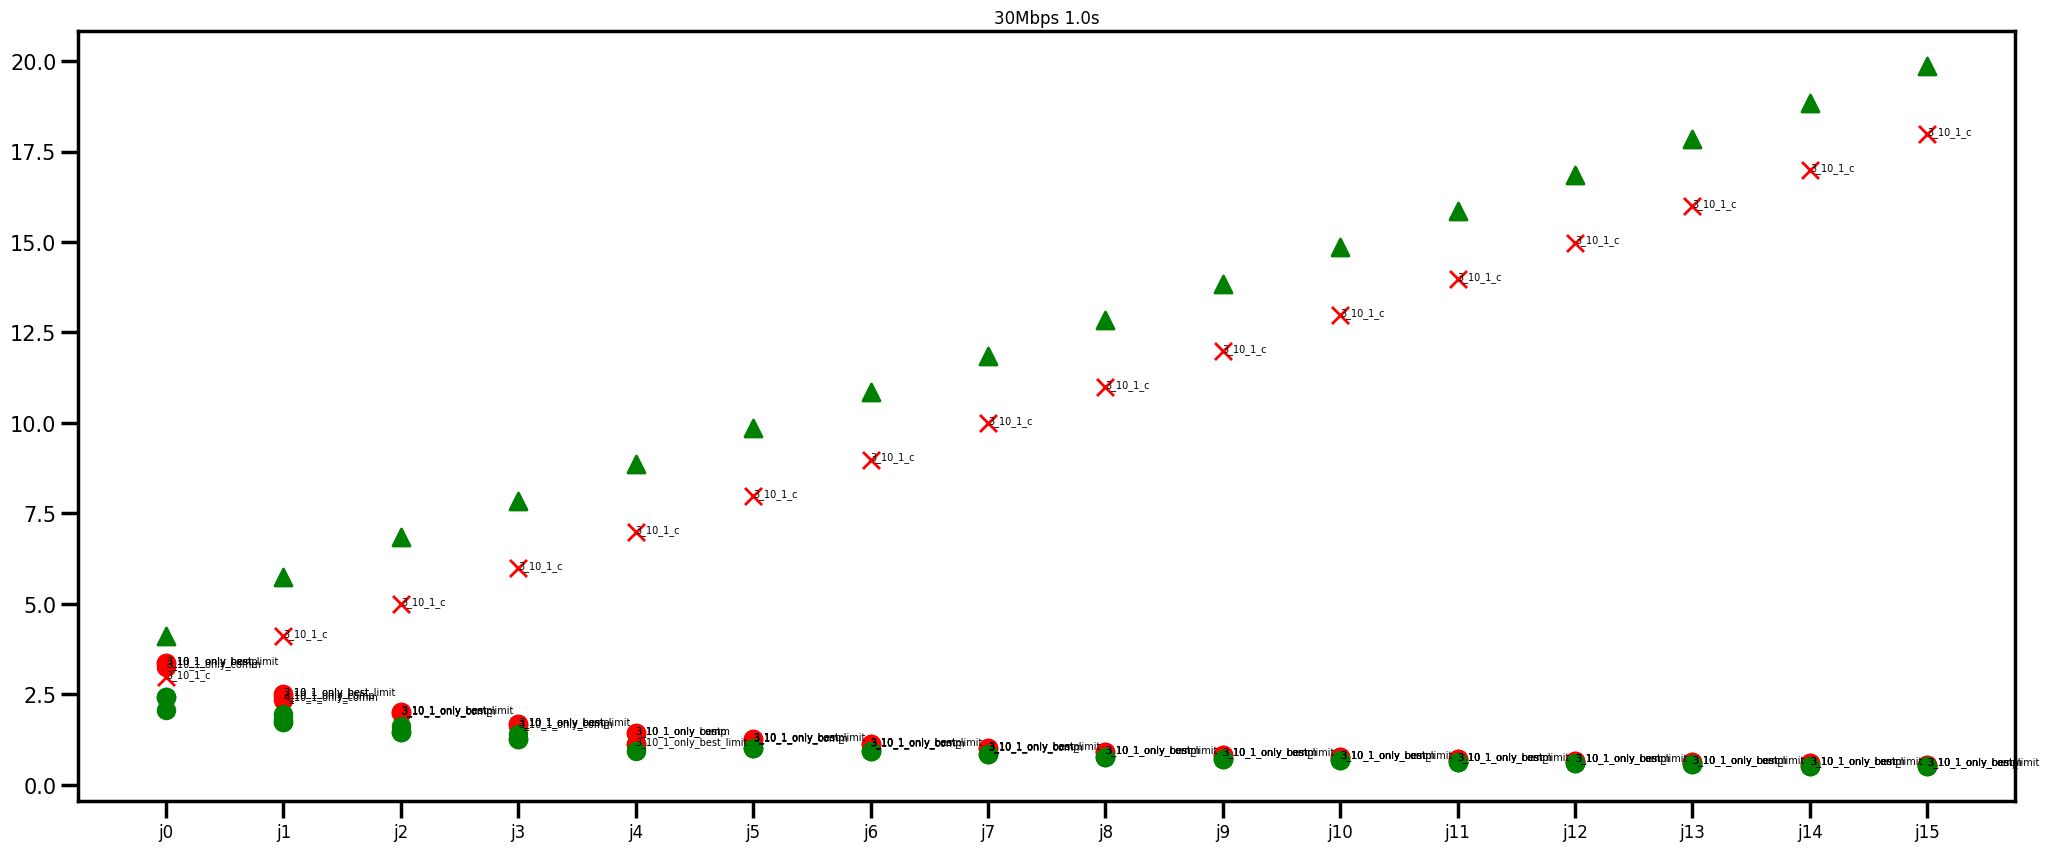

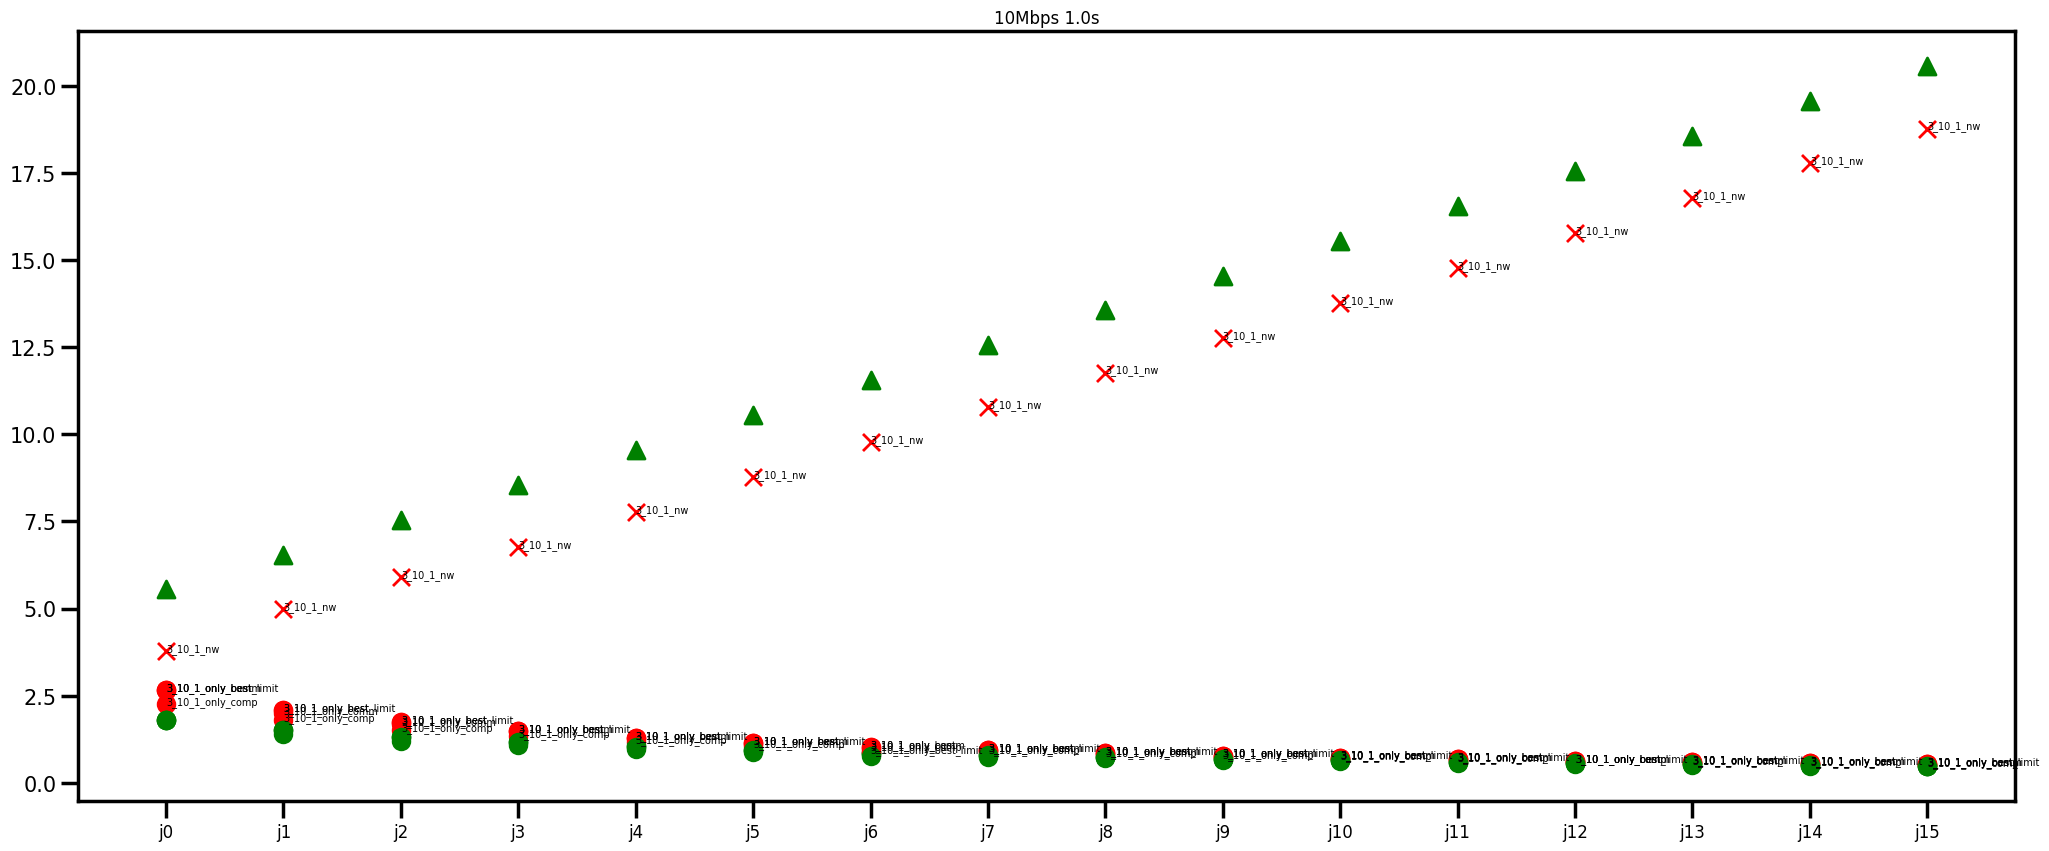

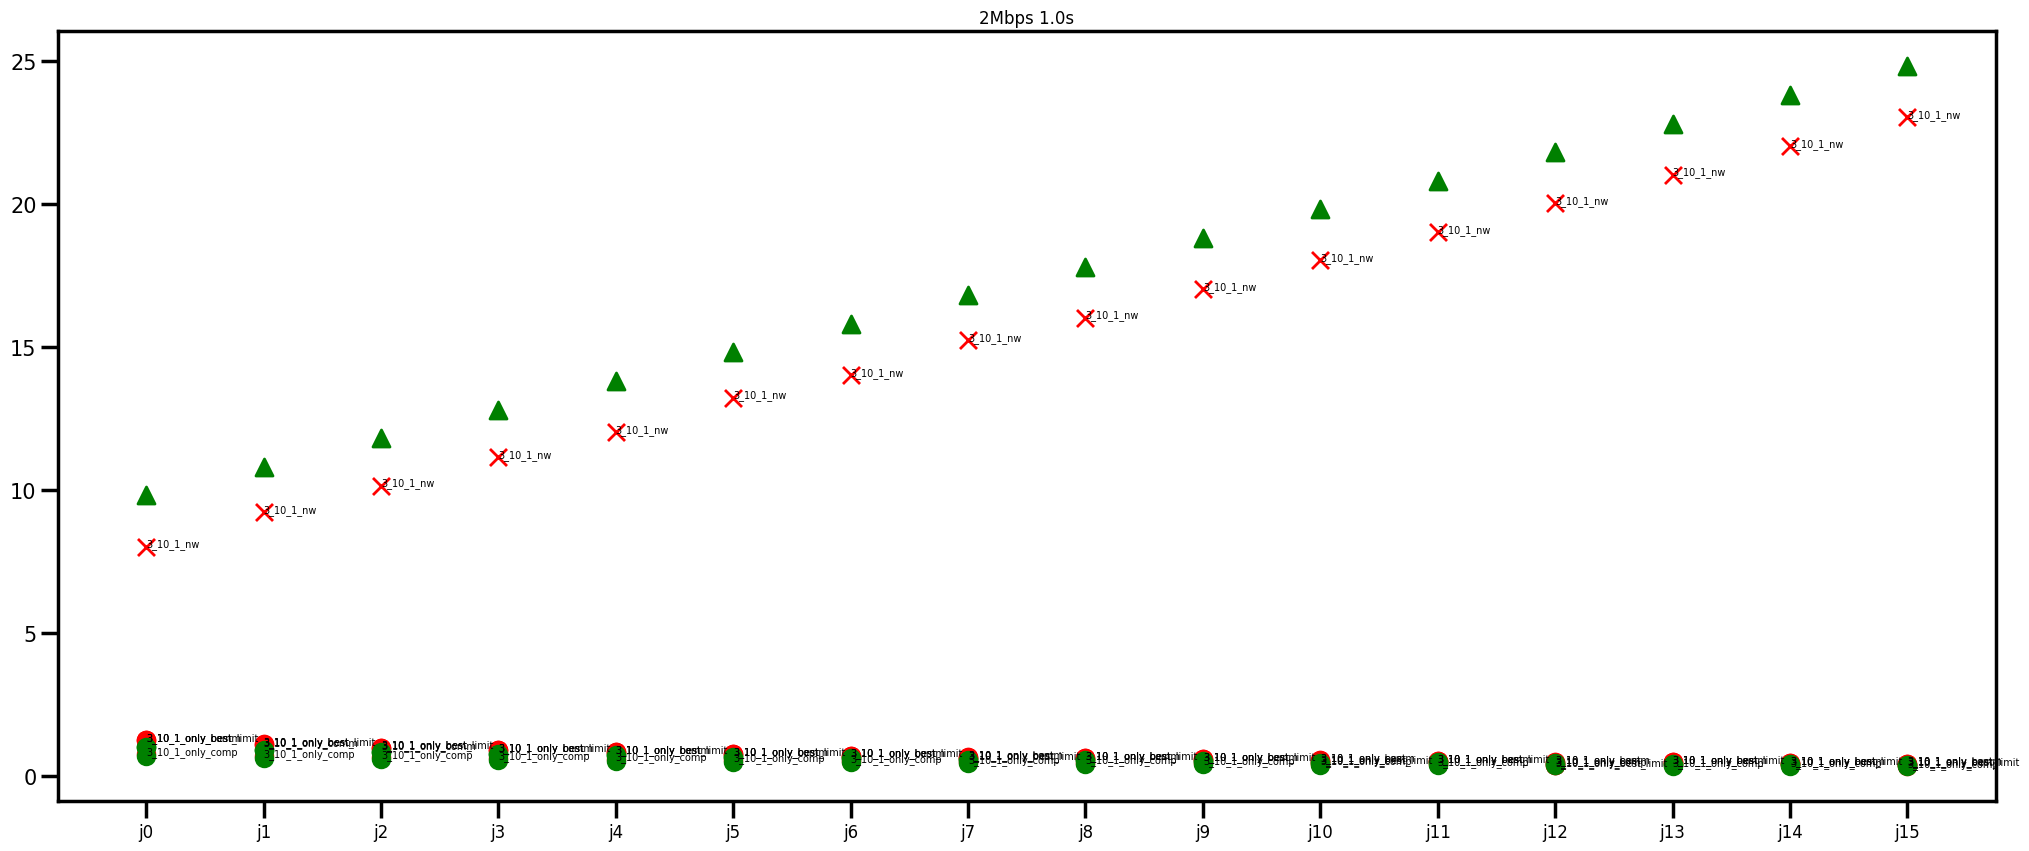

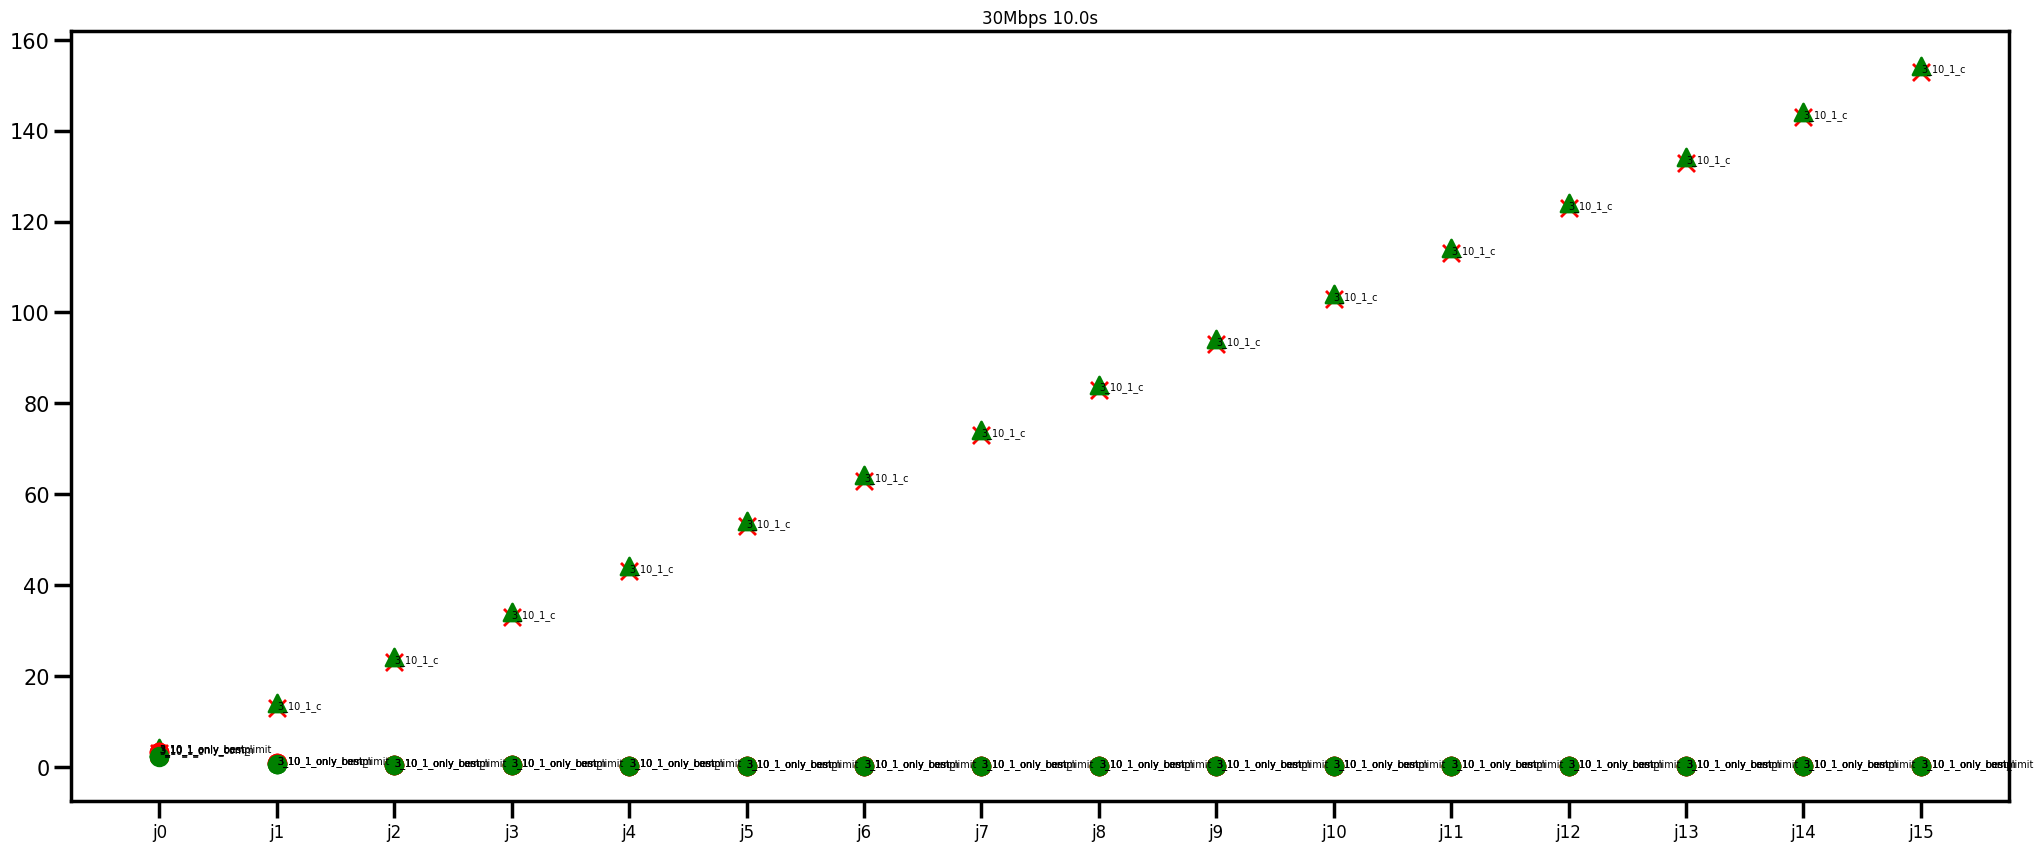

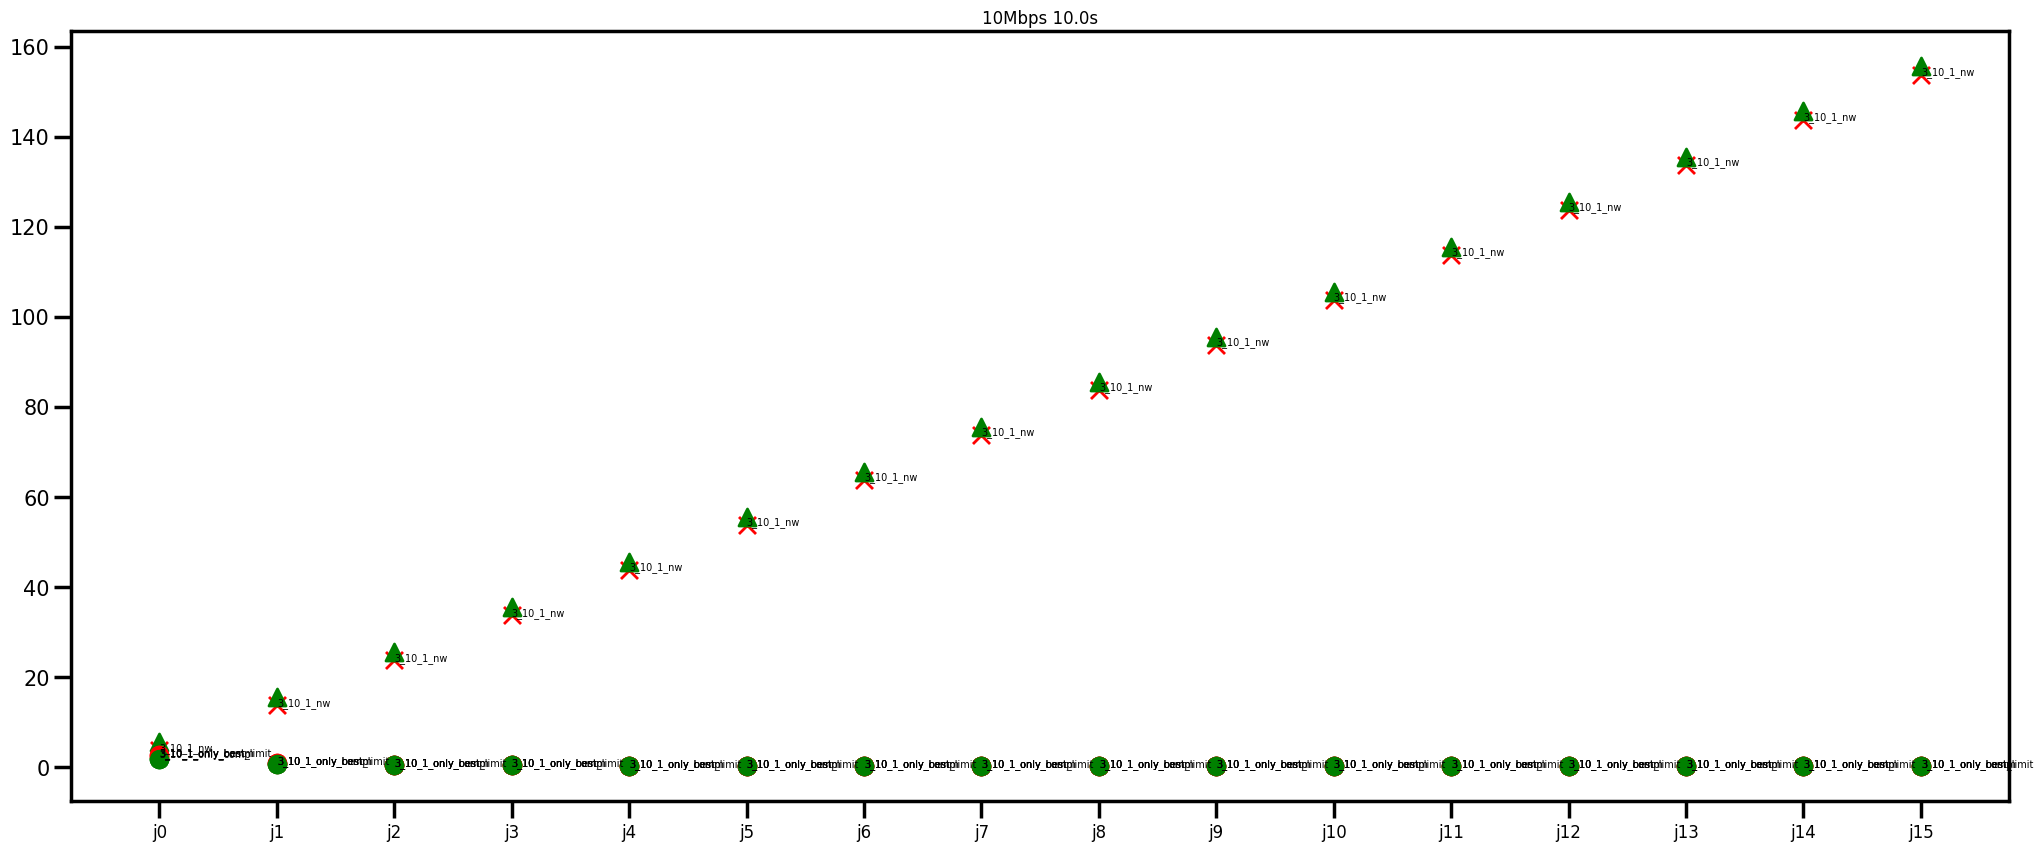

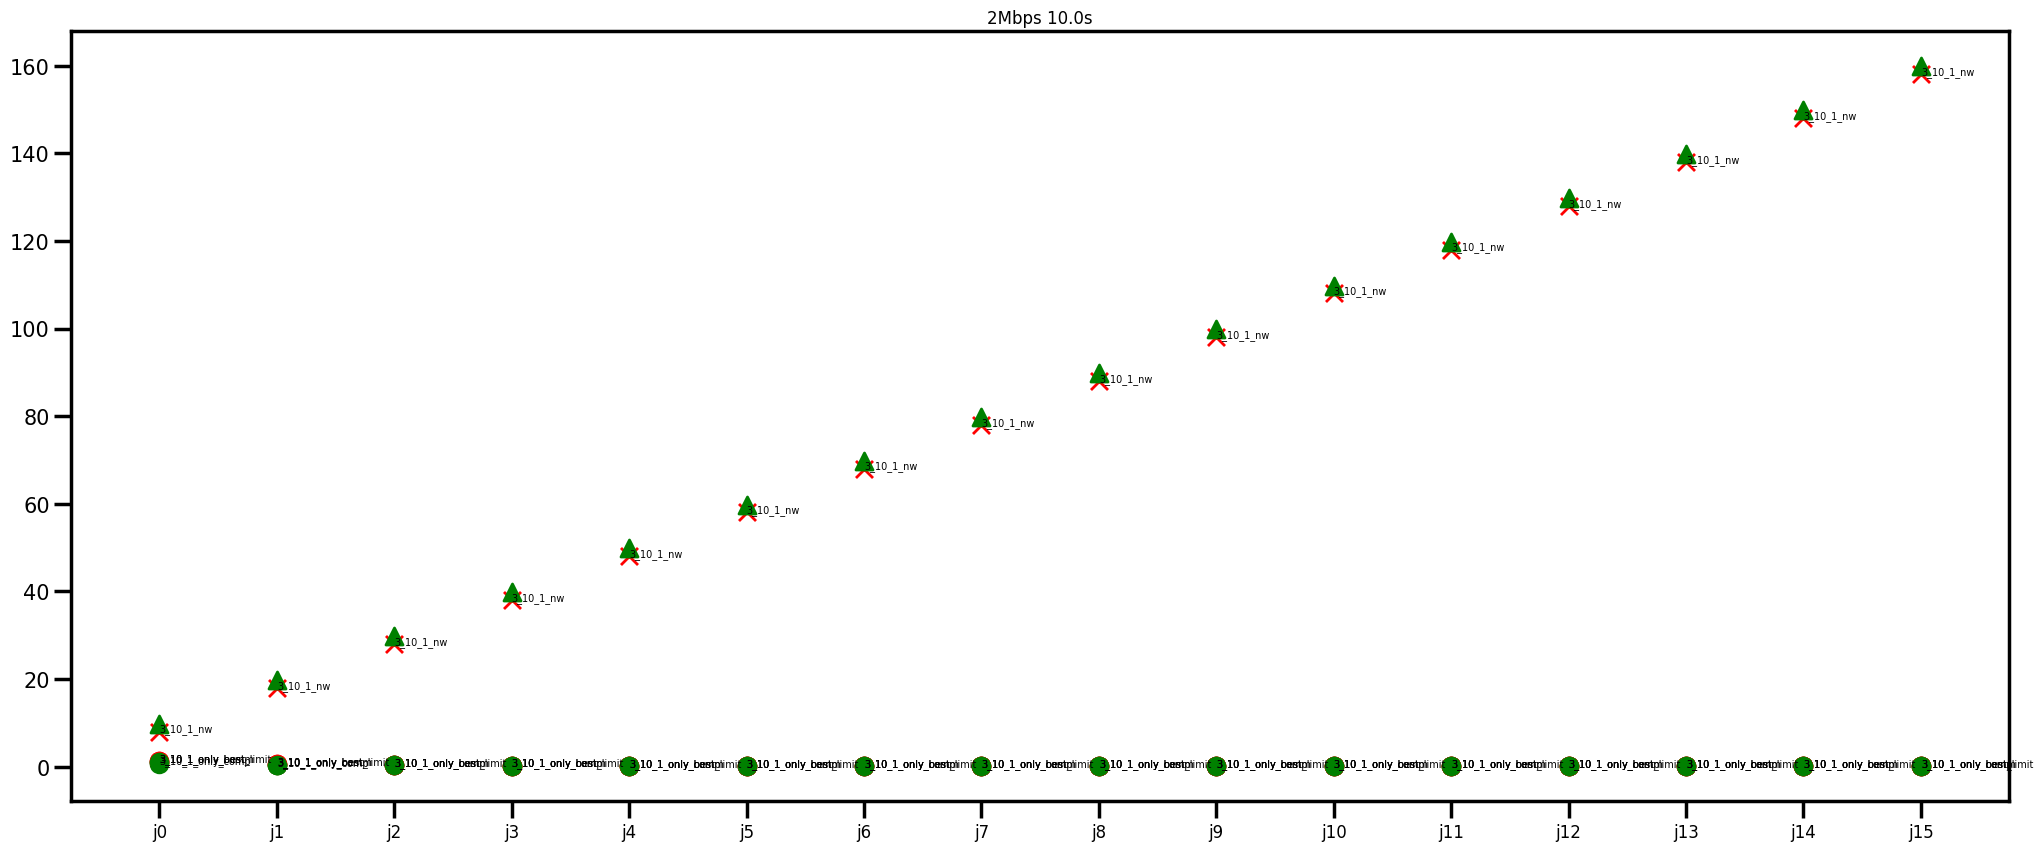

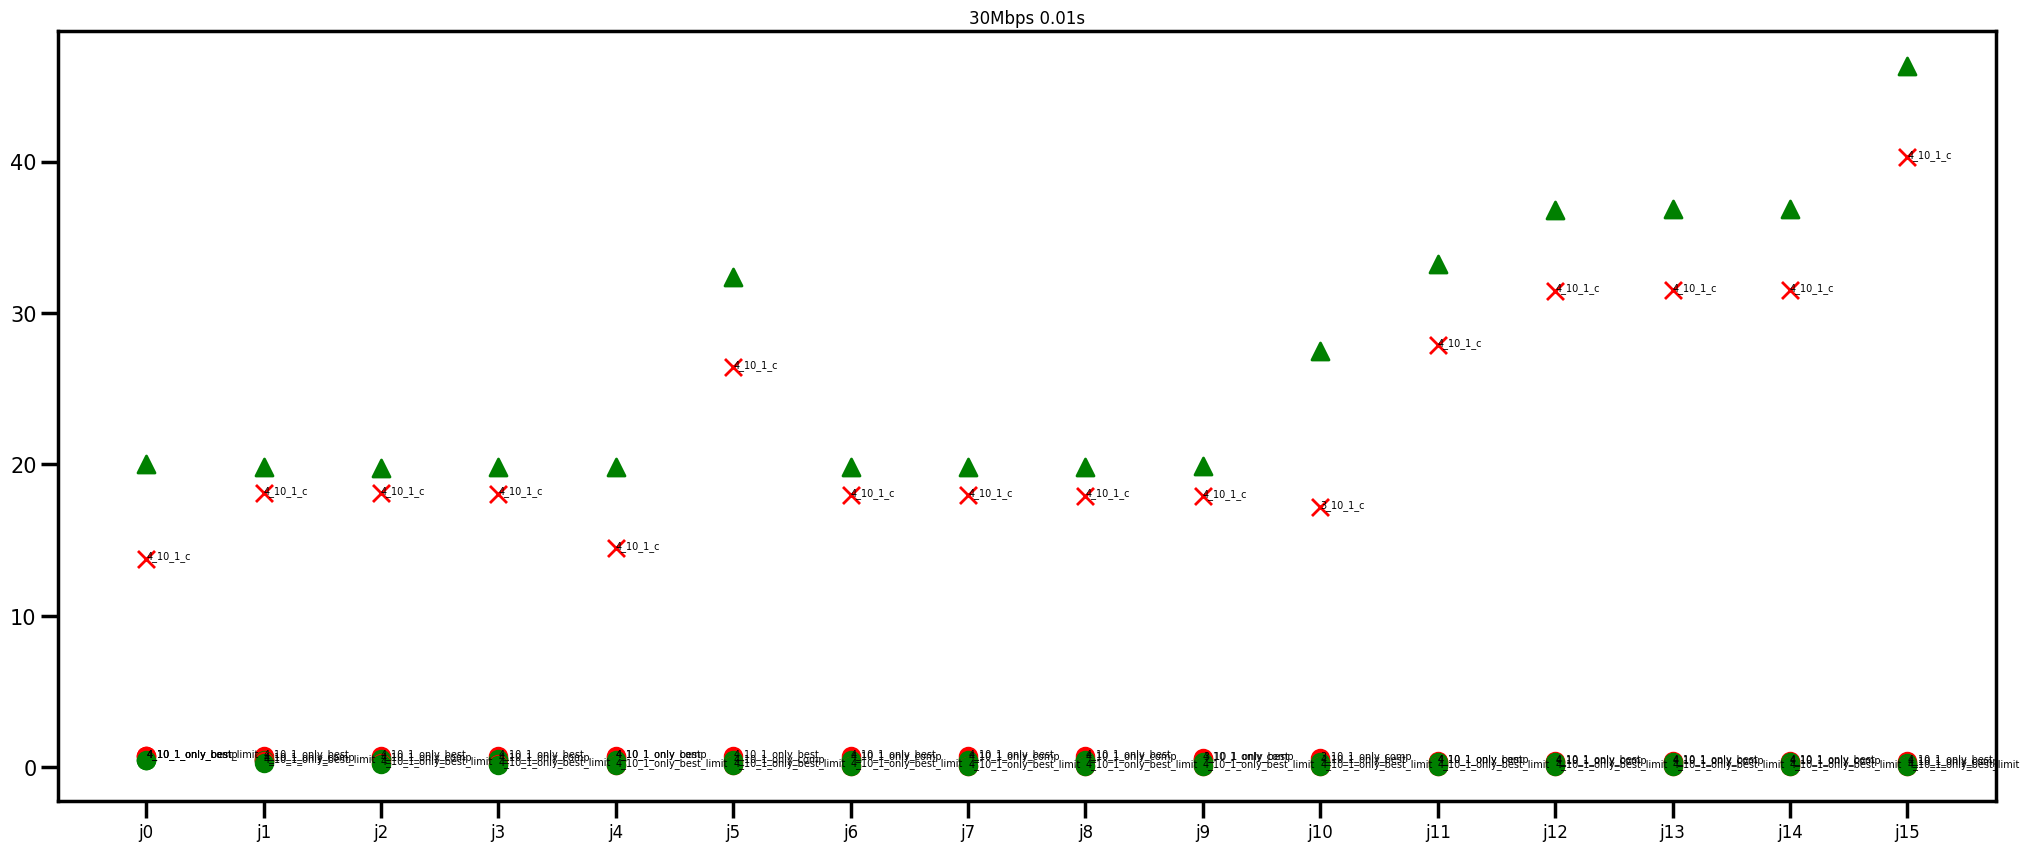

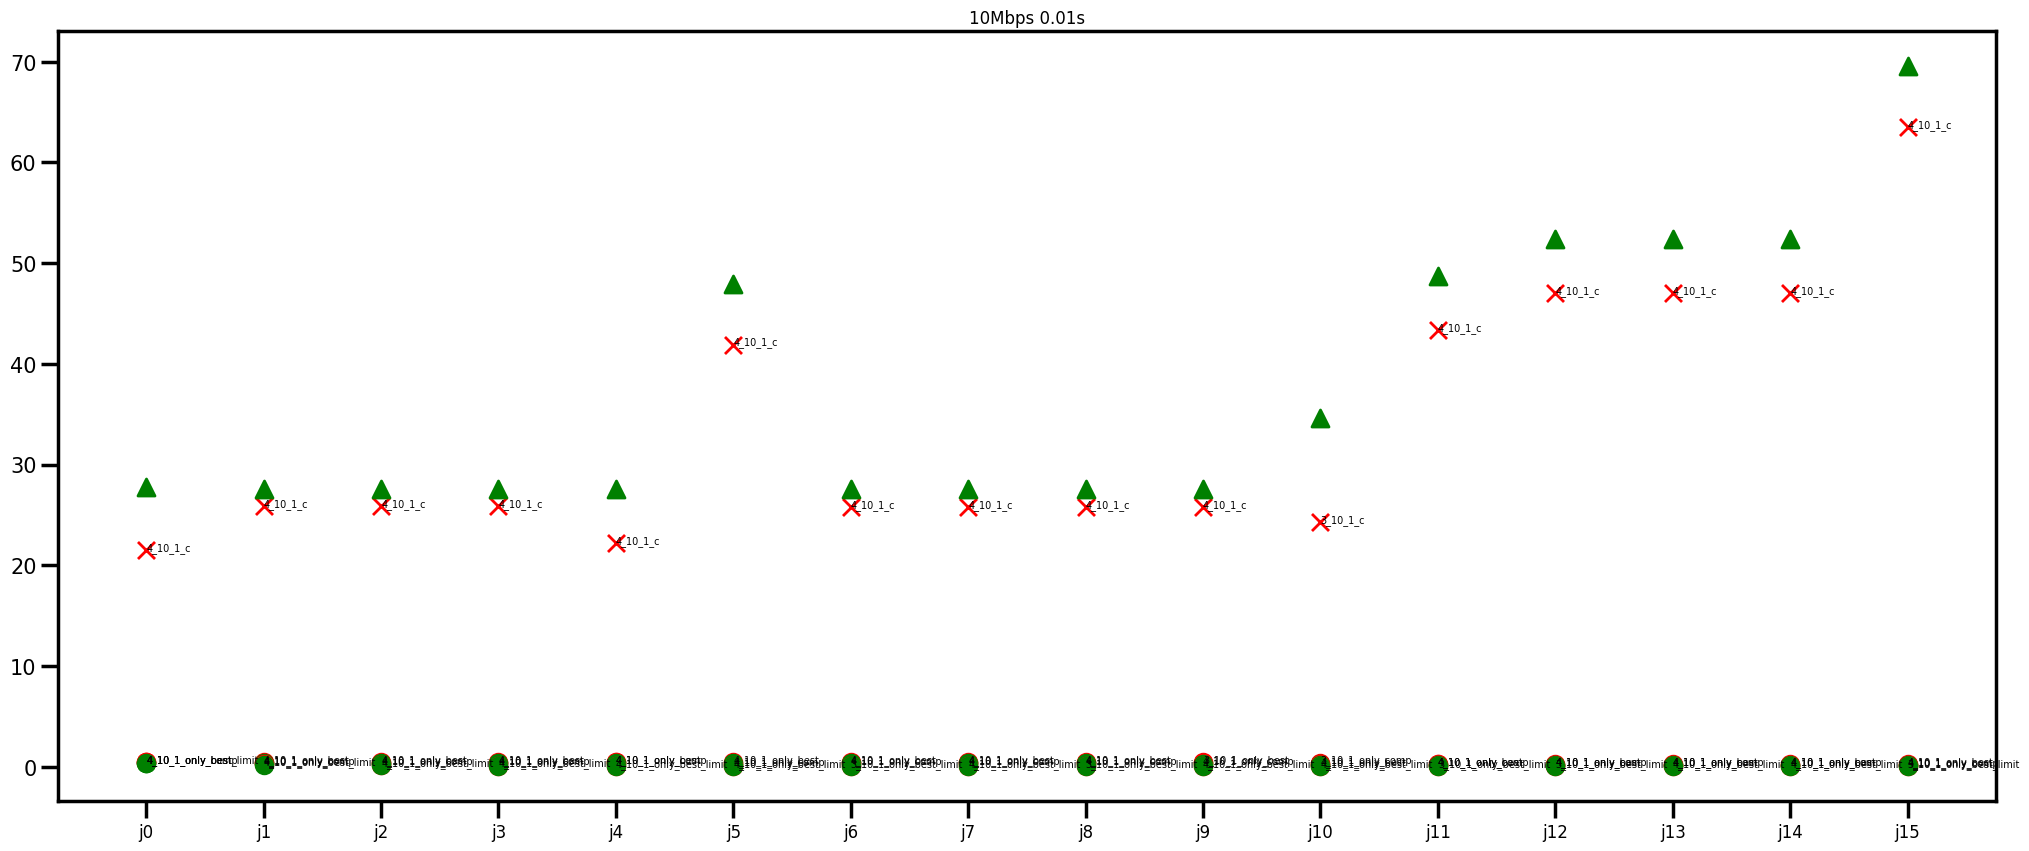

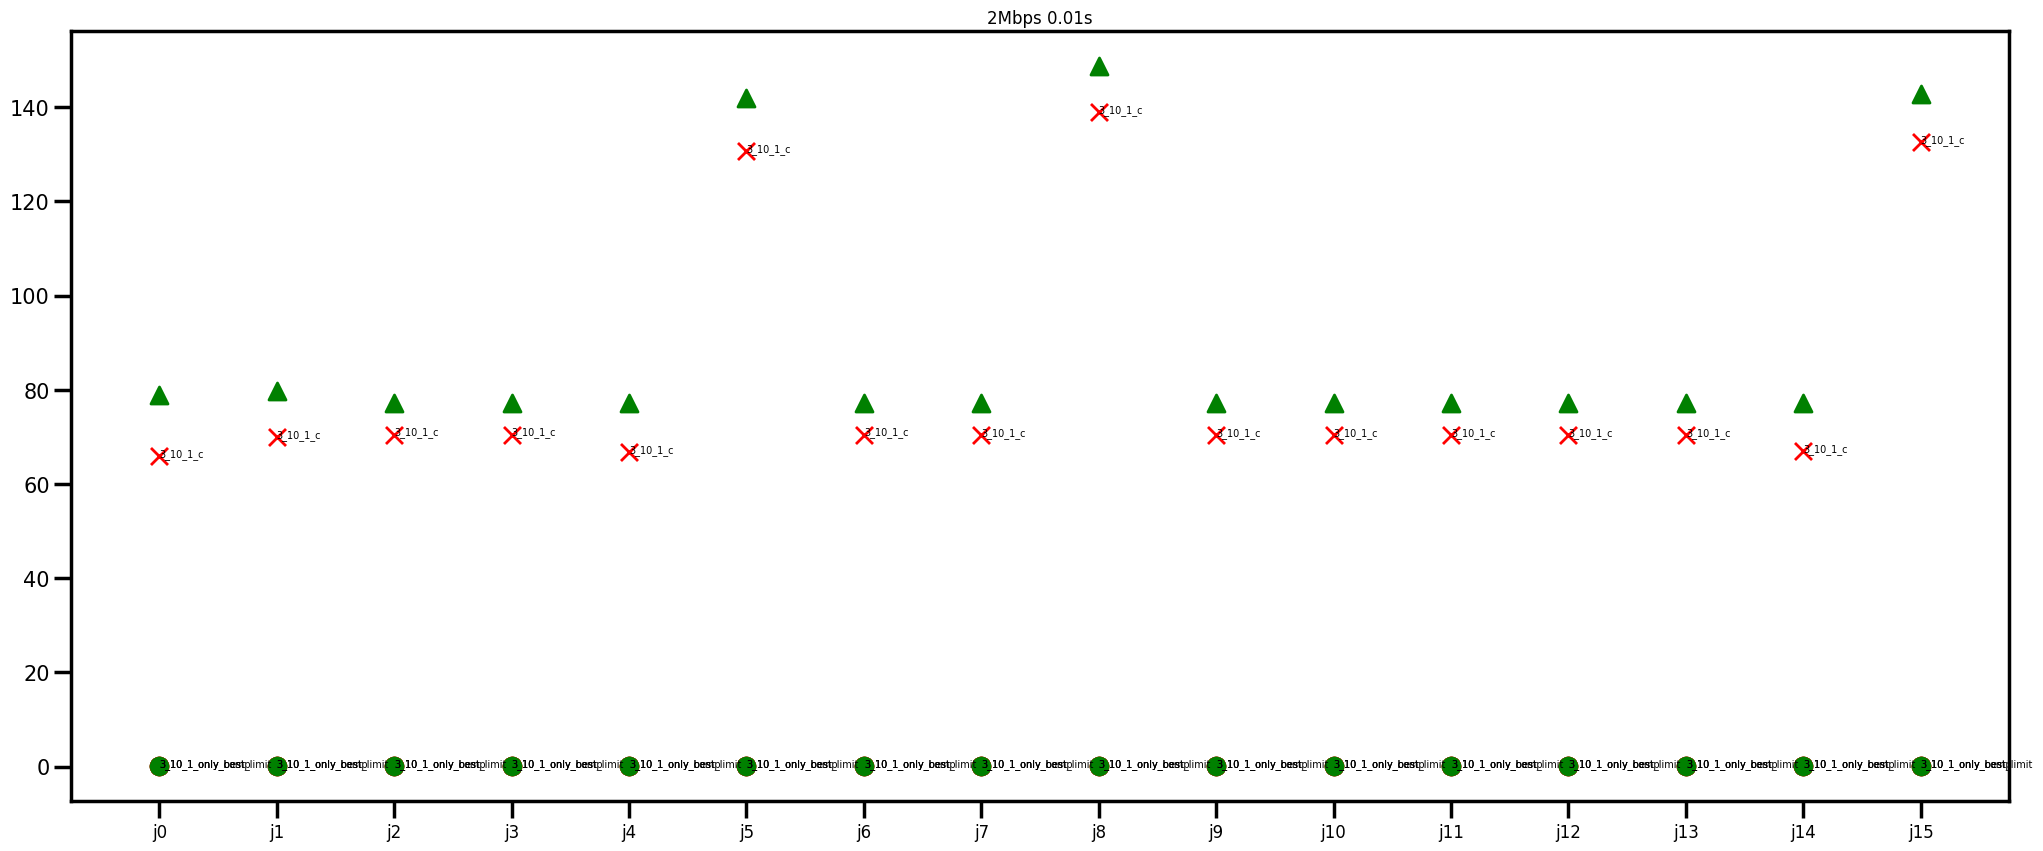

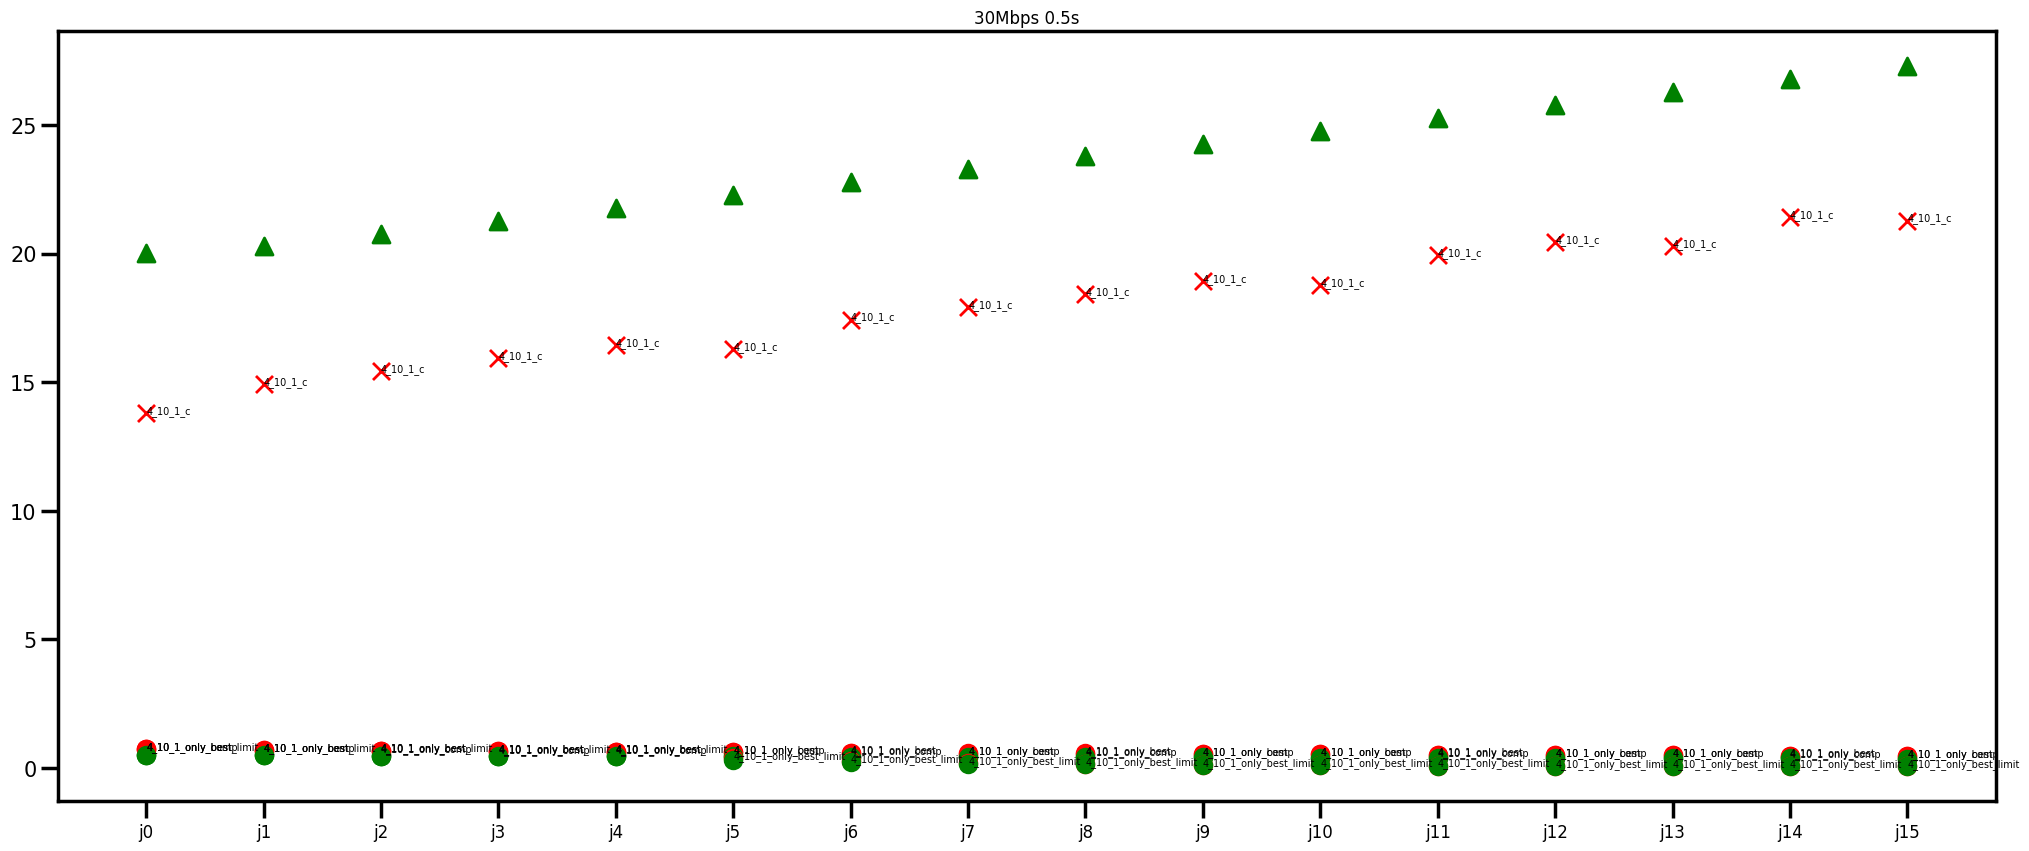

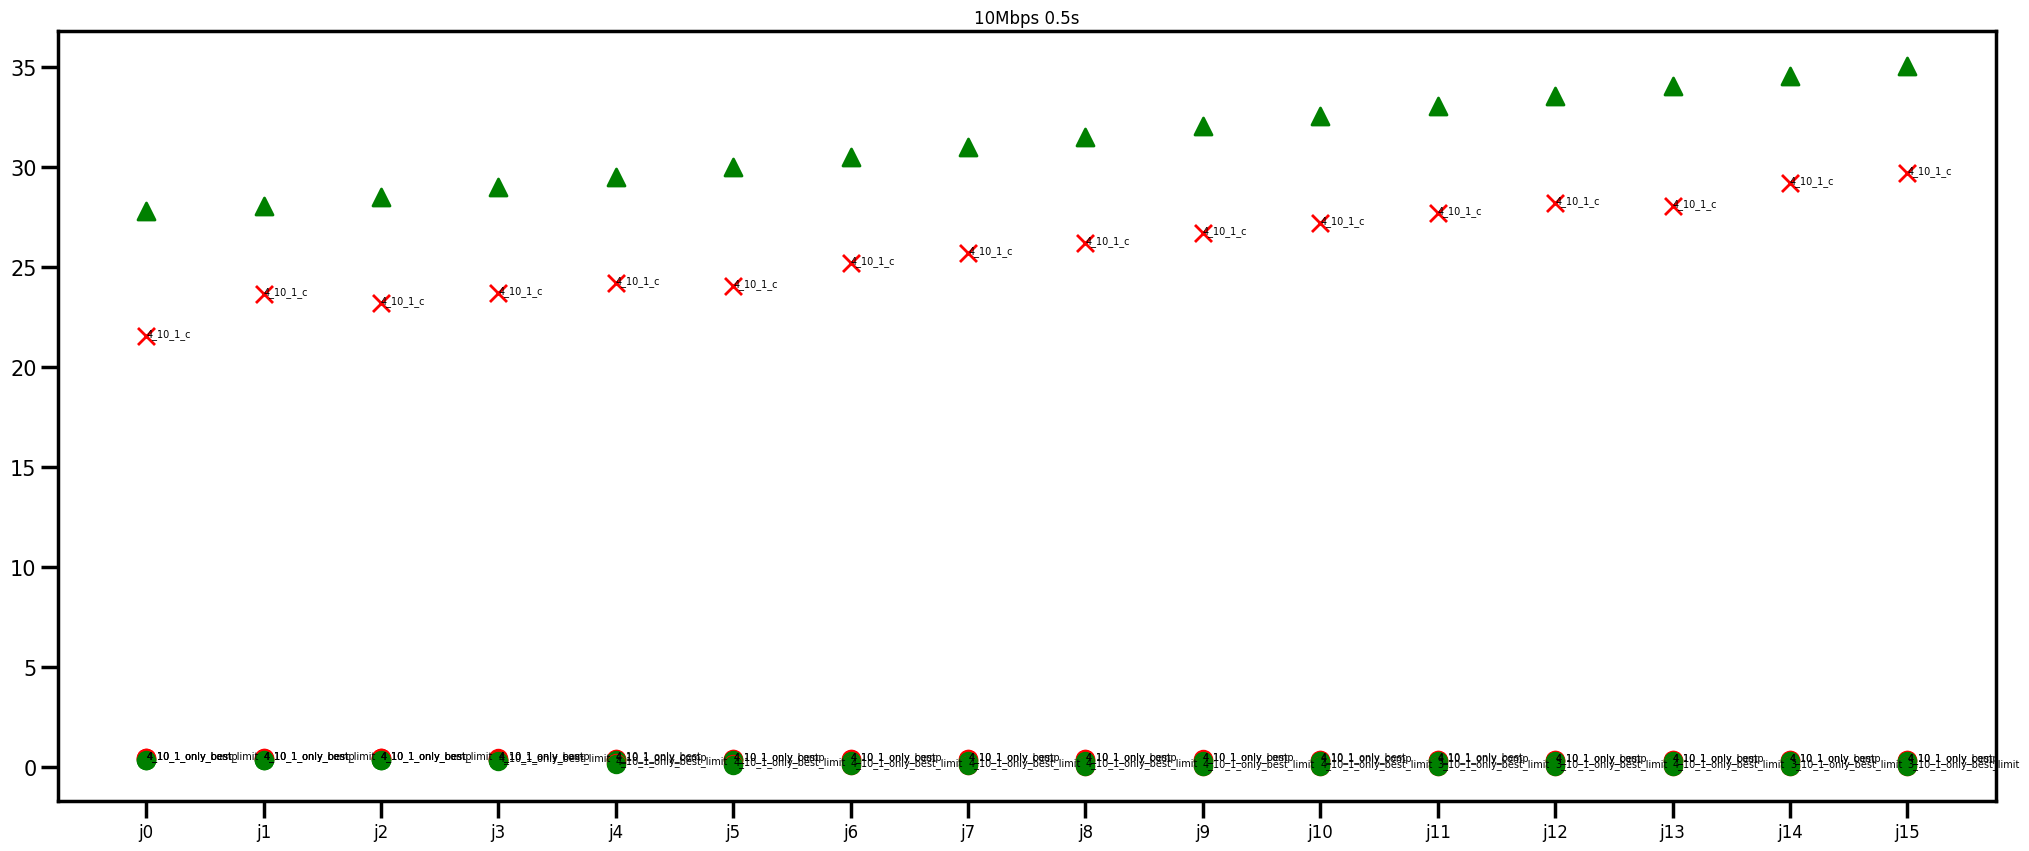

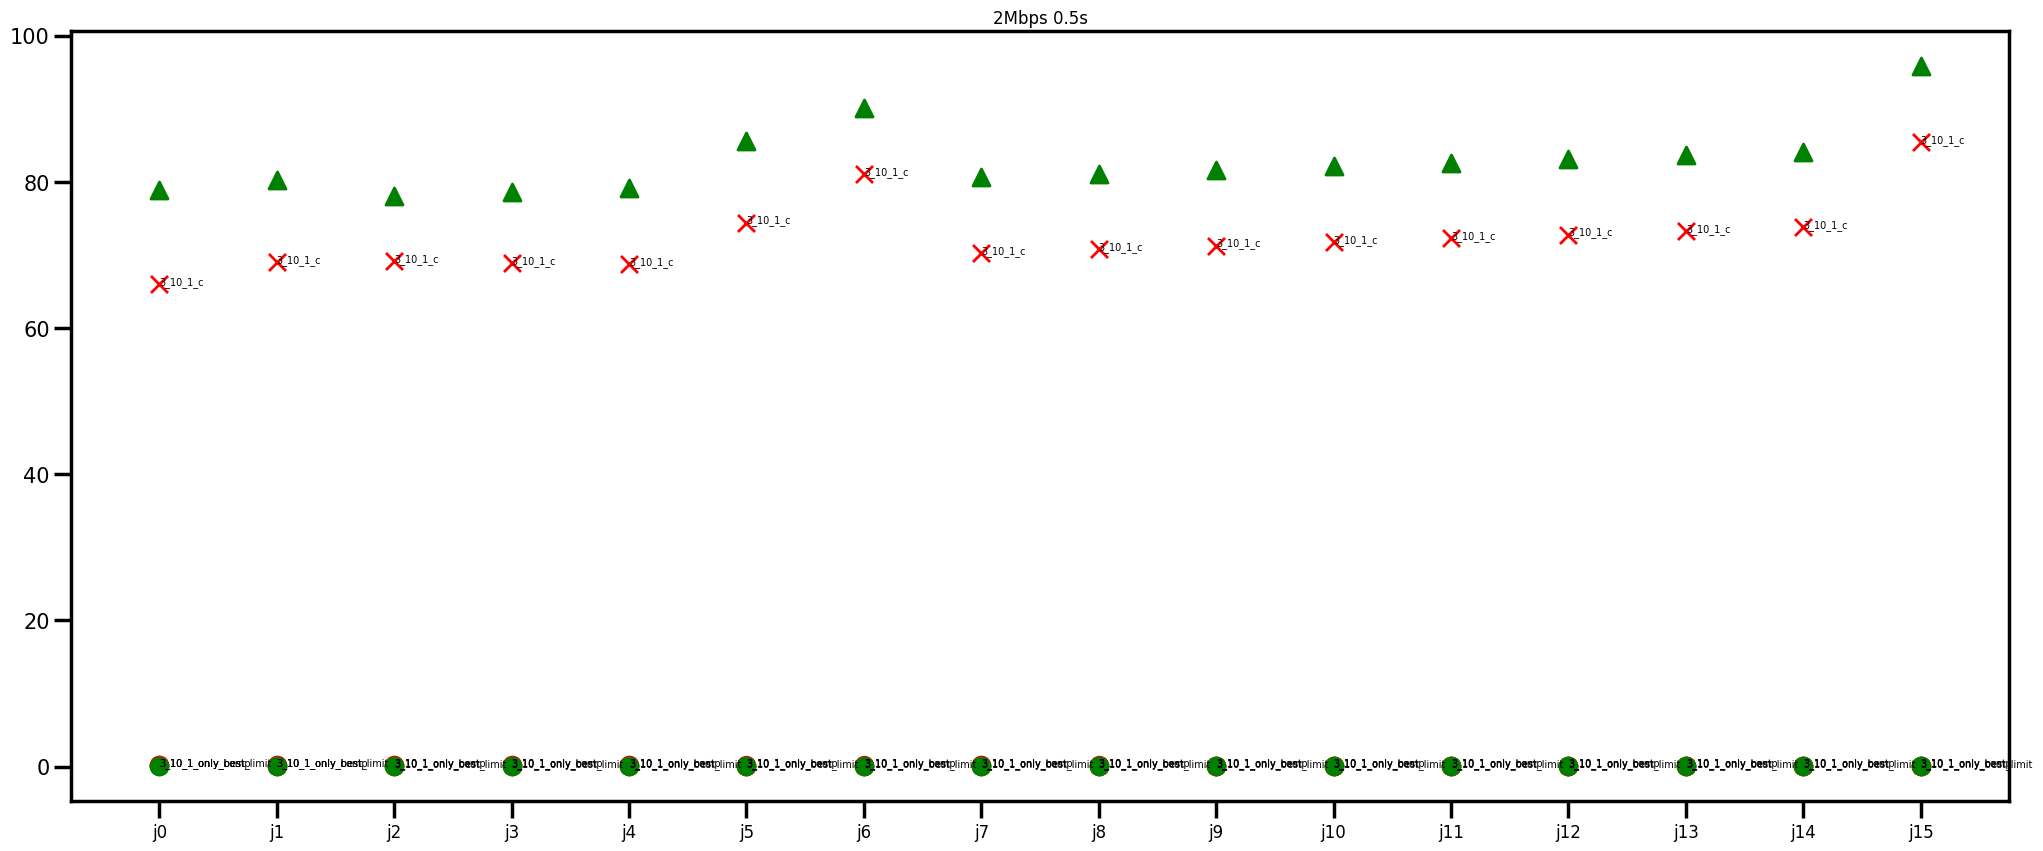

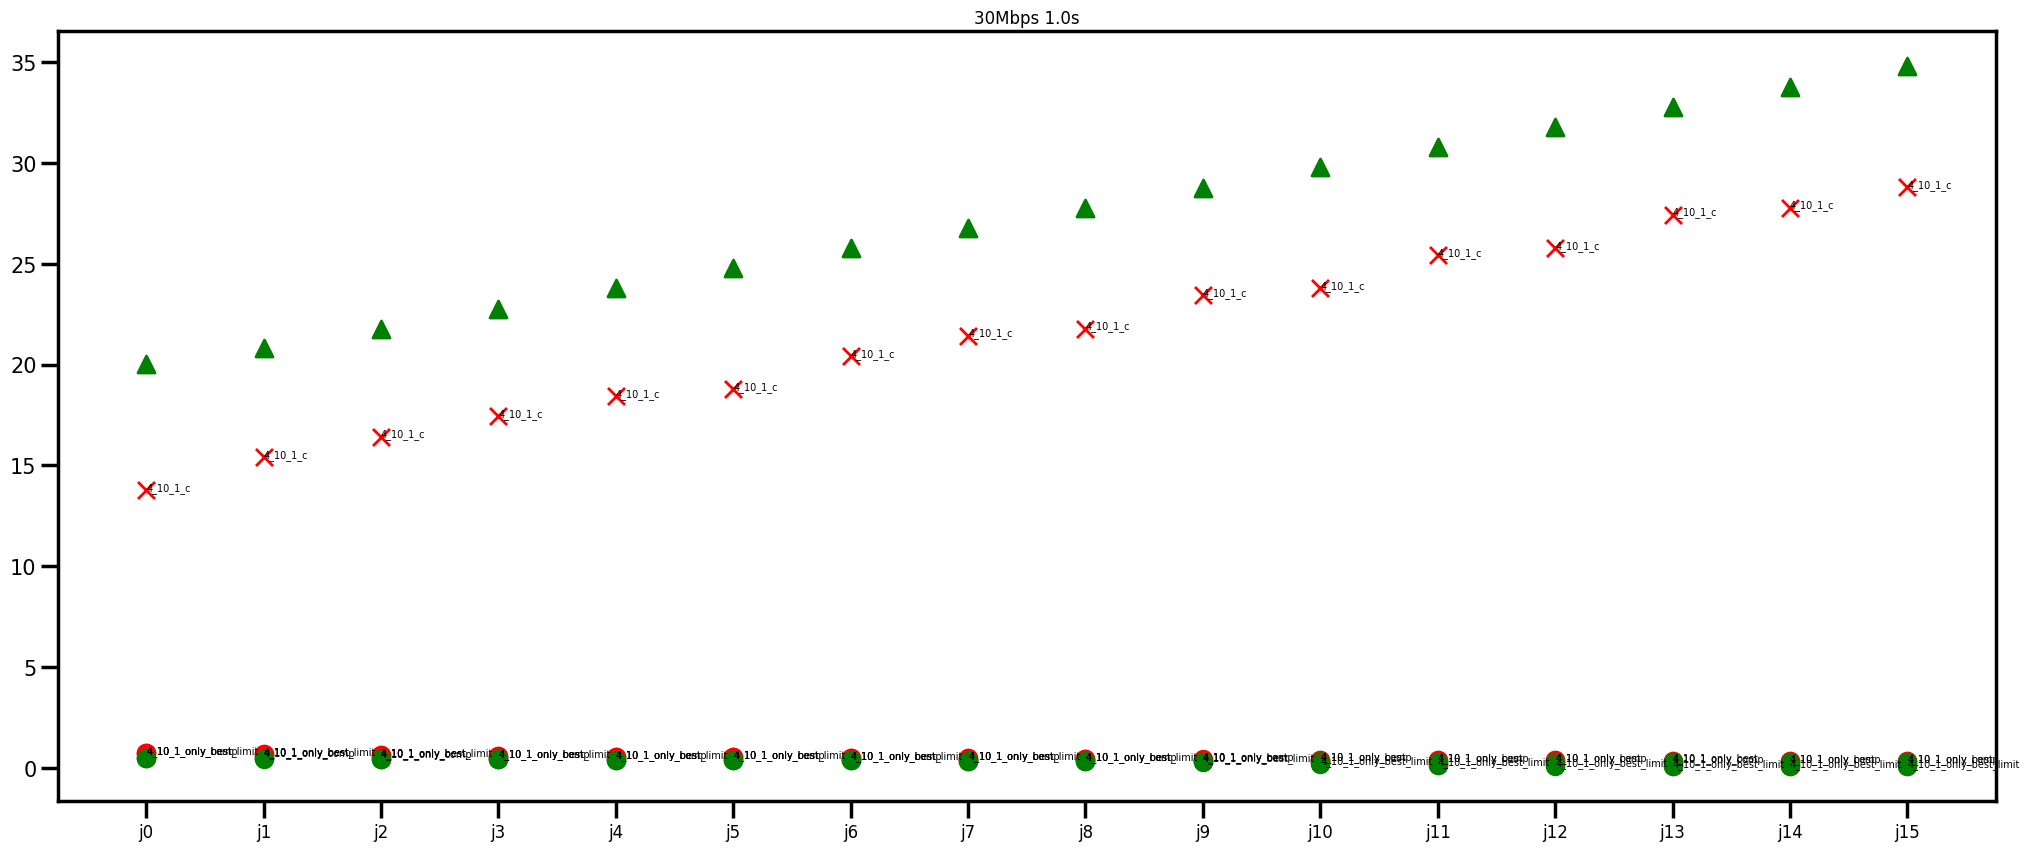

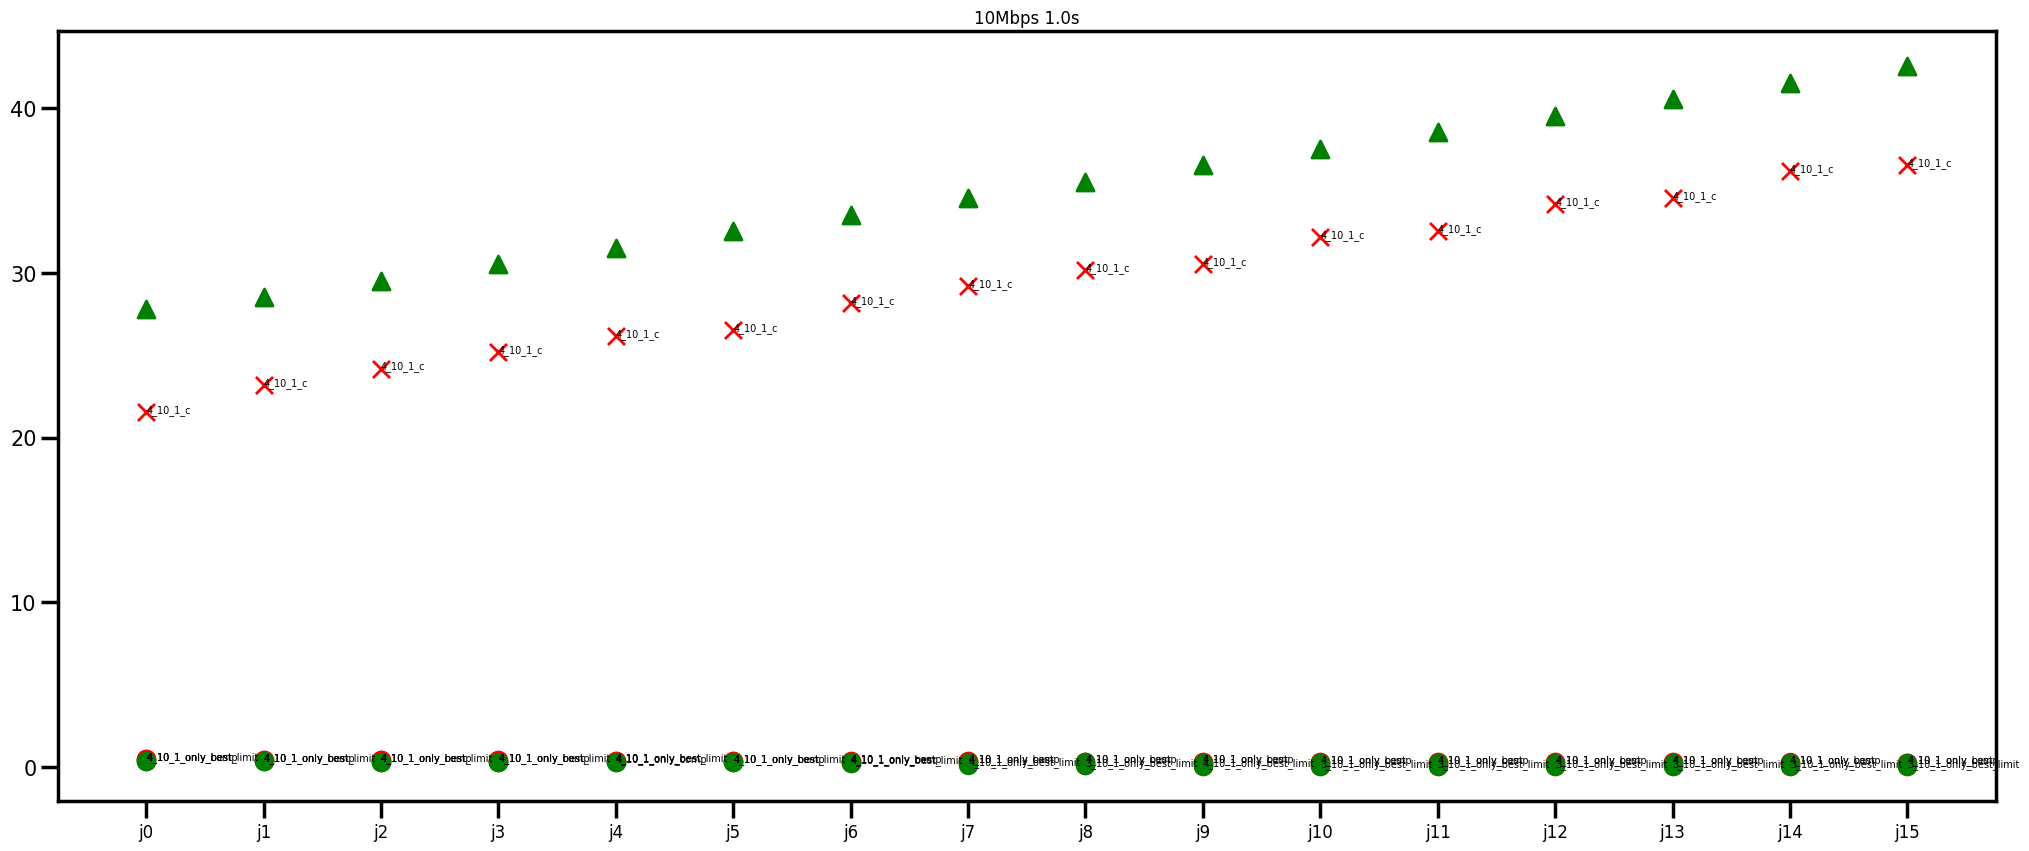

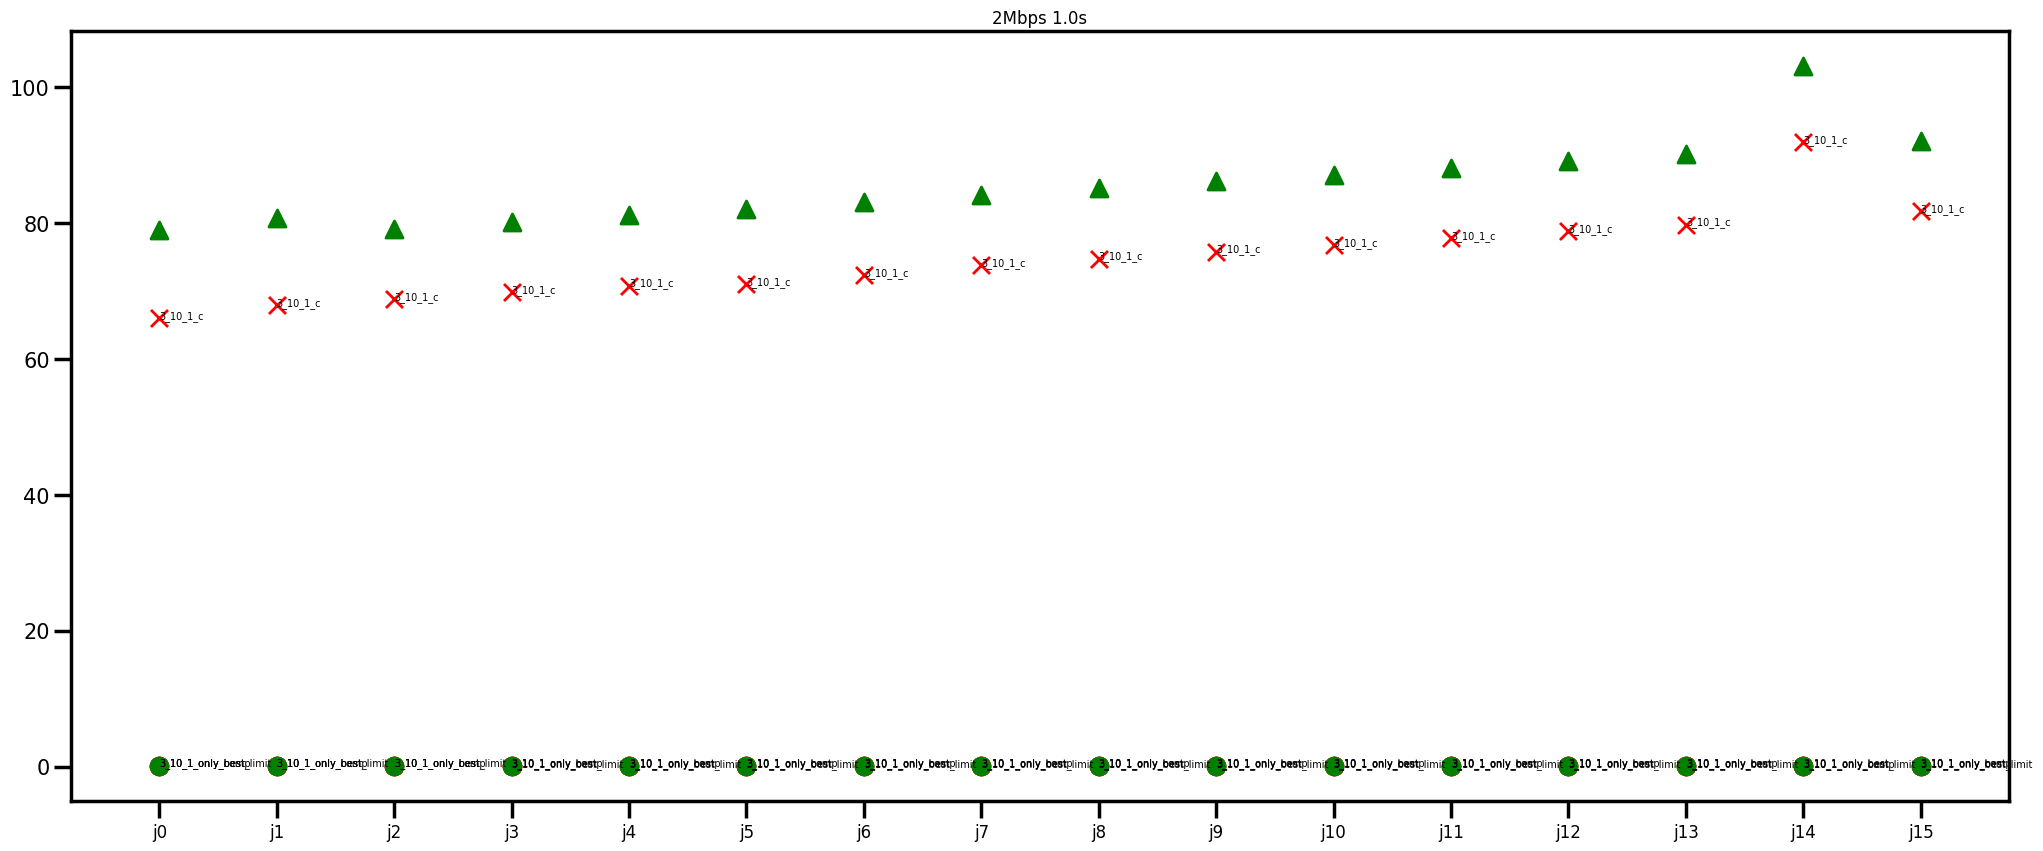

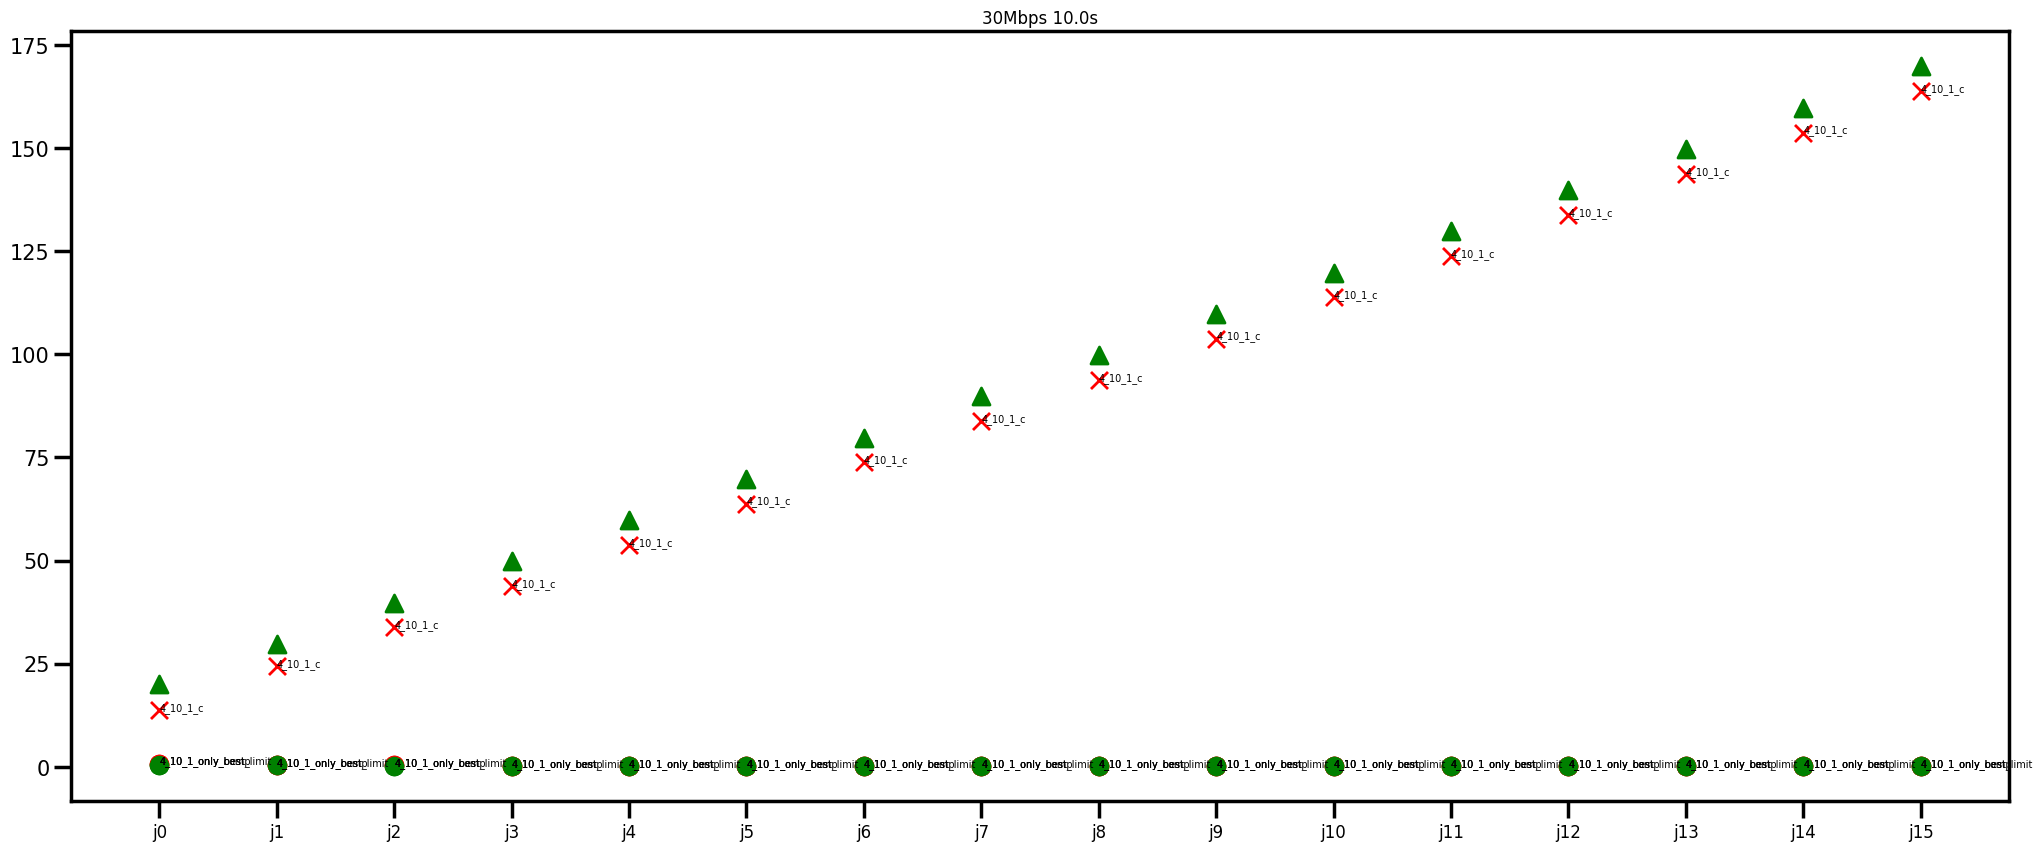

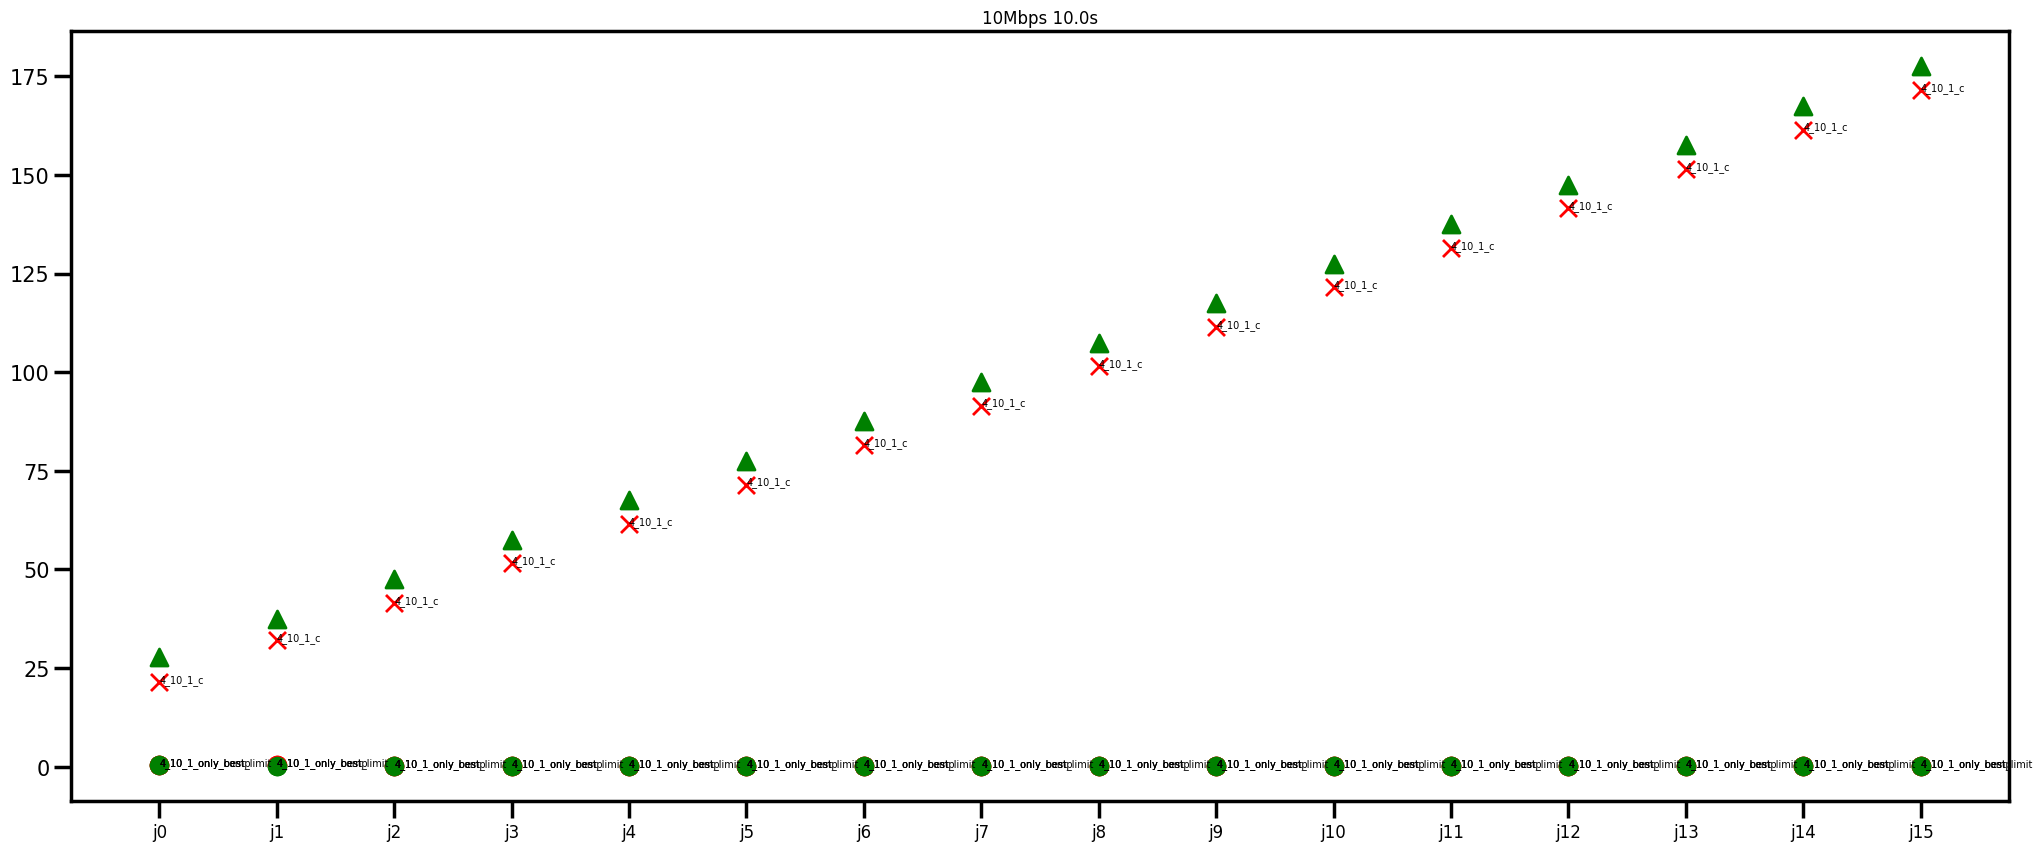

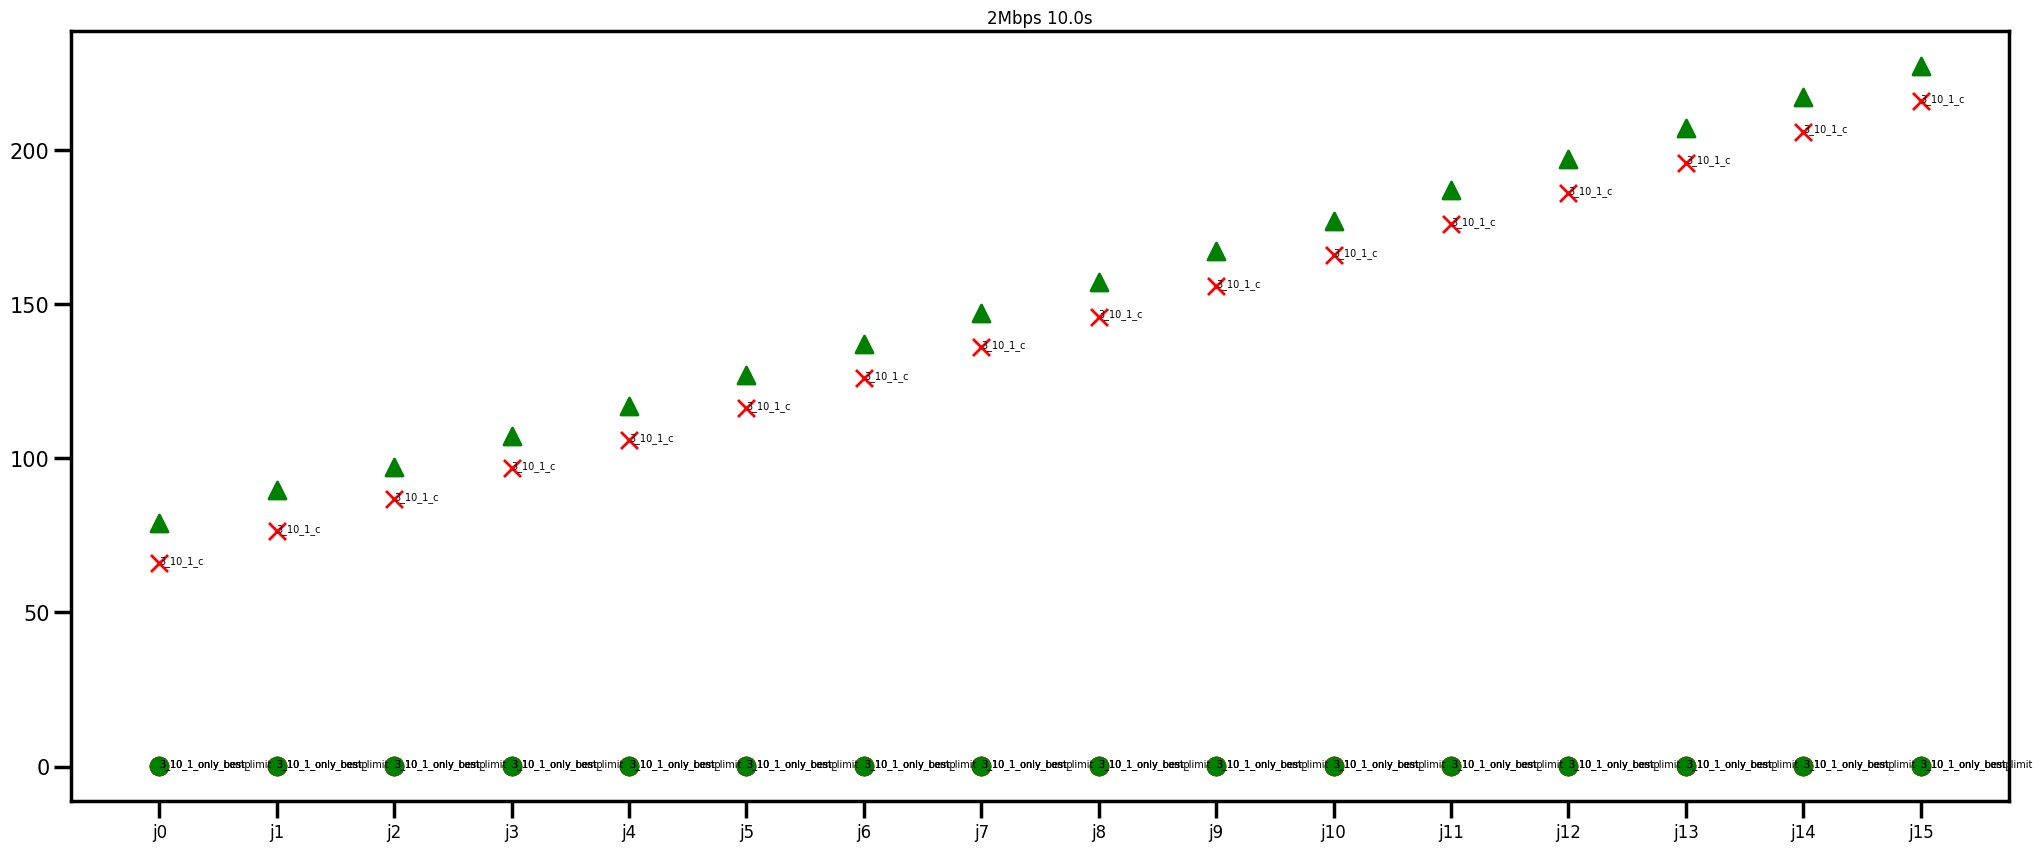

In [1063]:
# bws = [240, 5, 2]
# bws = [240, 5, 2]
# bws=[240, 30, 20, 15, 10, 2, 1]
bws=[30,10,2]

iats = [0.01, 0.5, 1.0, 10.0]
# iats = [0.001, 0.1, 1.0, 10.0]
inp=10
global_real=[]
global_pred=[]

global_full_real_time=[]
global_full_pred_time=[]
global_full_real_th=[]
global_full_pred_th=[]

cur_model = "resnet18"
# cur_model = "vit"
# cur_model = "eff"
csv_header="run_type,arr_time,model,bw,throughput,latency,job_count,max_wait,max_wait_and_arr\n"
lines_to_be_written=[]
for cur_model in ["resnet18", "eff", "vit"]:
    for iat in iats:
        for bw in bws:
            # filename = f"../scheduler/sim.op.bramble-1-3.resnet18.{bw}.{iat}"
            # filename = f"../scheduler/sim.op.bramble-2-4.vit.{bw}.{iat}"
            # filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.eff.{bw}.{iat}"
            filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}"
            # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.azure"
            if not Path(filename).is_file():
                continue
            ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename, skip_ts=False)
            # ts, overhead, bs, bn, world, added_time = simulation_reader("../scheduler/sim.op.bramble-1-3.resnet18")
            # ts, overhead, bs, bn, world, added_time = simulation_reader("../scheduler/sim.op.bramble-1-3.resnet18.0.1")
            # ts, overhead, bs, bn, world, added_time = simulation_reader("../scheduler/sim.op.bramble-1-3.resnet18.1.0")
            # ts, overhead, bs, bn, world, added_time = simulation_reader("../scheduler/sim.op.dummy.resnet18")
            # print(ts)
            if len(ts)==6:
                continue
            # print(overhead)
            # print(bs)
            # print(bn)
            # print(world)

            real_ts={}
            only_wait_ts={}
            specific_waits =[]
            for j in ts:
                if j not in real_ts:
                    real_ts[j]=0
                # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", "vit", world[j], overhead[j]-1,
                # bs[j], bn[j], bw=bw, ty=ty[j]) + added_time[j]
                real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j], overhead[j],
                bs[j], bn[j], bw=bw, ty=ty[j])
                arr_t = added_time[j][0]
                wait_t = added_time[j][1]
                only_wait_ts[j] =  arr_t+wait_t
                specific_waits.append(wait_t)
                real_ts[j] = arr_t+wait_t+real_ts[j]
            # print(real_ts)
            
            print(filename)
            global_full_pred_th.append( round(inp*len(ts)/max(ts.values()),3) )
            global_full_pred_time.append(max(ts.values()))

            global_full_real_th.append( round(inp*len(real_ts)/max(real_ts.values()),3) )
            global_full_real_time.append(max(real_ts.values()))
            lines_to_be_written.append(f"greedy_sim,{iat},{cur_model},{bw},{inp*len(ts)/max(ts.values())},{max(ts.values())},{len(ts)},{max(specific_waits)},{max(only_wait_ts.values())}\n")
            lines_to_be_written.append(f"greedy_real,{iat},{cur_model},{bw},{inp*len(real_ts)/max(real_ts.values())},{max(real_ts.values())},{len(ts)},{max(specific_waits)},{max(only_wait_ts.values())}\n")
            print(f"total predicted time to completion of {len(ts)} jobs: {max(ts.values())}, full throughput: {inp*len(ts)/max(ts.values())}, s/machine: {(sum(ts.values())-sum(only_wait_ts.values()))/len(ts)}")
            print(f"total real time to completion of {len(real_ts)} jobs: {max(real_ts.values())}, full throughput: {inp*len(real_ts)/max(real_ts.values())}, s/machine: { (sum(real_ts.values()) - sum(only_wait_ts.values()))/len(real_ts)}")

            # real_ts = {k:inp/v for k,v in real_ts.items()}
            # ts = {k:inp/v for k,v in ts.items()}
            print(f"rmse: { np.sqrt(np.mean([ (real_ts[j] - ts[j])**2 for j in real_ts])) }")
            print(f"mape: { (np.mean([ abs(real_ts[j] - ts[j])/real_ts[j] for j in real_ts])) }")
            fig, axs = plt.subplots(figsize=(25,10))
            # axs.scatter(ts.keys(), ts.values(), marker=f"${world[]}$")
            for k in ts.keys():
                axs.scatter(k, ts[k], marker="x", s=150, color="red")
                axs.scatter(k, real_ts[k], marker="^", s=150, color="green")
                axs.text(k, ts[k], f"{world[k]}_{bn[k]}_{bs[k]}_{ty[k]}")
                axs.set_title(f"{bw}Mbps {iat}s")
            global_real.extend(list(real_ts.values()))
            global_pred.extend(list(ts.values()))
            # continue
            #special files now for only compute and only communicate
            for s in ["only_comp", "only_comm", "only_best", "only_best_limit"]:
                filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.{s}.azure"
                if not Path(filename).is_file():
                    continue
                ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename, skip_ts=False)
                if len(ts)==6:
                    continue
                if "best" not in filename:
                    ty = {j:"c" if "comp" in filename else "nw" for j in ts}

                real_ts={}
                only_wait_ts={}
                specific_waits=[]
                for j in ts:
                    if j not in real_ts:
                        real_ts[j]=0
                    # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
                    # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
                    real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j], overhead[j],
                    bs[j], bn[j], bw=bw, ty=ty[j])
                    arr_t = added_time[j][0]
                    wait_t = added_time[j][1]
                    specific_waits.append(wait_t)
                    only_wait_ts[j] =  arr_t+wait_t
                    real_ts[j] = arr_t+wait_t+real_ts[j] 
                # print(real_ts)
                # global_full_pred_th.append(inp*len(ts)/max(ts.values()))
                # global_full_pred_time.append(max(ts.values()))

                # global_full_real_th.append(inp*len(real_ts)/max(real_ts.values()))
                # global_full_real_time.append(max(real_ts.values()))
                
                print(filename, s)
                lines_to_be_written.append(f"{s}_sim,{iat},{cur_model},{bw},{inp*len(ts)/max(ts.values())},{max(ts.values())},{len(ts)},{max(specific_waits)},{max(only_wait_ts.values())}\n")
                lines_to_be_written.append(f"{s}_real,{iat},{cur_model},{bw},{inp*len(real_ts)/max(real_ts.values())},{max(real_ts.values())},{len(ts)},{max(specific_waits)},{max(only_wait_ts.values())}\n")
                print(f"total predicted time to completion of {len(ts)} jobs: {max(ts.values())}, full throughput: {inp*len(ts)/max(ts.values())}, s/machine: {(sum(ts.values())-sum(only_wait_ts.values()))/len(ts)}")
                print(f"total real time to completion of {len(real_ts)} jobs: {max(real_ts.values())}, full throughput: {inp*len(real_ts)/max(real_ts.values())}, s/machine: {(sum(real_ts.values())-sum(only_wait_ts.values()))/len(real_ts)}")
                # print(f"{s} rmse: { np.sqrt(np.mean([ (real_ts[j] - ts[j])**2 for j in real_ts])) }")
                # print(f"{s} mape: { (np.mean([ abs(real_ts[j] - ts[j])/real_ts[j] for j in real_ts])) }")
                real_ts = {k:inp/(v if v!=0 else 1) for k,v in real_ts.items()}
                ts = {k:inp/(v if v!=0 else 1) for k,v in ts.items()}
                for k in ts.keys():
                    axs.scatter(k, ts[k], marker="o", color="red")
                    axs.scatter(k, real_ts[k], marker="o", color="green")
                    axs.text(k, ts[k], f"{world[k]}_{bn[k]}_{bs[k]}_{s}")
                    # axs.set_title(f"{bw}Mbps {iat}s")
                

            print()

print("global rmse, mape")
print(f"rmse: { np.sqrt(np.mean([ (global_real[j] - global_pred[j])**2 for j in range(len(global_pred))])) }")
print(f"mae: { (np.mean([ abs(global_real[j] - global_pred[j]) for j in range(len(global_pred))])) }")
print(f"mape: { (np.mean([ abs(global_real[j] - global_pred[j])/global_real[j] for j in range(len(global_pred))])) }")
print()
print("global total time and throughput")
print(f"std real time: {np.std( global_full_real_time )}")
print(f"std real th: {np.std( global_full_real_th )}")
print(f"std pred time: {np.std( global_full_pred_time )}")
print(f"std pred th: {np.std( global_full_pred_th )}")
print(f"std pred-real abs diff {(np.std([ abs(global_full_real_th[j] - global_full_pred_th[j]) for j in range(len(global_full_pred_time))]))}")

print(f"rmse time: { np.sqrt(np.mean([ (global_full_real_time[j] - global_full_pred_time[j])**2 for j in range(len(global_full_pred_time))])) }")
print(f"rmse th: { np.sqrt(np.mean([ (global_full_real_th[j] - global_full_pred_th[j])**2 for j in range(len(global_full_pred_th))])) }")
print(f"mae time: { (np.mean([ abs(global_full_real_time[j] - global_full_pred_time[j]) for j in range(len(global_full_pred_time))])) }")
print(f"mae th: { (np.mean([ abs(global_full_real_th[j] - global_full_pred_th[j]) for j in range(len(global_full_pred_time))])) }")
print(f"mape time: { np.sqrt(np.mean([ abs(global_full_real_time[j] - global_full_pred_time[j])/global_full_real_time[j] for j in range(len(global_full_pred_time))])) }")
print(f"mape th: { np.sqrt(np.mean([ abs(global_full_real_th[j] - global_full_pred_th[j])/global_full_real_th[j] for j in range(len(global_full_pred_th))])) }")

f=open("sim_vs_real.csv","w")
# f=open("sim_vs_real_azure.csv","w")
f.write(csv_header)
f.writelines(lines_to_be_written)
f.close()
#for batch size 1
#fp rate = 0.35 for eff
#for rate = 3 for eff 
#for rate = 20 for res and vit

#this is for batch size 10
#fp rate = 2.8 for res -> also 2.5 actually?
#fp rate = 2.5 for vit

#res -> 2.5 to 3
# {'j0': 30.706000000000003, 'j1': 31.206000000000003, 'j2': 34.54023578590206, 'j3': 38.54871807957278, 'j4': 39.176, 'j5': 66.412}
# {'j0': 80, 'j1': 80, 'j2': 80, 'j3': 80, 'j4': 80, 'j5': 84}
# {'j0': np.int64(1), 'j1': np.int64(1), 'j2': np.int64(1), 'j3': np.int64(1), 'j4': np.int64(1), 'j5': np.int64(1)}
# {'j0': np.int64(10), 'j1': np.int64(10), 'j2': np.int64(10), 'j3': np.int64(10), 'j4': np.int64(10), 'j5': np.int64(10)}
# {'j0': np.int64(4), 'j1': np.int64(4), 'j2': np.int64(4), 'j3': np.int64(4), 'j4': np.int64(4), 'j5': np.int64(4)}
# {'j0': np.float64(47.6694904), 'j1': np.float64(47.6694904), 'j2': np.float64(47.6694904), 'j3': np.float64(47.6694904), 'j4': np.float64(47.6694904), 'j5': np.float64(75.8754904)}
# rmse: 12.754537538136848
# mape: 0.24514640422178194

#resnet18 -> 3->2.8
# {'j0': 32.055, 'j1': 32.555, 'j2': 36.33707528541065, 'j3': 40.79640278259435, 'j4': 41.103, 'j5': 69.11}
# {'j0': 80, 'j1': 80, 'j2': 80, 'j3': 80, 'j4': 80, 'j5': 84}
# {'j0': np.int64(1), 'j1': np.int64(1), 'j2': np.int64(1), 'j3': np.int64(1), 'j4': np.int64(1), 'j5': np.int64(1)}
# {'j0': np.int64(10), 'j1': np.int64(10), 'j2': np.int64(10), 'j3': np.int64(10), 'j4': np.int64(10), 'j5': np.int64(10)}
# {'j0': np.int64(4), 'j1': np.int64(4), 'j2': np.int64(4), 'j3': np.int64(4), 'j4': np.int64(4), 'j5': np.int64(4)}
# {'j0': np.float64(47.6694904), 'j1': np.float64(47.6694904), 'j2': np.float64(47.6694904), 'j3': np.float64(47.6694904), 'j4': np.float64(47.6694904), 'j5': np.float64(77.22449040000001)}
# rmse: 11.231554113703327
# mape: 0.21156062842690213

#
# {'j0': 32.729, 'j1': 33.229, 'j2': 37.240534388197425, 'j3': 41.926016581861155, 'j4': 42.066, 'j5': 70.458}
# {'j0': 80, 'j1': 80, 'j2': 80, 'j3': 80, 'j4': 80, 'j5': 84}
# {'j0': np.int64(1), 'j1': np.int64(1), 'j2': np.int64(1), 'j3': np.int64(1), 'j4': np.inqt64(1), 'j5': np.int64(1)}
# {'j0': np.int64(10), 'j1': np.int64(10), 'j2': np.int64(10), 'j3': np.int64(10), 'j4': np.int64(10), 'j5': np.int64(10)}
# {'j0': np.int64(4), 'j1': np.int64(4), 'j2': np.int64(4), 'j3': np.int64(4), 'j4': np.int64(4), 'j5': np.int64(4)}
# {'j0': np.float64(47.6694904), 'j1': np.float64(47.6694904), 'j2': np.float64(47.6694904), 'j3': np.float64(47.6694904), 'j4': np.float64(47.6694904), 'j5': np.float64(77.8984904)}
# rmse: 10.490127370025338
# mape: 0.19477888891427889

#inter_arrivla = 0.8, 
# rmse: 4.273794775599762
# mape: 0.2360364127632102


Exception: end it

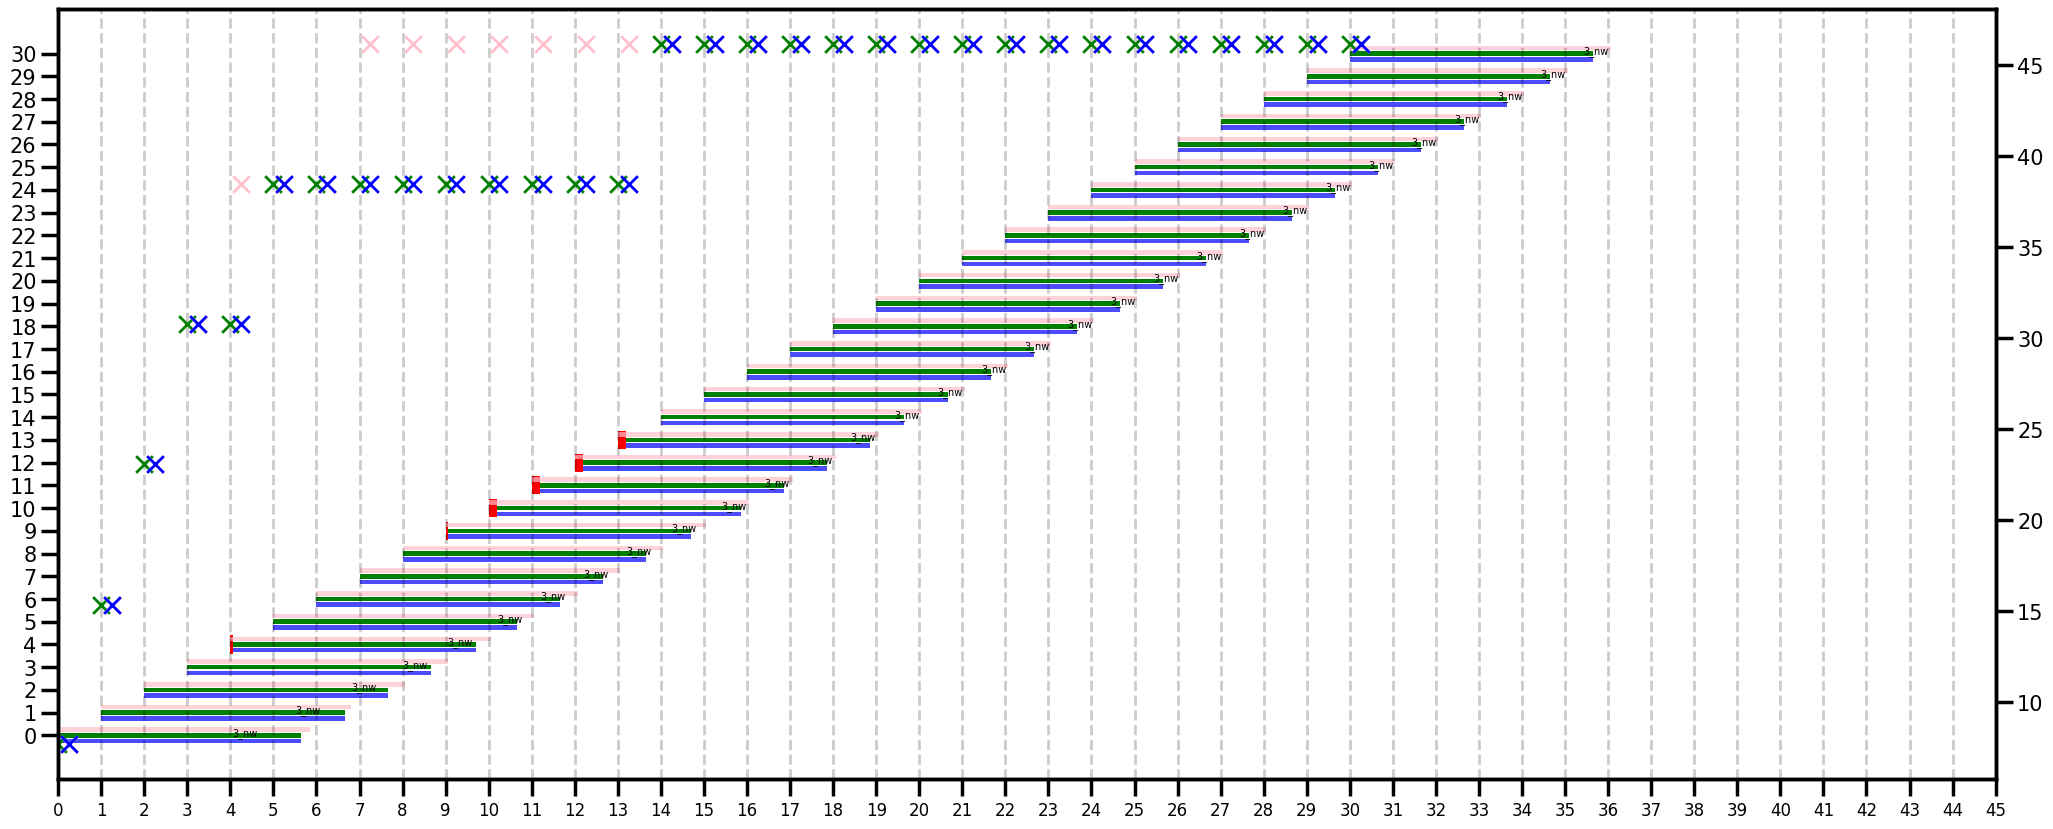

In [1504]:
cur_model="eff"
filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.30.0.01"
# filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.001.uniform.debug"
# filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.1.uniform.debug"
# filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.10.0.1.uniform.debug"
filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.eff.10.1.0.only_comm.uniform.duty_cycle"
filename=f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.eff.10.1.0.uniform.duty_cycle"
# filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.mixed.0.1.uniform.debug"

# filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.10.0.01"
# filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.001.azure"
ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename, skip_ts=False)
fig, bar_axs = plt.subplots(figsize=(25,10))
arr_times = []
for j in ts:
    ind = int(j.split("j")[-1])

    if j not in real_ts:
        real_ts[j]=0
    # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
    # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
    # real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max_2_5.csv", sub, cur_model, world[j], overhead[j]-world[j],
    # bs[j], bn[j], bw=10, ty=ty[j], col_flag="median", agg_flag="mean")
    real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max_2_6.csv", sub, cur_model, world[j], overhead[j]-world[j],
    bs[j], bn[j], bw=10, ty=ty[j], col_flag="median", agg_flag="mean")
    # print(bs[j], bn[j])
    arr_t = added_time[j][0]
    wait_t = added_time[j][1]
    specific_waits.append(wait_t)
    only_wait_ts[j] =  arr_t+wait_t
    # real_ts[j] = arr_t+wait_t+real_ts[j] 
    bar_axs.barh(ind, wait_t, left=arr_t, color="red" )
    # bar_axs.barh(ind, ts[j]-sum(added_time[j]), color="green", left=(sum(added_time[j])), height=0.2)
    bar_axs.barh(ind, real_ts[j], color="green", left=(sum(added_time[j])), height=0.2)
    # bar_axs.barh(ind, pred_rt, color="green", left=(sum(added_time[j])), height=0.2)
    bar_axs.text(ts[j], ind, f'{world[j]}_{ty[j]}')

for j in ts:
    ind = int(j.split("j")[-1])
    w=added_time[j][1]
    arr = added_time[j][0]
    arr_times.append(arr)
    # bar_axs.barh(ind, w, left=arr, color="red" )
    # bar_axs.barh(ind, ts[j]-(sum(added_time[j])), color="green", left=(sum(added_time[j])), height=0.2)
    # bar_axs.barh(ind, arr, edgecolor="black", color='none')
bar_axs1=bar_axs.twinx()
bar_axs1.scatter(arr_times, [round(100*overhead[i]/map_sub["bramble-2-4"],2) for i in overhead], marker="x", color="green")
for s in ["only_comp", "only_comm", "only_best", "only_best_limit"]:
    if "best" in s:
        continue
    filename=f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.eff.10.1.0.{s}.uniform.duty_cycle"
    ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename, skip_ts=False)
    for j in ts:
        ind = int(j.split("j")[-1])
        if ind>30:
            continue
        if j not in real_ts:
            real_ts[j]=0
        # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
        # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
        # real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j] if 'best' in s else (6 if 'comp' in s else 3),  np.floor(overhead[j]*map_sub["bramble-2-4"]),
        # real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max_2_5.csv", sub, cur_model, world[j],  overhead[j]-world[j],
        # 1, 10, bw=10, ty=ty[j] if 'best' in s else ('c' if 'comp' in s else 'nw'), col_flag="median", agg_flag="mean")
        real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max_2_6.csv", sub, cur_model, world[j],  overhead[j]-world[j],
        1, 10, bw=10, ty=ty[j] if 'best' in s else ('c' if 'comp' in s else 'nw'), col_flag="median", agg_flag="mean")
        arr_t = added_time[j][0]
        wait_t = added_time[j][1]
        specific_waits.append(wait_t)
        only_wait_ts[j] =  arr_t+wait_t
        # real_ts[j] = arr_t+wait_t+real_ts[j] 
        # bar_axs.barh(ind, ts[j]-(sum(added_time[j])), color="green", left=(sum(added_time[j])), height=0.2)
        bar_axs.barh(ind+0.25*(-1 if "comm" in s else 1), wait_t, left=arr_t, color="red", alpha=0.2, height=0.2 )
        # bar_axs.barh(ind+0.25*(-1 if "comm" in s else 1), ts[j]-sum(added_time[j]), left=arr_t+wait_t, color="blue" if "comm" in s else "pink", alpha=0.7, height=0.2 )
        bar_axs.barh(ind+0.25*(-1 if "comm" in s else 1), real_ts[j], left=arr_t+wait_t, color="blue" if "comm" in s else "pink", alpha=0.7, height=0.2 )
        # if "comm" in s:
        # bar_axs.barh(ind+0.55*(-1 if "comm" in s else 1), pred_rt, left=arr_t+wait_t, color="orange" if "comm" in s else "pink", alpha=0.7, height=0.2 )
    bar_axs1.scatter([i+0.25 for i in arr_times], [round(100*overhead[i]/map_sub["bramble-2-4"],2) for i in overhead if int(i.split("j")[-1])<=30], marker="x", color="blue" if "comm" in s else "pink")

bar_axs.set_xticks(np.arange(0,46,1))
bar_axs.set_yticks(np.arange(0,31,1))
bar_axs.xaxis.grid(True, linestyle='--', color="black", alpha=0.2)




raise Exception("end it")



print(overhead)
real_ts={}
only_wait_ts={}
specific_waits=[]
for j in ts:
    if j not in real_ts:
        real_ts[j]=0
    # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
    # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
    real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j], overhead[j]-1,
    bs[j], bn[j], bw=bw, ty=ty[j])
    # print(bs[j], bn[j])
    arr_t = added_time[j][0]
    wait_t = added_time[j][1]
    specific_waits.append(wait_t)
    only_wait_ts[j] =  arr_t+wait_t
    real_ts[j] = arr_t+wait_t+real_ts[j] 
    # real_ts[j] = arr_t+wait_t+pred_rt 
fig, evo_axs = plt.subplots(figsize=(25,10))
evo_axs1 = evo_axs.twinx()
# evo_axs.set_title()
arr_times = [added_time[i][0]+added_time[i][1] for i in ts.keys()]
# arr_times = [added_time[i][0] for i in ts.keys()]
wait_times = [added_time[i][1] for i in ts.keys()]
evo_axs.plot(arr_times, ts.values(), color="green")
evo_axs.plot(arr_times, real_ts.values(), color="green", linestyle="--")

for ind, i in enumerate(ts.keys()):
    evo_axs.text(arr_times[ind], ts[i], f"{world[i]}_{ty[i]}", fontsize=20)
    # evo_axs.text(arr_times[ind], real_ts[i], f"{world[i]}_{ty[i]}", fontsize=20)
# for i in ts:
#     ar = added_time[i][0]
#     wa = added_time[i][1]
#     h = ts[i]
#     evo_axs.barh(0, width=h,height=0.01, color="blue")
#     evo_axs.barh(0, width=wa,height=0.01,left=ar, color="red")
    # evo_axs.barh(0, height=i,color="green")
evo_axs1.scatter(arr_times, [(overhead[i])/map_sub["bramble-2-4"] for i in overhead], color="green")
# raise Exception("end it")
# print(max(overhead.values())-max(world.values()))
for s in ["only_comp", "only_comm", "only_best", "only_best_limit"]:
    if "best" in s:
        continue
    # filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.30.0.01.{s}"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.001.uniform.debug"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.1.uniform.debug"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.30.0.01.{s}"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/potentially_uncorrected_data/sim.op.bramble-2-4.{cur_model}.10.0.01.{s}"
    # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.30.0.001.{s}.azure"
    ts, overhead, bs, bn, world, added_time, ty, _ = simulation_reader(filename, skip_ts=False)
    for j in ts:
        if j not in real_ts:
            real_ts[j]=0
        # real_ts[j] = best_fit_reader("best_fit.csv", "bramble-2-4", cur_model, world[j], overhead[j]-1,
        # bs[j], bn[j], bw=bw, ty='c' if "comp" in s else (ty[j] if "comm" not in s else "nw")) + added_time[j]
        # real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, world[j] if 'best' in s else (6 if 'comp' in s else 3),  np.floor(overhead[j]*map_sub["bramble-2-4"]),
        real_ts[j], std_val, pred_rt, naive_rt = best_fit_reader("best_fit_max.csv", sub, cur_model, 3,  overhead[j]-1,
        1, 10, bw=bw, ty=ty[j] if 'best' in s else ('c' if 'comp' in s else 'nw'))
        arr_t = added_time[j][0]
        wait_t = added_time[j][1]
        specific_waits.append(wait_t)
        only_wait_ts[j] =  arr_t+wait_t
        real_ts[j] = arr_t+wait_t+real_ts[j] 
        # real_ts[j] = arr_t+wait_t+pred_rt 
    # fig, evo_axs = plt.subplots(figsize=(25,10))
    # evo_axs1 = evo_axs.twinx()
    arr_times = [added_time[i][0]+added_time[i][1] for i in ts.keys()]
    # arr_times = [added_time[i][0] for i in ts.keys()]
    wait_times = [added_time[i][1] for i in ts.keys()]
    # evo_axs.plot(arr_times, ts.values(), linestyle="--", marker="x", alpha=0.5)
    evo_axs.plot(arr_times, real_ts.values(), linestyle="--", marker="x", alpha=0.5)
    print(max(overhead.values()))
    evo_axs1.scatter(arr_times, [(overhead[i])/map_sub["bramble-2-4"] for i in overhead], alpha=0.2)
    for ind, i in enumerate(ts.keys()):
        # evo_axs.text(arr_times[ind], ts[i], f"{world[i]}_{ty[i] if 'best' in s else ('c' if 'comp' in s else 'nw')}", fontsize=20, alpha=0.2)
        evo_axs.text(arr_times[ind], real_ts[i], f"{world[i]}_{ty[i] if 'best' in s else ('c' if 'comp' in s else 'nw')}", fontsize=20, alpha=0.2)


Text(0.5, 0, 'Time(s)')

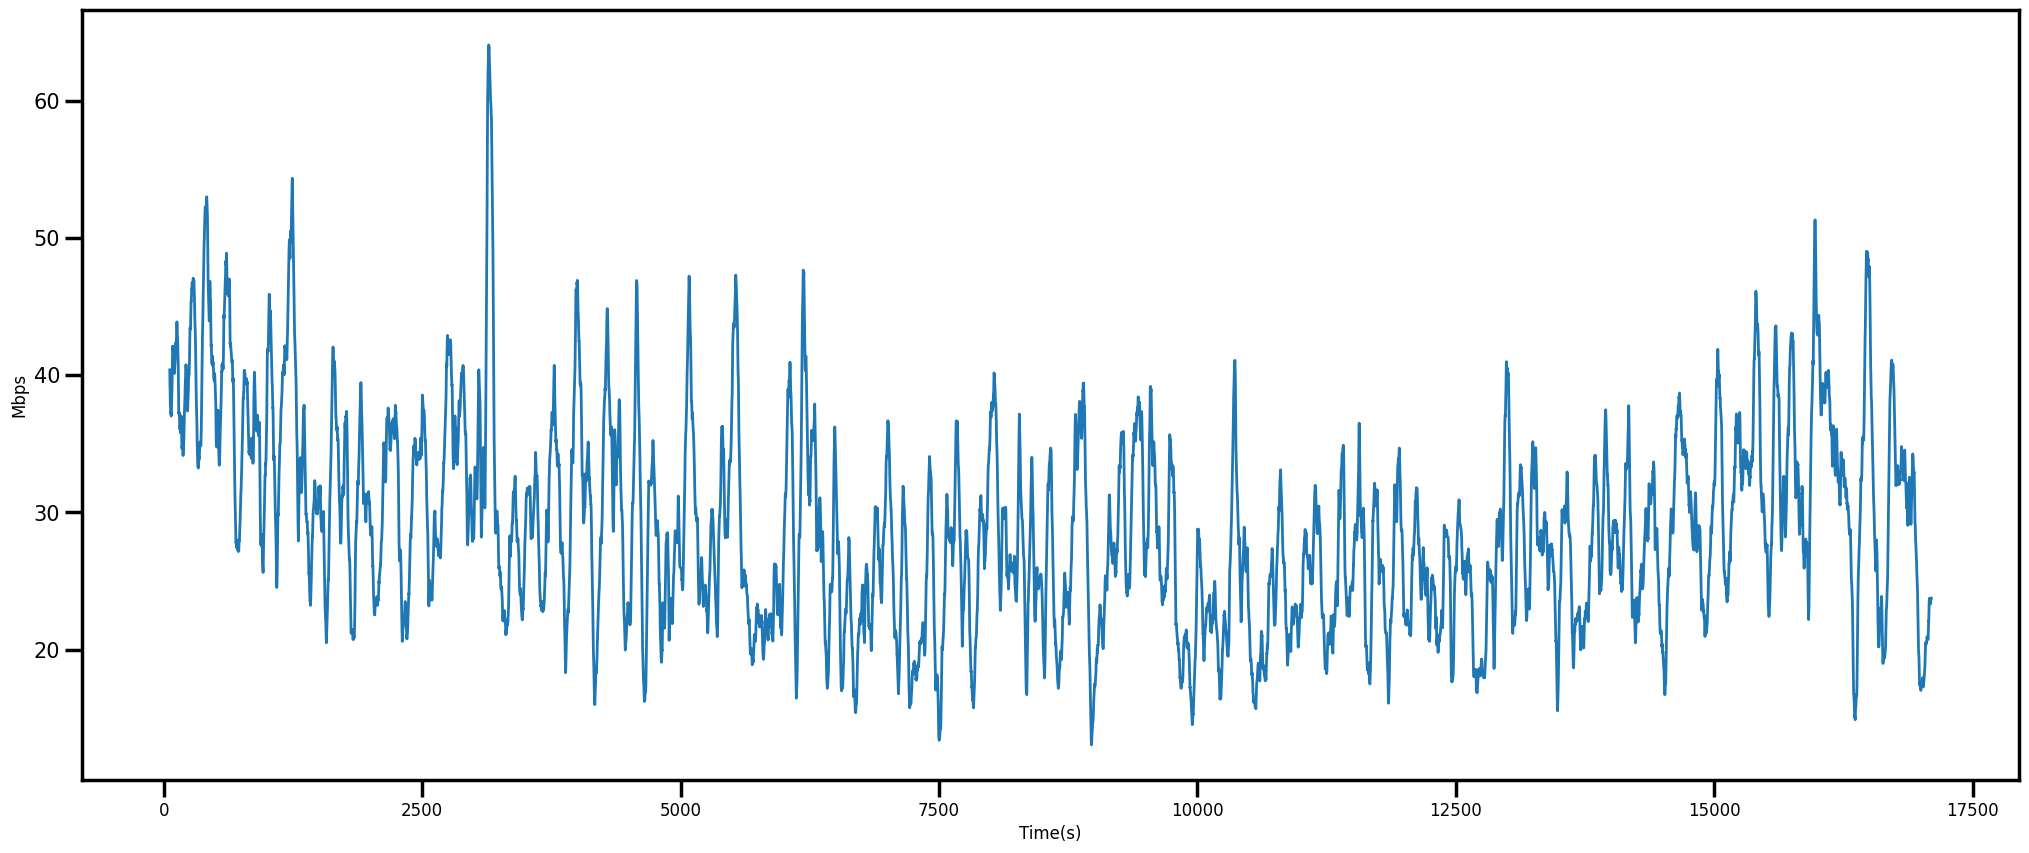

In [1137]:
f=open("iperf-results-day.log")
lines=f.readlines()
time_series_map={}
for line in lines:
    line=line.strip()
    if "MBytes" in line:
        # [  6]   0.00-1.00   sec  10.5 MBytes  88.0 Mbits/sec
        raw = [i for i in line.split(" ") if "-" in i][0]
        ind = float(raw.split("-")[0])
        # print(line.split(" sec"))
        bytes_sent =  float(line.split(" sec")[-1].split("MBytes")[0].strip())
        time_series_map[ind] = bytes_sent*8
fig, axs = plt.subplots(figsize=(25,10))
# axs.plot(time_series_map.keys(), time_series_map.values())
df = pd.DataFrame.from_dict({"ts":[k for k in time_series_map.keys()], "val":[v for v in time_series_map.values()]})
roll_avg = df["val"].rolling(window=60).mean()
axs.plot(time_series_map.keys(), roll_avg)
axs.set_ylabel("Mbps")
axs.set_xlabel("Time(s)")

Exception: end it?

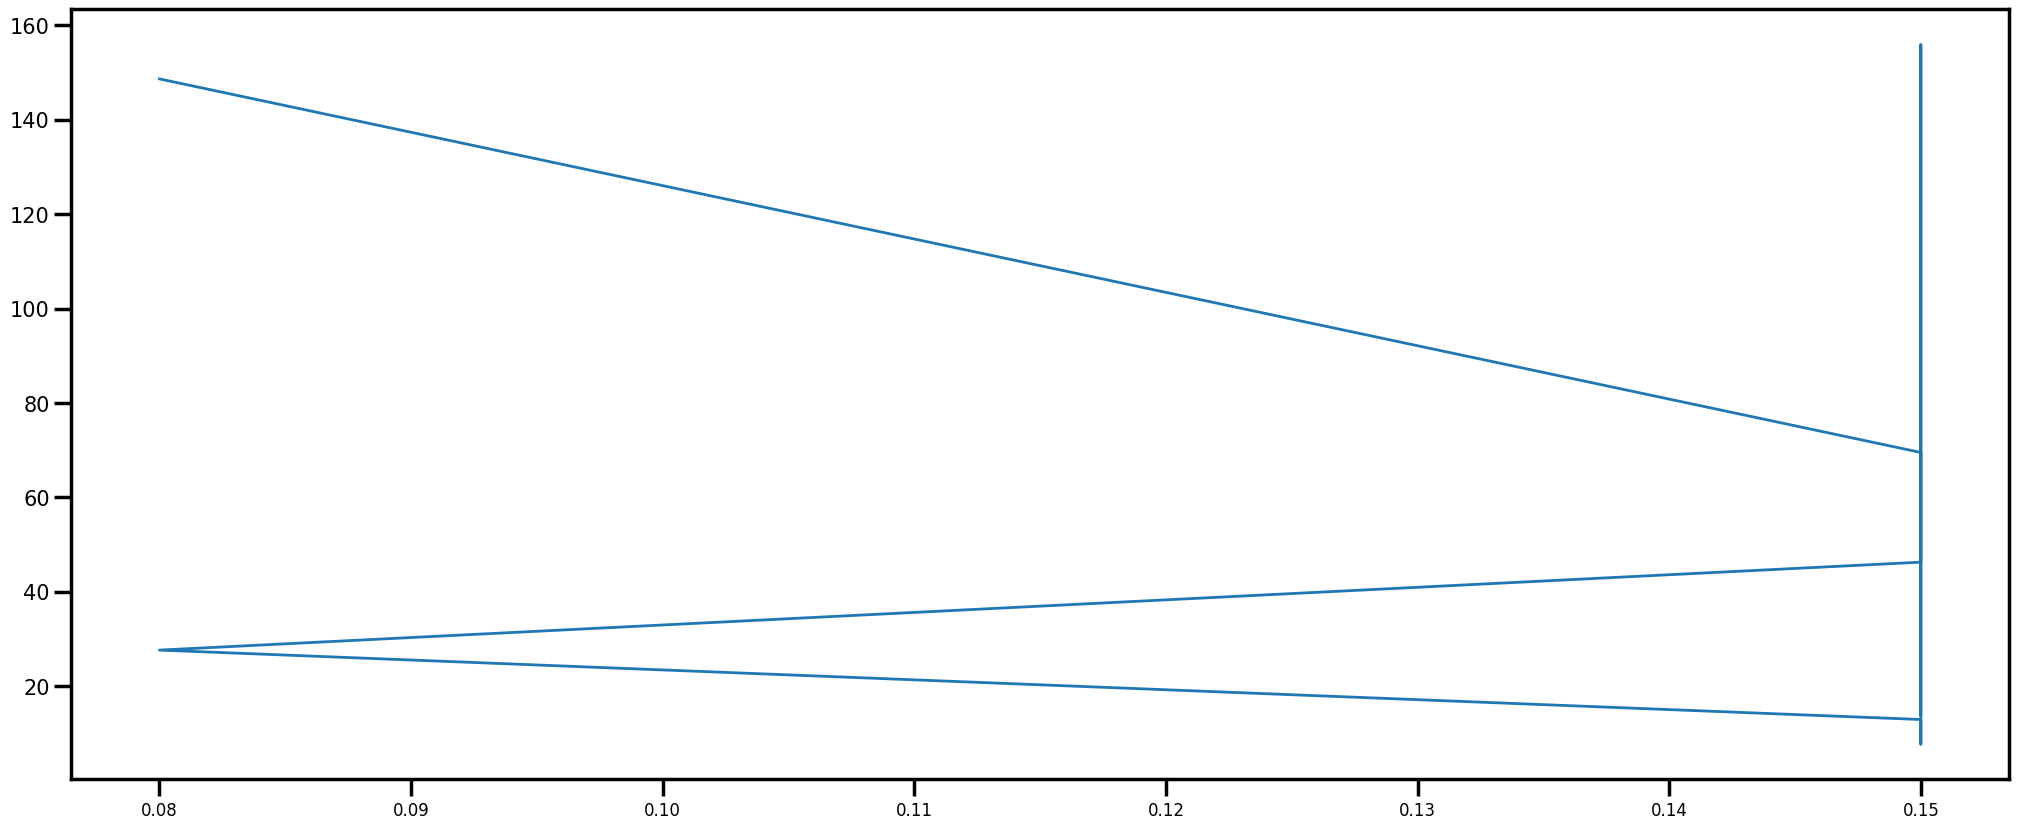

In [1066]:
df = pd.read_csv("sim_vs_real.csv")
# df = pd.read_csv("sim_vs_real_azure.csv")
df = df[df["job_count"]!=6]
run_types = ["greedy", "only_best","only_best_limit", "only_comp", "only_comm", ]
# run_types = ["greedy", "only_best", "only_comp", "only_comm", ]
fig, evo_axs = plt.subplots(figsize=(25,10))
lats = df[(df["run_type"]==f"only_comp_real")&(df["arr_time"]==0.01)]["latency"].values
waits = df[(df["run_type"]==f"only_comp_real")&(df["arr_time"]==0.01)]["max_wait"].values
waits_and_arr = df[(df["run_type"]==f"only_comp_real")&(df["arr_time"]==0.01)]["max_wait_and_arr"].values
arr_t = [waits_and_arr[i] - waits[i] for i in range(len(waits))]

evo_axs.plot(arr_t, lats)
raise Exception("end it?")

fig, axs = plt.subplots(figsize=(25,10))
lats = df[df["run_type"]==f"only_best_real"]["latency"].values
thr = df[df["run_type"]==f"only_best_real"]["throughput"].values
waits = df[df["run_type"]==f"only_best_real"]["max_wait"].values
pair_wise = {lats[i]:thr[i] for i in range(len(thr))}
best_sorted_pair_wise = {k:v for k,v in sorted(pair_wise.items(), key=lambda x:x[0])}
best_lats = list(best_sorted_pair_wise.keys())
best_thr = list(best_sorted_pair_wise.values())
best_waits = [i for i in waits]





for r in run_types:
    # lats = df[df["run_type"]==f"{r}_sim"]["latency"].values
    # thr = df[df["run_type"]==f"{r}_sim"]["throughput"].values
    # pair_wise = {lats[i]:thr[i] for i in range(len(thr))}
    # sorted_pair_wise = {k:v for k,v in sorted(pair_wise.items(), key=lambda x:x[0])}
    # thr = sorted_pair_wise.keys()
    # lats = sorted_pair_wise.values()
    # if r=="greedy":
    #     axs.plot(lats, thr, marker="x", linestyle="--", color="blue")
    # elif r=="only_best":
    #     axs.plot(lats, thr, marker="^", linestyle="--", color="green")
    # else:
    #     axs.scatter(lats,thr, color="red", alpha=0.2)
    
    lats = df[df["run_type"]==f"{r}_real"]["latency"].values
    thr = df[df["run_type"]==f"{r}_real"]["throughput"].values
    waits = df[df["run_type"]==f"{r}_real"]["max_wait"].values
    waits_diff = [ abs(waits[i]-best_waits[i])/(best_waits[i] if best_waits[i]!=0 else 1) for i in range(len(waits))]
    pair_wise = {lats[i]:thr[i] for i in range(len(thr))}
    sorted_pair_wise = {k:v for k,v in sorted(pair_wise.items(), key=lambda x:x[0])}
    x = [abs(i-best_lats[ind])/best_lats[ind] for ind, i in enumerate(sorted_pair_wise.keys())]
    # x = [abs(i) for ind, i in enumerate(sorted_pair_wise.keys())]
    y = [abs(i-best_thr[ind])/best_thr[ind] for ind, i in enumerate(sorted_pair_wise.values())]
    print(round(np.mean(x)*100,2), round(np.mean(y)*100,2), round(np.mean(waits_diff)*100,2), np.mean(waits), np.max(waits), r)
    # y = [abs(i) for ind, i in enumerate(sorted_pair_wise.values())]
    # bar_axs.bar()
    if r=="greedy":
        # axs.plot(x, y, marker="x", linestyle="--", color="blue")
        axs.scatter(x, y, marker="x", linestyle="--", color="blue")
    elif r=="only_best":
        # axs.plot(x, y, marker="^", linestyle="--", color="green")
        axs.scatter(x, y, marker="^", linestyle="--", color="green")
    else:
        axs.scatter(x, y, color="red", alpha=0.5)
# axs.invert_yaxis()
# axs.invert_xaxis()
# axs.set_yscale("log")
# real_latencies = df[df["run_type"]=="greedy_real"]["latency"].values
# real_latencies_best = df[df["run_type"]=="only_best_real"]["latency"].values
# real_latencies_best_limited= df[df["run_type"]=="only_best_limited_real"]["latency"].values
# real_latencies_comp=df[df["run_type"]=="only_comp_real"]["latency"].values
# real_latencies_comm=df[df["run_type"]=="only_comm_real"]["latency"].values
# axs.plot()

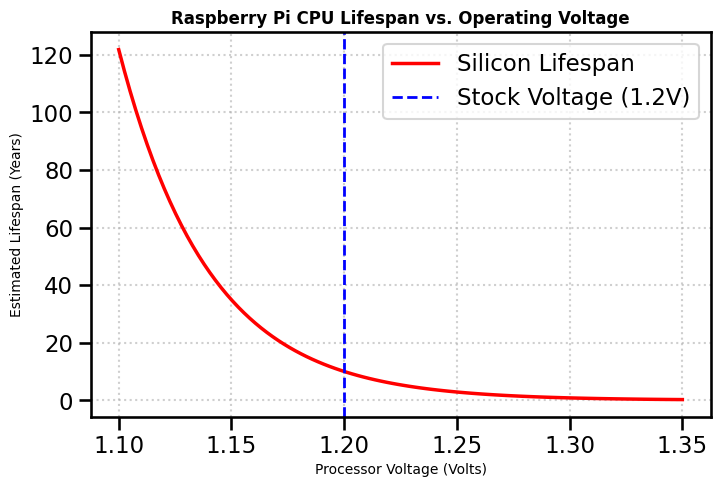

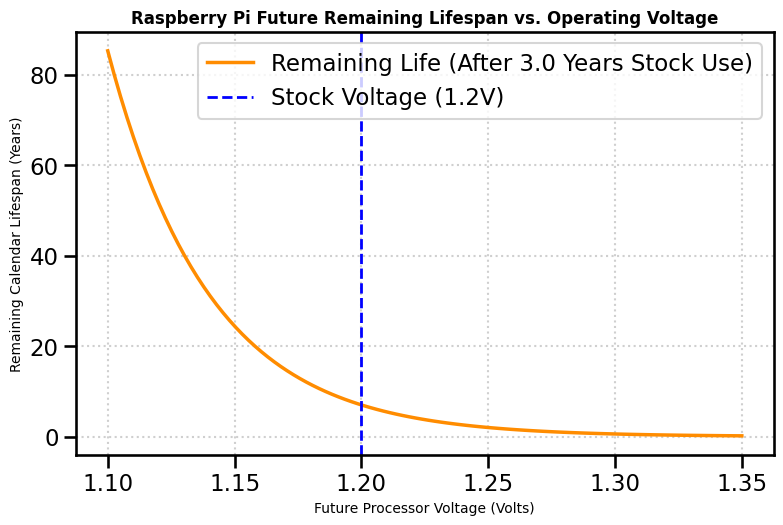

--- SILICON LIFE LOG ---
Phase 1: Ran 1.5 calendar years @ 1.20V. VAF:  1.00x. Added  1.50 wear-years.
Phase 2: Ran 0.5 calendar years @ 1.32V. VAF: 20.09x. Added 10.04 wear-years.
Phase 3: Ran 1.0 calendar years @ 1.15V. VAF:  0.29x. Added  0.29 wear-years.

--- CURRENT DEVICE STATUS ---
Total Calendar Age of Device: 3.0 years
Silicon Odometer (Total Wear): 11.83 out of 10.0 factory years
CRITICAL: The device has already exceeded its theoretical baseline life!


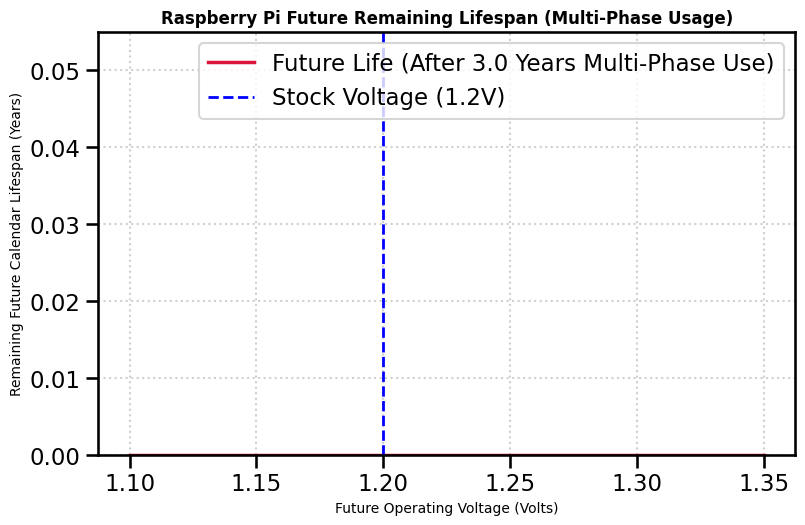

--- SILICON LIFE LOG ---
Phase 1: Ran 2.0 calendar years @ 1.20V. VAF:  1.00x. Added  2.00 wear-years.
Phase 2: Ran 0.1 calendar years @ 1.30V. VAF: 12.18x. Added  1.22 wear-years.
Phase 3: Ran 3.5 calendar years @ 1.15V. VAF:  0.29x. Added  1.00 wear-years.

--- CURRENT DEVICE STATUS ---
Total Calendar Age of Device: 5.6 years
Silicon Odometer (Total Wear): 4.22 out of 10.0 factory years
Remaining Health Budget:     5.78 standard years (57.8%)


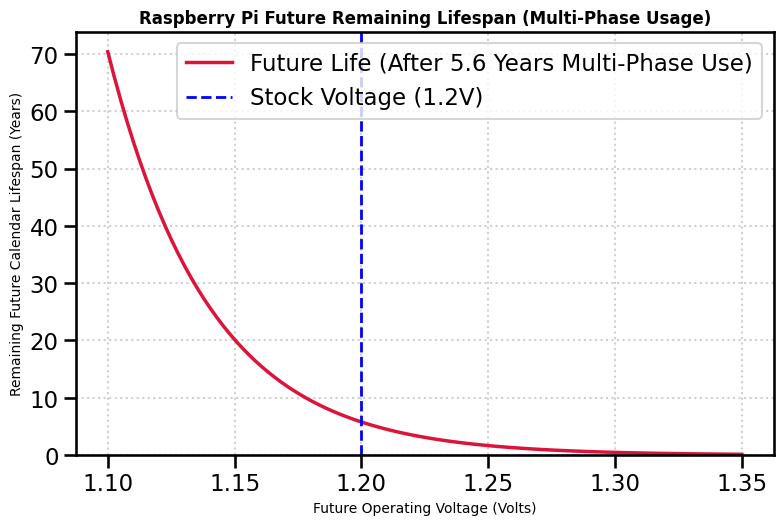

In [977]:
#silly sustainbility/aging cluster angle

import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the basic rules of our chip
V_use = 1.2 # Normal factory voltage
gamma = 25 # Silicon aging multiplier constant
baseline_years = 10.0 # Factory target lifespan

# 2. Create a smooth line of voltage points from 1.1V to 1.35V
voltages = np.linspace(1.1, 1.35, 100)

# 3. Calculate the Acceleration Factor and resulting lifespan
vaf = np.exp(gamma * (voltages - V_use))
lifespan = baseline_years / vaf

# 4. Draw the graph
plt.figure(figsize=(8, 5))
plt.plot(voltages, lifespan, color='red', linewidth=2.5, label='Silicon Lifespan')
plt.axvline(x=1.2, color='blue', linestyle='--', label='Stock Voltage (1.2V)')

# 5. Make the graph easy to read
plt.title('Raspberry Pi CPU Lifespan vs. Operating Voltage', fontsize=12, fontweight='bold')
plt.xlabel('Processor Voltage (Volts)', fontsize=10)
plt.ylabel('Estimated Lifespan (Years)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# 6. Show the final chart on your screen
plt.show()




import numpy as np
import matplotlib.pyplot as plt

# 1. Device Parameters
V_use = 1.2               # Stock factory voltage
gamma = 25                # Aging multiplier constant
baseline_lifespan = 10.0  # Total factory expected life (Years)

# 2. Historical Usage Input
years_already_used = 3.0  # CHANGE THIS: How many years the Pi has run at stock voltage

# Calculate remaining baseline life at stock voltage
remaining_baseline_life = baseline_lifespan - years_already_used

# 3. Generate Voltage Sweep (1.10V to 1.35V)
voltages = np.linspace(1.1, 1.35, 100)

# 4. Calculate VAF and Future Remaining Calendar Lifespan
# Remaining Lifespan = (Total Baseline Life - Past Standard Wear) / VAF
vaf = np.exp(gamma * (voltages - V_use))
remaining_lifespan = remaining_baseline_life / vaf

# Force remaining life to 0 if the math pushes it negative (device already dead)
remaining_lifespan = np.clip(remaining_lifespan, 0, None)

# 5. Plotting the Remaining Lifespan Curve
plt.figure(figsize=(9, 5.5))
plt.plot(voltages, remaining_lifespan, color='darkorange', linewidth=2.5, 
         label=f'Remaining Life (After {years_already_used} Years Stock Use)')
plt.axvline(x=1.2, color='blue', linestyle='--', label='Stock Voltage (1.2V)')

# 6. Formatting the Chart
plt.title('Raspberry Pi Future Remaining Lifespan vs. Operating Voltage', fontsize=12, fontweight='bold')
plt.xlabel('Future Processor Voltage (Volts)', fontsize=10)
plt.ylabel('Remaining Calendar Lifespan (Years)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Display the chart
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# 1. Device Core Parameters
V_use = 1.2               # Stock factory voltage (Volts)
gamma = 25                # Aging multiplier constant
baseline_lifespan = 10.0  # Factory expected life from day 0 (Years)

# 2. Historical Usage Phases (Timeline Input)
# Format: (Actual Years Run, Voltage Applied During Phase)
usage_history = [
    (1.5, 1.20),   # Phase 1: 1.5 years at stock voltage
    (0.5, 1.32),   # Phase 2: 0.5 years heavily overclocked
    (1.0, 1.15)    # Phase 3: 1.0 year heavily under-volted
]

# 3. Calculate Cumulative Damage (Odometer Reading)
total_equivalent_wear = 0.0
total_actual_years = 0.0

print("--- SILICON LIFE LOG ---")
for i, (years, voltage) in enumerate(usage_history, 1):
    # Calculate Voltage Acceleration Factor for this phase
    phase_vaf = np.exp(gamma * (voltage - V_use))
    # Calculate equivalent "wear hours" accumulated
    equivalent_wear = years * phase_vaf
    
    total_actual_years += years
    total_equivalent_wear += equivalent_wear
    
    print(f"Phase {i}: Ran {years:3.1f} calendar years @ {voltage:.2f}V. "
          f"VAF: {phase_vaf:5.2f}x. Added {equivalent_wear:5.2f} wear-years.")

# 4. Calculate Device Health Status Today
remaining_baseline_budget = baseline_lifespan - total_equivalent_wear

print("\n--- CURRENT DEVICE STATUS ---")
print(f"Total Calendar Age of Device: {total_actual_years:.1f} years")
print(f"Silicon Odometer (Total Wear): {total_equivalent_wear:.2f} out of {baseline_lifespan:.1f} factory years")

if remaining_baseline_budget <= 0:
    print("CRITICAL: The device has already exceeded its theoretical baseline life!")
    remaining_baseline_budget = 0.0
else:
    health_percentage = (remaining_baseline_budget / baseline_lifespan) * 100
    print(f"Remaining Health Budget:     {remaining_baseline_budget:.2f} standard years ({health_percentage:.1f}%)")

# 5. Predict Future Remaining Lifespan Sweep
voltages = np.linspace(1.1, 1.35, 100)
future_vaf = np.exp(gamma * (voltages - V_use))
future_remaining_lifespan = remaining_baseline_budget / future_vaf

# 6. Plotting the Multi-Phase Result
plt.figure(figsize=(9, 5.5))
plt.plot(voltages, future_remaining_lifespan, color='crimson', linewidth=2.5, 
         label=f'Future Life (After {total_actual_years:.1f} Years Multi-Phase Use)')
plt.axvline(x=1.2, color='blue', linestyle='--', label='Stock Voltage (1.2V)')

plt.title('Raspberry Pi Future Remaining Lifespan (Multi-Phase Usage)', fontsize=12, fontweight='bold')
plt.xlabel('Future Operating Voltage (Volts)', fontsize=10)
plt.ylabel('Remaining Future Calendar Lifespan (Years)', fontsize=10)
plt.ylim(bottom=0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()


import numpy as np
import matplotlib.pyplot as plt

# 1. Device Core Parameters
V_use = 1.2               # Stock factory voltage (Volts)
gamma = 25                # Aging multiplier constant
baseline_lifespan = 10.0  # Factory expected life from day 0 (Years)

# 2. FIXED Historical Usage Phases (Timeline Input)
# Total wear here equals ~4.25 years, leaving plenty of baseline life left!
usage_history = [
    (2.0, 1.20),   # Phase 1: 2.0 years at stock voltage (2.0 years wear)
    (0.1, 1.30),   # Phase 2: Only 0.1 years (approx 1 month) overclocked (1.2 years wear)
    (3.5, 1.15)    # Phase 3: 3.5 years heavily under-volted (~1.05 years wear)
]

# 3. Calculate Cumulative Damage (Odometer Reading)
total_equivalent_wear = 0.0
total_actual_years = 0.0

print("--- SILICON LIFE LOG ---")
for i, (years, voltage) in enumerate(usage_history, 1):
    phase_vaf = np.exp(gamma * (voltage - V_use))
    equivalent_wear = years * phase_vaf
    
    total_actual_years += years
    total_equivalent_wear += equivalent_wear
    
    print(f"Phase {i}: Ran {years:3.1f} calendar years @ {voltage:.2f}V. "
          f"VAF: {phase_vaf:5.2f}x. Added {equivalent_wear:5.2f} wear-years.")

# 4. Calculate Device Health Status Today
remaining_baseline_budget = baseline_lifespan - total_equivalent_wear

print("\n--- CURRENT DEVICE STATUS ---")
print(f"Total Calendar Age of Device: {total_actual_years:.1f} years")
print(f"Silicon Odometer (Total Wear): {total_equivalent_wear:.2f} out of {baseline_lifespan:.1f} factory years")

if remaining_baseline_budget <= 0:
    print("\n⚠️ WARNING: Remaining budget is negative. The plot will be FLAT AT ZERO.")
    remaining_baseline_budget = 0.0
else:
    health_percentage = (remaining_baseline_budget / baseline_lifespan) * 100
    print(f"Remaining Health Budget:     {remaining_baseline_budget:.2f} standard years ({health_percentage:.1f}%)")

# 5. Predict Future Remaining Lifespan Sweep
voltages = np.linspace(1.1, 1.35, 100)
future_vaf = np.exp(gamma * (voltages - V_use))
future_remaining_lifespan = remaining_baseline_budget / future_vaf

# 6. Plotting the Multi-Phase Result
plt.figure(figsize=(9, 5.5))
plt.plot(voltages, future_remaining_lifespan, color='crimson', linewidth=2.5, 
         label=f'Future Life (After {total_actual_years:.1f} Years Multi-Phase Use)')
plt.axvline(x=1.2, color='blue', linestyle='--', label='Stock Voltage (1.2V)')

plt.title('Raspberry Pi Future Remaining Lifespan (Multi-Phase Usage)', fontsize=12, fontweight='bold')
plt.xlabel('Future Operating Voltage (Volts)', fontsize=10)
plt.ylabel('Remaining Future Calendar Lifespan (Years)', fontsize=10)
plt.ylim(bottom=0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()



--- Corrected Wear Analysis (Analog Devices UG-311) ---
Formula Used:        VAF = exp[ 6.0 * (V_overclock - V_stock) ]
Overclock Voltage:   1.250V (over_voltage=2)
True Accel Factor:   Silicon degrades 1.35x faster under overclock.
-------------------------------------------------------
Total Silicon Wear Accumulated: 4.02 Wear-Years
True Calendar Time Remaining:   5.17 Years (if overclocked)


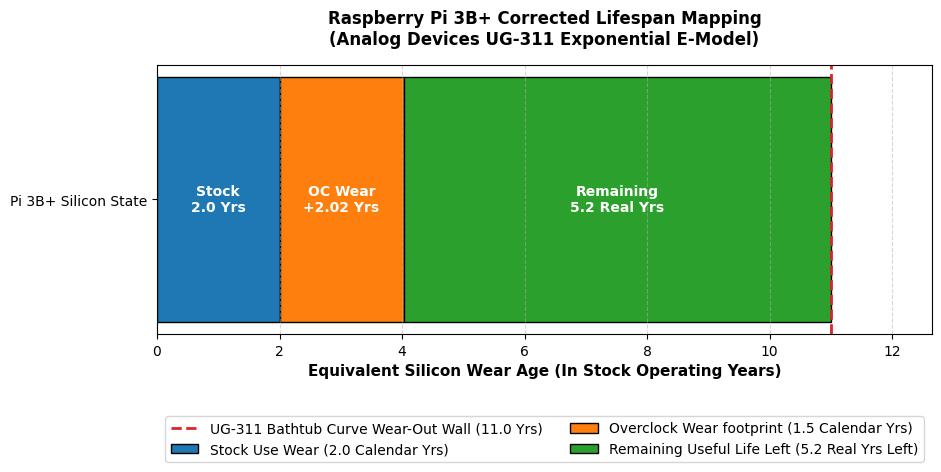

In [752]:
#maybe correct one?
import numpy as np
import matplotlib.pyplot as plt

def plot_ug311_bathtub_limit(
    years_stock_used=2.0,       # Calendar years run at stock 1.20V
    years_overclocked_used=1.5, # Calendar years run overvolted
    over_voltage_setting=2,    # config.txt over_voltage (+0.025V per step)
    design_life_wall_years=11.0,# Bathtub curve useful life limit (28nm node)
    gamma=6.0                   # VAF constant (γ) per semiconductor standards
):
    """
    Calculates remaining life using the exact Exponential Voltage Acceleration 
    formula sourced from Analog Devices Reliability Handbook (UG-311, Eq. 2).
    """
    v_stock = 1.25
    # 1. Calculate the exact target overclock core voltage 
    v_overclock = v_stock + (over_voltage_setting * 0.025)
    
    # 2. Apply UG-311 Formula: VAF = exp[ gamma * (V_test - V_use) ]
    vaf_overclock = np.exp(gamma * (v_overclock - v_stock))
    
    # 3. Translate real timeline into accumulated "Wear Footprint Years"
    wear_from_stock = years_stock_used * 1.0
    wear_from_overclock = years_overclocked_used * vaf_overclock
    total_wear_accumulated = wear_from_stock + wear_from_overclock
    
    # 4. Map against the physical bathtub wall boundary
    remaining_stock_wear_years = design_life_wall_years - total_wear_accumulated
    
    # If the user keeps the overclock active going forward, calculate remaining calendar time
    remaining_calendar_years_overclocked = max(0.0, remaining_stock_wear_years / vaf_overclock)
    
    # Print accurate math breakdown to console
    print(f"--- Corrected Wear Analysis (Analog Devices UG-311) ---")
    print(f"Formula Used:        VAF = exp[ {gamma} * (V_overclock - V_stock) ]")
    print(f"Overclock Voltage:   {v_overclock:.3f}V (over_voltage={over_voltage_setting})")
    print(f"True Accel Factor:   Silicon degrades {vaf_overclock:.2f}x faster under overclock.")
    print(f"-------------------------------------------------------")
    print(f"Total Silicon Wear Accumulated: {total_wear_accumulated:.2f} Wear-Years")
    print(f"True Calendar Time Remaining:   {remaining_calendar_years_overclocked:.2f} Years (if overclocked)")

    # 5. Visual Chart Generation
    fig, ax = plt.subplots(figsize=(10, 3.5))
    
    ax.barh('Pi 3B+ Silicon State', wear_from_stock, color='#1f77b4', edgecolor='black', 
            label=f'Stock Use Wear ({years_stock_used:.1f} Calendar Yrs)')
    ax.barh('Pi 3B+ Silicon State', wear_from_overclock, left=wear_from_stock, color='#ff7f0e', edgecolor='black', 
            label=f'Overclock Wear footprint ({years_overclocked_used:.1f} Calendar Yrs)')
    
    if remaining_stock_wear_years > 0:
        ax.barh('Pi 3B+ Silicon State', remaining_stock_wear_years, left=total_wear_accumulated, color='#2ca02c', edgecolor='black', 
                label=f'Remaining Useful Life Left ({remaining_calendar_years_overclocked:.1f} Real Yrs Left)')
        
    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=2, 
               label=f'UG-311 Bathtub Curve Wear-Out Wall ({design_life_wall_years:.1f} Yrs)')
    
    ax.set_xlabel('Equivalent Silicon Wear Age (In Stock Operating Years)', fontsize=11, fontweight='bold')
    ax.set_title('Raspberry Pi 3B+ Corrected Lifespan Mapping\n(Analog Devices UG-311 Exponential E-Model)', fontsize=12, pad=15, fontweight='bold')
    ax.set_xlim(0, design_life_wall_years * 1.15)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2, frameon=True)
    
    # Text overlays
    ax.text(wear_from_stock / 2, 0, f"Stock\n{years_stock_used:.1f} Yrs", ha='center', va='center', color='white', fontweight='bold')
    ax.text(wear_from_stock + (wear_from_overclock / 2), 0, f"OC Wear\n+{wear_from_overclock:.2f} Yrs", ha='center', va='center', color='white', fontweight='bold')
    if remaining_stock_wear_years > 0:
        ax.text(total_wear_accumulated + (remaining_stock_wear_years / 2), 0, f"Remaining\n{remaining_calendar_years_overclocked:.1f} Real Yrs", ha='center', va='center', color='white', fontweight='bold')
        
    # plt.tight_layout()
    plt.show()

# Run the correct formula simulation
plot_ug311_bathtub_limit()


--- Customized vcgencmd Lifespan Profiling ---
Base Stock Voltage:     1.310V
Overclock Target:       1.360V
Calculated Wear Rate:   Degrading 1.35x faster than your base baseline.
-----------------------------------------------
Calendar Years Left:    6.15 Years


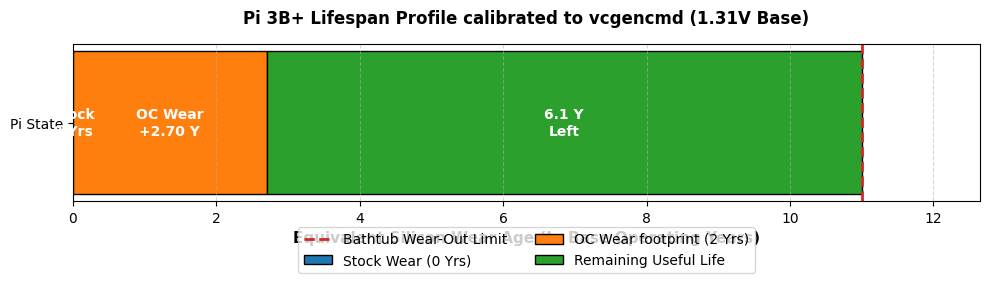

In [757]:
#might be final correct now?
import numpy as np
import matplotlib.pyplot as plt

def plot_custom_vcgencmd_limit(
    v_stock_read=1.306,         # Input what vcgencmd says WITHOUT overclocking
    over_voltage_setting=2,     # Your config.txt setting (+0.025V per step)
    years_stock_used=2.0,       # Past years run at standard stock setup
    years_overclocked_used=1.5, # Past years run with the overclock active
    design_life_wall_years=11.0,# Fixed Bathtub curve end-of-life wall for 28nm
    gamma=6.0                   # Sourced from Analog Devices UG-311
):
    """
    Maps remaining life against the 11-year bathtub curve limit using the
    exact core voltages returned by your device's vcgencmd interface.
    """
    # 1. Calculate actual overvolted setting based on your live stock baseline
    v_overclock_calc = v_stock_read + (over_voltage_setting * 0.025)
    
    # 2. Compute true UG-311 exponential acceleration factor
    vaf_overclock = np.exp(gamma * (v_overclock_calc - v_stock_read))
    
    # 3. Scale calendar hours into integrated degradation footprints
    wear_from_stock = years_stock_used * 1.0
    wear_from_overclock = years_overclocked_used * vaf_overclock
    total_wear_accumulated = wear_from_stock + wear_from_overclock
    
    # 4. Extract true remaining timeline values
    remaining_stock_wear_years = design_life_wall_years - total_wear_accumulated
    remaining_calendar_years_overclocked = max(0.0, remaining_stock_wear_years / vaf_overclock)
    
    # Text output confirmation
    print(f"--- Customized vcgencmd Lifespan Profiling ---")
    print(f"Base Stock Voltage:     {v_stock_read:.3f}V")
    print(f"Overclock Target:       {v_overclock_calc:.3f}V")
    print(f"Calculated Wear Rate:   Degrading {vaf_overclock:.2f}x faster than your base baseline.")
    print(f"-----------------------------------------------")
    print(f"Calendar Years Left:    {remaining_calendar_years_overclocked:.2f} Years")

    # 5. Graph rendering
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.barh('Pi State', wear_from_stock, color='#1f77b4', edgecolor='black', label=f'Stock Wear ({years_stock_used} Yrs)')
    ax.barh('Pi State', wear_from_overclock, left=wear_from_stock, color='#ff7f0e', edgecolor='black', label=f'OC Wear footprint ({years_overclocked_used} Yrs)')
    
    if remaining_stock_wear_years > 0:
        ax.barh('Pi State', remaining_stock_wear_years, left=total_wear_accumulated, color='#2ca02c', edgecolor='black', label='Remaining Useful Life')
        
    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=2, label='Bathtub Wear-Out Limit')
    
    ax.set_xlabel('Equivalent Silicon Wear Age (In Base Operating Years)', fontsize=11, fontweight='bold')
    ax.set_title(f'Pi 3B+ Lifespan Profile calibrated to vcgencmd ({v_stock_read}V Base)', fontsize=12, pad=15, fontweight='bold')
    ax.set_xlim(0, design_life_wall_years * 1.15)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2)
    
    ax.text(wear_from_stock / 2, 0, f"Stock\n{years_stock_used} Yrs", ha='center', va='center', color='white', fontweight='bold')
    ax.text(wear_from_stock + (wear_from_overclock / 2), 0, f"OC Wear\n+{wear_from_overclock:.2f} Y", ha='center', va='center', color='white', fontweight='bold')
    if remaining_stock_wear_years > 0:
        ax.text(total_wear_accumulated + (remaining_stock_wear_years / 2), 0, f"{remaining_calendar_years_overclocked:.1f} Y\nLeft", ha='center', va='center', color='white', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# Run the updated profile with your real world readings
plot_custom_vcgencmd_limit(v_stock_read=1.31, years_overclocked_used=2, years_stock_used=0)


--- Duty-Cycle Lifespan Analysis ---
Stock Baseline:     1.310V  | Overclock Target: 1.460V
Degradation Rate:   2.46x faster under overclock.
Usage per Day:      12.0 hours/day
Duty Cycle:         0.500
Stock-Equivalent Used: 2.84 years
True Time Left:     6.63 years remaining
Achieved Lifetime:  10.13 calendar years


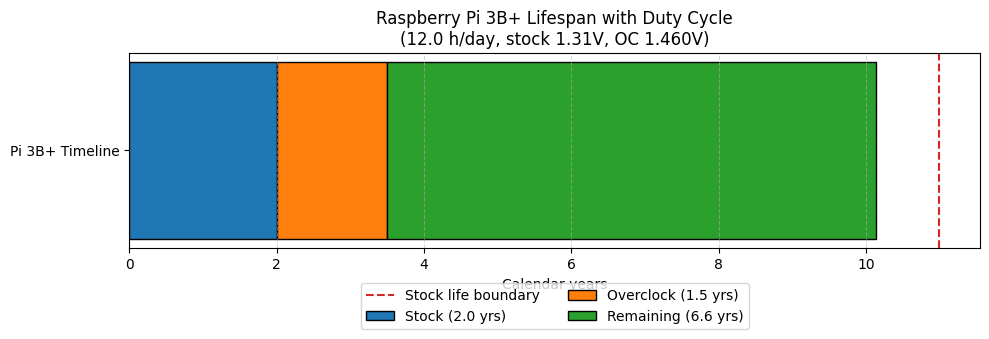

In [773]:
import numpy as np
import matplotlib.pyplot as plt


def plot_true_calendar_lifespan(
    years_stock_used=2.0,
    years_overclocked_used=1.5,
    usage_hours_per_day=24.0,
    over_voltage_setting=2,
    v_stock_read=1.31,
    design_life_wall_years=11.0,
    gamma=6.0
):
    v_overclock = v_stock_read + (over_voltage_setting * 0.025)
    vaf = np.exp(gamma * (v_overclock - v_stock_read))

    duty_cycle = np.clip(usage_hours_per_day / 24.0, 0.0, 1.0)

    stock_equiv_used = (
        years_stock_used * duty_cycle +
        years_overclocked_used * duty_cycle * vaf
    )

    remaining_stock_equiv = max(0.0, design_life_wall_years - stock_equiv_used)

    if years_overclocked_used > 0 and duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / (duty_cycle * vaf)
    elif duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / duty_cycle
    else:
        remaining_calendar_years_left = float('inf')

    achieved_calendar_lifespan = years_stock_used + years_overclocked_used + remaining_calendar_years_left
    end_of_life_reached = remaining_stock_equiv <= 0

    print("--- Duty-Cycle Lifespan Analysis ---")
    print(f"Stock Baseline:     {v_stock_read:.3f}V  | Overclock Target: {v_overclock:.3f}V")
    print(f"Degradation Rate:   {vaf:.2f}x faster under overclock.")
    print(f"Usage per Day:      {usage_hours_per_day:.1f} hours/day")
    print(f"Duty Cycle:         {duty_cycle:.3f}")
    print(f"Stock-Equivalent Used: {stock_equiv_used:.2f} years")

    if end_of_life_reached:
        print("Status:             End-of-life reached before the requested usage period finished.")
        print("True Time Left:     0.00 years remaining")
    else:
        if np.isfinite(remaining_calendar_years_left):
            print(f"True Time Left:     {remaining_calendar_years_left:.2f} years remaining")
        else:
            print("True Time Left:     undefined while fully idle")

    print(f"Achieved Lifetime:  {achieved_calendar_lifespan:.2f} calendar years")

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.barh('Pi 3B+ Timeline', years_stock_used, color='#1f77b4', edgecolor='black',
            label=f'Stock ({years_stock_used:.1f} yrs)')

    ax.barh('Pi 3B+ Timeline', years_overclocked_used, left=years_stock_used,
            color='#ff7f0e', edgecolor='black',
            label=f'Overclock ({years_overclocked_used:.1f} yrs)')

    if np.isfinite(remaining_calendar_years_left) and remaining_calendar_years_left > 0:
        ax.barh('Pi 3B+ Timeline', remaining_calendar_years_left,
                left=years_stock_used + years_overclocked_used,
                color='#2ca02c', edgecolor='black',
                label=f'Remaining ({remaining_calendar_years_left:.1f} yrs)')

    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=1.5,
               label='Stock life boundary')

    ax.set_xlabel('Calendar years')
    ax.set_title(
        f'Raspberry Pi 3B+ Lifespan with Duty Cycle\n'
        f'({usage_hours_per_day:.1f} h/day, stock {v_stock_read}V, OC {v_overclock:.3f}V)'
    )
    ax.set_xlim(0, max(design_life_wall_years * 1.05, years_stock_used + years_overclocked_used + 1))
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2)

    plt.tight_layout()
    plt.show()
plot_true_calendar_lifespan(usage_hours_per_day=12, over_voltage_setting=6)

--- Duty-Cycle Lifespan Analysis ---
Stock Baseline:     1.310V  | Overclock Target: 1.460V
Degradation Rate:   2.46x faster under overclock.
Usage per Minute:   5.0 seconds/minute
Duty Cycle:         0.083
Stock-Equivalent Used: 2.22 years
True Time Left:     42.85 years remaining
Achieved Lifetime:  54.85 calendar years


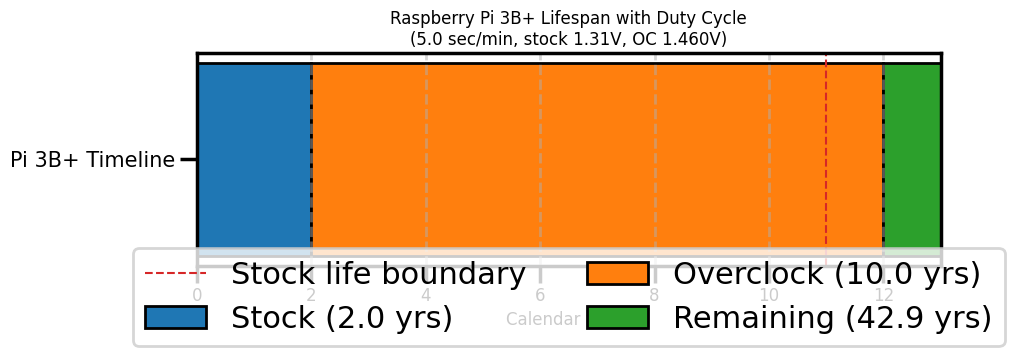

In [1235]:
import numpy as np
import matplotlib.pyplot as plt


def plot_true_calendar_lifespan(
    years_stock_used=2.0,
    years_overclocked_used=1.5,
    seconds_used_per_minute=60.0,
    over_voltage_setting=2,
    v_stock_read=1.31,
    design_life_wall_years=11.0,
    gamma=6.0
):
    v_overclock = v_stock_read + (over_voltage_setting * 0.025)
    vaf = np.exp(gamma * (v_overclock - v_stock_read))

    duty_cycle = np.clip(seconds_used_per_minute / 60.0, 0.0, 1.0)
    # duty_cycle_s_per_day = (seconds_used_per_minute/60)
    # duty_cycle_s_per_year = duty_cycle_s_per_day*
    stock_equiv_used = (
        years_stock_used * duty_cycle +
        years_overclocked_used * duty_cycle * vaf
    )

    remaining_stock_equiv = max(0.0, design_life_wall_years - stock_equiv_used)

    if years_overclocked_used > 0 and duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / (duty_cycle * vaf)
    elif duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / duty_cycle
    else:
        remaining_calendar_years_left = float('inf')

    achieved_calendar_lifespan = years_stock_used + years_overclocked_used + remaining_calendar_years_left
    end_of_life_reached = remaining_stock_equiv <= 0

    print("--- Duty-Cycle Lifespan Analysis ---")
    print(f"Stock Baseline:     {v_stock_read:.3f}V  | Overclock Target: {v_overclock:.3f}V")
    print(f"Degradation Rate:   {vaf:.2f}x faster under overclock.")
    print(f"Usage per Minute:   {seconds_used_per_minute:.1f} seconds/minute")
    print(f"Duty Cycle:         {duty_cycle:.3f}")
    print(f"Stock-Equivalent Used: {stock_equiv_used:.2f} years")

    if end_of_life_reached:
        print("Status:             End-of-life reached before the requested usage period finished.")
        print("True Time Left:     0.00 years remaining")
    else:
        if np.isfinite(remaining_calendar_years_left):
            print(f"True Time Left:     {remaining_calendar_years_left:.2f} years remaining")
        else:
            print("True Time Left:     undefined while fully idle")

    print(f"Achieved Lifetime:  {achieved_calendar_lifespan:.2f} calendar years")

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.barh('Pi 3B+ Timeline', years_stock_used, color='#1f77b4', edgecolor='black',
            label=f'Stock ({years_stock_used:.1f} yrs)')

    ax.barh('Pi 3B+ Timeline', years_overclocked_used, left=years_stock_used,
            color='#ff7f0e', edgecolor='black',
            label=f'Overclock ({years_overclocked_used:.1f} yrs)')

    if np.isfinite(remaining_calendar_years_left) and remaining_calendar_years_left > 0:
        ax.barh('Pi 3B+ Timeline', remaining_calendar_years_left,
                left=years_stock_used + years_overclocked_used,
                color='#2ca02c', edgecolor='black',
                label=f'Remaining ({remaining_calendar_years_left:.1f} yrs)')

    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=1.5,
               label='Stock life boundary')

    ax.set_xlabel('Calendar years')
    ax.set_title(
        f'Raspberry Pi 3B+ Lifespan with Duty Cycle\n'
        f'({seconds_used_per_minute:.1f} sec/min, stock {v_stock_read}V, OC {v_overclock:.3f}V)'
    )
    ax.set_xlim(0, max(design_life_wall_years * 1.05, years_stock_used + years_overclocked_used + 1))
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2)

    plt.tight_layout()
    plt.show()


plot_true_calendar_lifespan(seconds_used_per_minute=5, over_voltage_setting=6, years_overclocked_used=10)

--- Duty-Cycle Lifespan Analysis ---
Stock Voltage:          1.310V
Overclock Voltage:      1.460V
Undervoltage Voltage:   1.200V
OC Degradation:         0.0000 vs 0.0000
UV Degradation:         0.5367 vs 0.8333
Overclock VAF:          1.82x faster.
Undervoltage VAF:       0.64x faster.
Usage per Minute:       5.0 seconds/minute
Duty Cycle:             0.083
Stock-Equivalent Used:  0.70 years
True Time Left:         123.56 years remaining
Achieved Lifetime:      135.56 calendar years


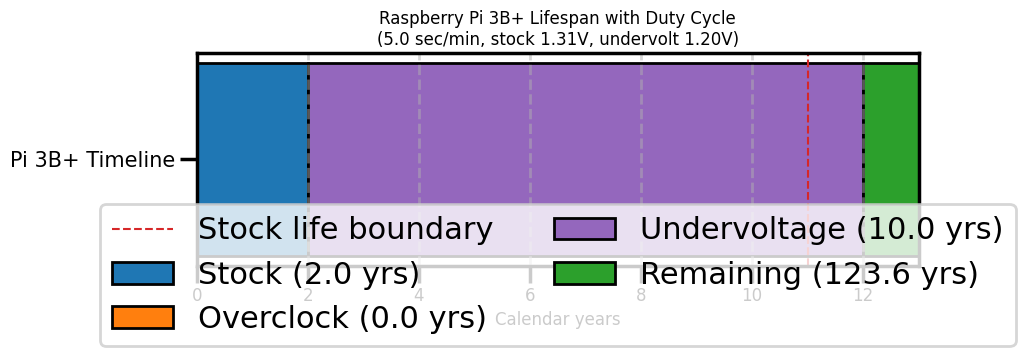

In [1304]:
import numpy as np
import matplotlib.pyplot as plt

def plot_true_calendar_lifespan(
    years_stock_used=2.0,
    years_overclocked_used=1.5,
    years_undervolted_used=0.5,
    seconds_used_per_minute=60.0,
    over_voltage_setting=2,
    stock_voltage=1.31,
    undervoltage_voltage=1.20,
    voltage_gamma=4.0,
    design_life_wall_years=11.0
):
    v_overclock = stock_voltage + (over_voltage_setting * 0.025)

    oc_ratio = v_overclock - max(stock_voltage, 1e-9)
    # uv_ratio = stock_voltage / max(undervoltage_voltage, 1e-9)
    uv_ratio =(undervoltage_voltage -  max(stock_voltage, 1e-9))

    # vaf_oc = np.exp(voltage_gamma * max(0.0, oc_ratio))
    vaf_oc = np.exp(voltage_gamma * oc_ratio)
    # vaf_uv = np.exp(voltage_gamma * max(0.0, uv_ratio))
    vaf_uv = np.exp(voltage_gamma * uv_ratio)

    duty_cycle = np.clip(seconds_used_per_minute / 60.0, 0.0, 1.0)

    stock_equiv_used = (
        years_stock_used * duty_cycle +
        years_overclocked_used * duty_cycle * vaf_oc +
        years_undervolted_used * duty_cycle * vaf_uv
    )

    remaining_stock_equiv = max(0.0, design_life_wall_years - stock_equiv_used)

    if duty_cycle > 0:
        remaining_calendar_years_left = remaining_stock_equiv / duty_cycle
    else:
        remaining_calendar_years_left = float('inf')

    achieved_calendar_lifespan = (
        years_stock_used +
        years_overclocked_used +
        years_undervolted_used +
        (0 if not np.isfinite(remaining_calendar_years_left) else remaining_calendar_years_left)
    )

    end_of_life_reached = remaining_stock_equiv <= 0

    print("--- Duty-Cycle Lifespan Analysis ---")
    print(f"Stock Voltage:          {stock_voltage:.3f}V")
    print(f"Overclock Voltage:      {v_overclock:.3f}V")
    print(f"Undervoltage Voltage:   {undervoltage_voltage:.3f}V")
    print(f"OC Degradation:         {years_overclocked_used * duty_cycle * vaf_oc:.4f} vs {years_overclocked_used * duty_cycle:.4f}")
    print(f"UV Degradation:         {years_undervolted_used * duty_cycle * vaf_uv:.4f} vs {years_undervolted_used * duty_cycle :.4f}")
    print(f"Overclock VAF:          {vaf_oc:.2f}x faster.")
    print(f"Undervoltage VAF:       {vaf_uv:.2f}x faster.")
    print(f"Usage per Minute:       {seconds_used_per_minute:.1f} seconds/minute")
    print(f"Duty Cycle:             {duty_cycle:.3f}")
    print(f"Stock-Equivalent Used:  {stock_equiv_used:.2f} years")

    if end_of_life_reached:
        print("Status:                 End-of-life reached before the requested usage period finished.")
        print("True Time Left:         0.00 years remaining")
    else:
        if np.isfinite(remaining_calendar_years_left):
            print(f"True Time Left:         {remaining_calendar_years_left:.2f} years remaining")
        else:
            print("True Time Left:         undefined while fully idle")

    print(f"Achieved Lifetime:      {achieved_calendar_lifespan:.2f} calendar years")

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.barh('Pi 3B+ Timeline', years_stock_used, color='#1f77b4', edgecolor='black',
            label=f'Stock ({years_stock_used:.1f} yrs)')
    ax.barh('Pi 3B+ Timeline', years_overclocked_used, left=years_stock_used,
            color='#ff7f0e', edgecolor='black',
            label=f'Overclock ({years_overclocked_used:.1f} yrs)')
    ax.barh('Pi 3B+ Timeline', years_undervolted_used,
            left=years_stock_used + years_overclocked_used,
            color='#9467bd', edgecolor='black',
            label=f'Undervoltage ({years_undervolted_used:.1f} yrs)')

    if np.isfinite(remaining_calendar_years_left) and remaining_calendar_years_left > 0:
        ax.barh('Pi 3B+ Timeline', remaining_calendar_years_left,
                left=years_stock_used + years_overclocked_used + years_undervolted_used,
                color='#2ca02c', edgecolor='black',
                label=f'Remaining ({remaining_calendar_years_left:.1f} yrs)')

    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=1.5,
               label='Stock life boundary')

    ax.set_xlabel('Calendar years')
    ax.set_title(
        f'Raspberry Pi 3B+ Lifespan with Duty Cycle\n'
        f'({seconds_used_per_minute:.1f} sec/min, stock {stock_voltage:.2f}V, undervolt {undervoltage_voltage:.2f}V)'
    )
    ax.set_xlim(0, max(design_life_wall_years * 1.05,
                       years_stock_used + years_overclocked_used + years_undervolted_used + 1))
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2)

    plt.tight_layout()
    plt.show()
plot_true_calendar_lifespan(seconds_used_per_minute=5, years_undervolted_used=10, over_voltage_setting=6, years_overclocked_used=0)


--- Lifespan Estimation Results ---
Total Predicted Useful Life: 154,321 standard hours (17.62 years)
Total Life Consumed So Far:  24,263 standard hours (2.77 years)
Estimated Remaining Life:    130,058 standard hours (14.85 years)


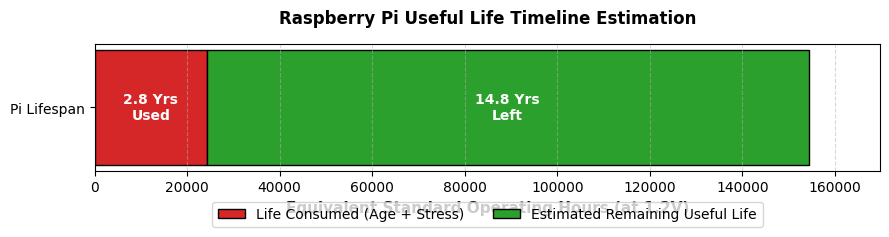

In [769]:
import numpy as np
import matplotlib.pyplot as plt

def plot_remaining_lifespan(
    v_use=1.2,                # Standard internal core voltage (Volts)
    v_stress=2.0,              # Lab testing voltage used to break test chips
    t_fail_stress=20000,       # How many hours test chips lasted at v_stress
    beta=4.0,                  # Material acceleration constant for silicon
    hours_normal_used=15000,   # Hours the Pi ran at standard v_use
    hours_overvolted_used=5000,# Hours the Pi ran at a higher custom voltage
    v_custom_overvolt=1.4      # The higher custom voltage used during life
):
    """
    Calculates and plots the remaining useful life of a semiconductor 
    based on historical voltage usage and accelerated life testing data.
    """
    # 1. Calculate Acceleration Factors (AF) using the Inverse Power Law
    af_lab_stress = (v_stress / v_use) ** beta
    af_user_overvolt = (v_custom_overvolt / v_use) ** beta
    
    # 2. Translate lab data to baseline maximum useful life hours
    max_useful_life_standard = t_fail_stress * af_lab_stress
    
    # 3. Calculate how much life has already been consumed (in standard hours)
    consumed_normal = hours_normal_used * 1.0
    consumed_overvolted = hours_overvolted_used * af_user_overvolt
    total_consumed_standard = consumed_normal + consumed_overvolted
    
    # 4. Calculate what is left
    remaining_life_standard = max_useful_life_standard - total_consumed_standard
    
    # Convert hours to years for more intuitive plotting text
    max_years = max_useful_life_standard / 8760
    consumed_years = total_consumed_standard / 8760
    remaining_years = max(0.0, remaining_life_standard / 8760)
    
    # Print numerical breakdown to console
    print(f"--- Lifespan Estimation Results ---")
    print(f"Total Predicted Useful Life: {max_useful_life_standard:,.0f} standard hours ({max_years:.2f} years)")
    print(f"Total Life Consumed So Far:  {total_consumed_standard:,.0f} standard hours ({consumed_years:.2f} years)")
    print(f"Estimated Remaining Life:    {max(0.0, remaining_life_standard):,.0f} standard hours ({remaining_years:.2f} years)")
    
    # 5. Generate the visualization plot
    plt.figure(figsize=(9, 3))
    
    # Draw horizontal stacked bar chart
    plt.barh('Pi Lifespan', total_consumed_standard, color='#d62728', edgecolor='black', label='Life Consumed (Age + Stress)')
    if remaining_life_standard > 0:
        plt.barh('Pi Lifespan', remaining_life_standard, left=total_consumed_standard, color='#2ca02c', edgecolor='black', label='Estimated Remaining Useful Life')
    else:
        print("⚠️ Warning: Calculations suggest the chip has exceeded its statistical useful life!")

    # Aesthetics and labels
    plt.xlabel('Equivalent Standard Operating Hours (at 1.2V)', fontsize=11, fontweight='bold')
    plt.title('Raspberry Pi Useful Life Timeline Estimation', fontsize=12, pad=15, fontweight='bold')
    plt.xlim(0, max_useful_life_standard * 1.1)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2, frameon=True)
    
    # Add data annotations inside the bars
    plt.text(total_consumed_standard / 2, 0, f"{consumed_years:.1f} Yrs\nUsed", ha='center', va='center', color='white', fontweight='bold')
    if remaining_life_standard > 0:
        plt.text(total_consumed_standard + (remaining_life_standard / 2), 0, f"{remaining_years:.1f} Yrs\nLeft", ha='center', va='center', color='white', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# Execute the function with sample user parameters
plot_remaining_lifespan()


--- Realistic Pi 3B+ Wear-Out Analysis ---
Stock Core Voltage:      1.20V
Overclock Core Voltage:  1.250V (over_voltage=2)
Acceleration Factor:     Silicon degrades 1.18x faster under overclock.
-------------------------------------------
Total Bathtub Useful Life Limit:   11.0 Equivalent Years
Total Equivalent Silicon Wear:     3.77 Years worn down
True Calendar Years Remaining:     6.14 Years (if kept overclocked)


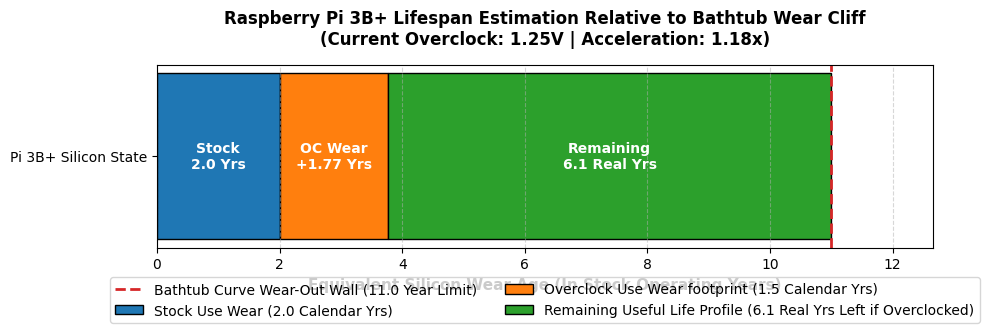

In [750]:
import numpy as np
import matplotlib.pyplot as plt

def plot_real_pi3bp_bathtub_limit(
    years_stock_used=2.0,       # Calendar years the Pi ran at standard stock settings
    years_overclocked_used=1.5, # Calendar years the Pi ran with the overclock active
    over_voltage_setting=2,    # config.txt 'over_voltage' setting (each step is 0.025V)
    design_life_wall_years=11.0,# The physical end of the useful life bathtub curve
    beta=4.0                    # Voltage acceleration exponent for 28nm semiconductor node
):
    """
    Calculates and plots remaining life by mapping accelerated wear against
    the semiconductor's finite physical bathtub curve wear-out wall.
    """
    v_stock = 1.20
    # 1. Calculate actual overvolted core voltage
    v_overclock = v_stock + (over_voltage_setting * 0.025)
    
    # 2. Calculate the Acceleration Factor (AF) using the Inverse Power Law
    # This measures the rate of degradation acceleration, NOT total life.
    af_overclock = (v_overclock / v_stock) ** beta
    
    # 3. Convert historical calendar usage into equivalent "Stock Wear Years"
    wear_from_stock = years_stock_used * 1.0
    wear_from_overclock = years_overclocked_used * af_overclock
    total_wear_accumulated = wear_from_stock + wear_from_overclock
    
    # 4. Calculate remaining life left before hitting the bathtub curve wall
    remaining_stock_wear_years = design_life_wall_years - total_wear_accumulated
    
    # If the user keeps the overclock active, time is consumed faster:
    remaining_calendar_years_overclocked = max(0.0, remaining_stock_wear_years / af_overclock)
    
    # Print a realistic breakdown to the console
    print(f"--- Realistic Pi 3B+ Wear-Out Analysis ---")
    print(f"Stock Core Voltage:      {v_stock:.2f}V")
    print(f"Overclock Core Voltage:  {v_overclock:.3f}V (over_voltage={over_voltage_setting})")
    print(f"Acceleration Factor:     Silicon degrades {af_overclock:.2f}x faster under overclock.")
    print(f"-------------------------------------------")
    print(f"Total Bathtub Useful Life Limit:   {design_life_wall_years:.1f} Equivalent Years")
    print(f"Total Equivalent Silicon Wear:     {total_wear_accumulated:.2f} Years worn down")
    print(f"True Calendar Years Remaining:     {remaining_calendar_years_overclocked:.2f} Years (if kept overclocked)")
    
    # 5. Generate the corrected visual chart
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot the stacked segments mapping out total accumulated wear
    ax.barh('Pi 3B+ Silicon State', wear_from_stock, color='#1f77b4', edgecolor='black', 
            label=f'Stock Use Wear ({years_stock_used:.1f} Calendar Yrs)')
    
    ax.barh('Pi 3B+ Silicon State', wear_from_overclock, left=wear_from_stock, color='#ff7f0e', edgecolor='black', 
            label=f'Overclock Use Wear footprint ({years_overclocked_used:.1f} Calendar Yrs)')
    
    if remaining_stock_wear_years > 0:
        ax.barh('Pi 3B+ Silicon State', remaining_stock_wear_years, left=total_wear_accumulated, color='#2ca02c', edgecolor='black', 
                label=f'Remaining Useful Life Profile ({remaining_calendar_years_overclocked:.1f} Real Yrs Left if Overclocked)')
    else:
        print("⚠️ Warning: Combined wear parameters exceed the targeted silicon design life wall!")

    # Draw the red vertical bathtub curve end-of-life boundary
    ax.axvline(x=design_life_wall_years, color='#d62728', linestyle='--', linewidth=2, 
               label=f'Bathtub Curve Wear-Out Wall ({design_life_wall_years:.1f} Year Limit)')
    
    # Visual Polish
    ax.set_xlabel('Equivalent Silicon Wear Age (In Stock Operating Years)', fontsize=11, fontweight='bold')
    ax.set_title(f'Raspberry Pi 3B+ Lifespan Estimation Relative to Bathtub Wear Cliff\n(Current Overclock: {v_overclock}V | Acceleration: {af_overclock:.2f}x)', 
                 fontsize=12, pad=15, fontweight='bold')
    ax.set_xlim(0, design_life_wall_years * 1.15)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=2, frameon=True)
    
    # Label Text Overlay inside the graph bars
    ax.text(wear_from_stock / 2, 0, f"Stock\n{years_stock_used:.1f} Yrs", ha='center', va='center', color='white', fontweight='bold')
    ax.text(wear_from_stock + (wear_from_overclock / 2), 0, f"OC Wear\n+{wear_from_overclock:.2f} Yrs", ha='center', va='center', color='white', fontweight='bold')
    if remaining_stock_wear_years > 0:
        ax.text(total_wear_accumulated + (remaining_stock_wear_years / 2), 0, f"Remaining\n{remaining_calendar_years_overclocked:.1f} Real Yrs", ha='center', va='center', color='white', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# Run with standard Pi 3B+ architecture limits
plot_real_pi3bp_bathtub_limit()


In [ ]:
# fig, f_axs = plt.subplots( 3 , len(range(1,5)), figsize=(25,10))
f_axs = []
for i in range(3):
    fig, axs = plt.subplots(len(range(1,5)), figsize=(25,40))
    f_axs.append(axs)
bws=[100, 50, 10]
c_map=["blue", "orange", "green", "red", "black", "pink"]
for bw_ind, bw in enumerate(bws):    
# for bw in [240]:    
    # f=open(f"exploration.dict.{bw}", "r")
    f=open(f"exploration.dict.{bw}.mean", "r")
    real_maps, pred_maps = f.readlines()
    real_maps = literal_eval(real_maps.strip())
    pred_maps = literal_eval(pred_maps.strip())
    t_flag="all"
    for inp_ind, inp in enumerate(real_maps):
        if inp_ind>1:
            break
        for m_ind, model in enumerate(real_maps[inp]):
            axs=f_axs[m_ind]
            # fig, axs = plt.subplots(len(real_maps[inp][model].keys()), figsize=(25,10))

            for w_ind, world in enumerate(real_maps[inp][model]):

                if t_flag=="c" or t_flag=="all":
                    x=sorted(list(real_maps[inp][model][world].keys()))
                    y = [real_maps[inp][model][world][bg][0][0] for bg in real_maps[inp][model][world]]
                    # y = [inp/i for i in y]
                    #bn_bs_c or nw
                    real_str = [f"{real_maps[inp][model][world][bg][0][1]}_{real_maps[inp][model][world][bg][0][2]}_{real_maps[inp][model][world][bg][0][3]}" for bg in  real_maps[inp][model][world]]
                    pred_y = [pred_maps[inp][model][world][bg][0][0] for bg in pred_maps[inp][model][world]]
                    # pred_y = [inp/p for p in pred_y]

                    pred_str = [f"{pred_maps[inp][model][world][bg][0][1]}_{pred_maps[inp][model][world][bg][0][2]}_{pred_maps[inp][model][world][bg][0][3]}" for bg in  real_maps[inp][model][world]]
                    
                    x = [ 100*round((i+world-1)/map_sub[subcluster],4) for i in x]
                    # axs[w_ind].plot(x,y, linestyle="--", marker=f"${world}$", markersize=20, alpha=0.2)
                    axs[w_ind].plot(x,y, linestyle="--", marker="x", markersize=20, color=c_map[bw_ind], label=f"compute_w_{bw}_{inp}")
                    axs[w_ind].set_xticks(x)
                    for i in range(len(x)):
                        axs[w_ind].text(x[i],y[i],real_str[i])
                    
                    # axs[w_ind].plot(x,pred_y, linestyle="--", marker=f"${world}$", markersize=20)
                    # for i in range(len(x)):
                    #     axs[w_ind].text(x[i],pred_y[i],pred_str[i])
                    print(f"rmse c {model}_{inp}_{world} { np.sqrt( np.mean([ (y[i]-pred_y[i])**2 for i in range(len(y)) ]) )}")
                    print(f"mae c {model}_{inp}_{world} { ( np.mean([ abs(y[i]-pred_y[i]) for i in range(len(y)) ]) )}")
                    print(f"mape c {model}_{inp}_{world} { 100*( np.mean([ abs(y[i]-pred_y[i])/y[i] for i in range(len(y)) ]) )}%")
                    print()

                if t_flag=="nw" or t_flag=="all":
                    x=sorted(list(real_maps[inp][model][world].keys()))
                    y = [real_maps[inp][model][world][bg][1][0] for bg in real_maps[inp][model][world]]
                    real_str = [f"{real_maps[inp][model][world][bg][1][1]}_{real_maps[inp][model][world][bg][1][2]}_{real_maps[inp][model][world][bg][1][3]}" for bg in  real_maps[inp][model][world]]
                    pred_y = [pred_maps[inp][model][world][bg][1][0] for bg in pred_maps[inp][model][world]]
                    pred_str = [f"{pred_maps[inp][model][world][bg][1][1]}_{pred_maps[inp][model][world][bg][1][2]}_{pred_maps[inp][model][world][bg][1][3]}" for bg in  real_maps[inp][model][world]]
                    
                    x = [ 100*round((i+world-1)/map_sub[subcluster],4) for i in x]

                    # axs[w_ind].plot(x,y, linestyle="--", marker=f"${world}$", markersize=20, alpha=0.2)
                    axs[w_ind].plot(x,y, linestyle="--", marker=".", markersize=20, color=c_map[bw_ind], label=f"nw_w_{bw}_{inp}")
                    # for i in range(len(x)):
                    #     axs[w_ind].text(x[i],y[i],real_str[i])
                    # axs[w_ind].plot(x,pred_y, linestyle="--", marker=f"${world}$", markersize=20)
                    # for i in range(len(x)):
                    #     axs[w_ind].text(x[i],pred_y[i],pred_str[i])
                    print(f"rmse nw {model}_{inp}_{world} { np.sqrt( np.mean([ (y[i]-pred_y[i])**2 for i in range(len(y)) ]) )}")
                    print(f"mae nw {model}_{inp}_{world} { ( np.mean([ abs(y[i]-pred_y[i]) for i in range(len(y)) ]) )}")
                    print(f"mape nw {model}_{inp}_{world} { 100*( np.mean([ abs(y[i]-pred_y[i])/y[i] for i in range(len(y)) ]) )}%")
                    print()
                
                axs[w_ind].set_title(f"{model}_{inp}_{bw}_{world}")    
                axs[w_ind].legend()
        #     break
        # break


In [1477]:
def flop_comp(model, world, bw, bg):
    f=open(f"/Users/animeshnd/model_splitting/scheduler/{model}_splits_{world}_nw/meta.json")
    model_nw = json.load(f)
    f=open(f"/Users/animeshnd/model_splitting/scheduler/{model}_splits_{world}_c/meta.json")
    model_c = json.load(f)
    c_flops = [r['actual_flops'] for r in model_c['splits']]
    nw_flops = [r['actual_flops'] for r in model_nw['splits']]
    real, std_val, pred, naive_pred = best_fit_reader("best_fit_max_2_5.csv", "bramble-2-4", model, world, bg, 1, 10, bw, ty='c', col_flag="max")
    print(f"comp flops: {c_flops}, {[round(100*i/sum(c_flops),2) for i in c_flops]}, comp nw:{[r['boundary_transfer_bytes'] for r in model_c['splits']]}, time:{real}, {pred} ")
    real, std_val, pred, naive_pred = best_fit_reader("best_fit_max_2_5.csv", "bramble-2-4", model, world, bg, 1, 10, bw, ty='nw', col_flag="max")
    print(f"nw flops: {nw_flops}, {[round(100*i/sum(nw_flops),2) for i in nw_flops]}, nw nw:{[r['boundary_transfer_bytes'] for r in model_nw['splits']]}, time:{real}, {pred} ")

flop_comp("eff", 3, 10, bg=0)
flop_comp("eff", 3, 10, bg=3)

[0.0, 0.16662214533333333] [0.0, 0.200704] 0.3673261453333333
[0.0, 0.18022947034433026, 0.19210351541373719] [0.0, 0.200704, 0.1404928] 0.39280751541373715
[0.0, 0.18784909282224727, 0.20022514092446453, 0.21676470199173245] [0.0, 0.200704, 0.1404928] 0.41746870199173247
[0.0, 0.18784909282224727, 0.20022514092446453, 0.21676470199173245] [0.0, 0.200704, 0.1404928] 0.41746870199173247
[0.0, 0.18784909282224727, 0.20022514092446453, 0.21676470199173245] [0.0, 0.200704, 0.1404928] 0.41746870199173247
[0.0, 0.18784909282224727, 0.20022514092446453, 0.21676470199173245] [0.0, 0.200704, 0.1404928] 0.41746870199173247
[0.0, 0.18784909282224727, 0.20022514092446453, 0.21676470199173245] [0.0, 0.200704, 0.1404928] 0.41746870199173247
[0.0, 0.18784909282224727, 0.20022514092446453, 0.21676470199173245] [0.0, 0.200704, 0.1404928] 0.41746870199173247
[0.0, 0.18784909282224727, 0.20022514092446453, 0.21676470199173245] [0.0, 0.200704, 0.1404928] 0.41746870199173247
[0.0, 0.18784909282224727, 0.20

In [ ]:
#third result -> rmse, mae, mape low when using the curve
#best trial and how close greedy is compared to only_compute or only_communicate
